In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import constraints
from torch.func import vmap

In [2]:
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, TraceEnum_ELBO, config_enumerate, infer_discrete, Predictive
from pyro.ops.indexing import Vindex
from pyro import poutine

In [3]:
import numpy as np
import math
from itertools import product, accumulate
import einops
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import umap  

In [4]:
def generate_distinct_components(K, V, peak_strength=5.0, base_concent=0.1):
    comps = []
    for k in range(K):
        alpha = torch.ones(V) * base_concent
        alpha[k * V // K] = peak_strength
        comp = torch.distributions.Dirichlet(alpha).sample()
        comps.append(comp)
    return torch.stack(comps)  # shape: (K, V)


In [5]:
def generate_distinct_distributions(N, V, concent=0.8):
    dists = []
    alpha = torch.ones(V) * concent  # sparse
    alpha = torch.clamp(alpha, min=1e-6)
    dist = torch.distributions.Dirichlet(alpha)
    samples = dist.sample((N,))
    return samples


In [6]:
def select_most_diverse(samples, num_select=3):
    """
    samples: (N, D) tensor of N samples with dimension D
    num_select: how many to select
    """
    N = samples.size(0)
    selected = [0]  # start with first sample arbitrarily

    # Compute full pairwise distance matrix (Euclidean)
    # dist[i,j] = ||samples[i] - samples[j]||_2
    diff = samples.unsqueeze(1) - samples.unsqueeze(0)  # (N, N, D)
    dist_matrix = torch.norm(diff, dim=2)  # (N, N)

    for _ in range(num_select - 1):
        # distances from all samples to selected set
        dist_to_selected = dist_matrix[selected, :]  # shape: (len(selected), N)
        min_dist_to_selected, _ = dist_to_selected.min(dim=0)  # min distance to any selected sample

        # Mask out already selected indices by setting distance to -1
        min_dist_to_selected[selected] = -1

        # Pick sample with max min distance
        next_idx = torch.argmax(min_dist_to_selected).item()
        selected.append(next_idx)

    return selected

In [7]:
def js_divergence(p, q, eps=1e-9):
    """
    p, q: [..., V] probability vectors (last dim sums to 1)
    returns: JS divergence (same batch shape as p[..., 0])
    """
    p = p.clamp_min(eps)
    q = q.clamp_min(eps)
    m = 0.5 * (p + q)
    kl_pm = (p * (p.log() - m.log())).sum(-1)
    kl_qm = (q * (q.log() - m.log())).sum(-1)
    return 0.5 * (kl_pm + kl_qm)

In [8]:
def generate_hierarchical_mixture_data(struct_upbd,
    N_per_base=20, M=200, V=100,  # N_per_base: number of samples per base category
    seed=42
):
    # Config
    num_super = struct_upbd["G1"]
    num_base_per_super = struct_upbd["G2"]
    num_features = struct_upbd["G0"]
    samples_per_base = N_per_base
    torch.manual_seed(seed)

    y_means = torch.linspace(-num_features/4, num_features/4, steps=num_features)
    y_stds = 0.1 + 0.1 * torch.rand(num_features)

    alpha_1 = 0.8
    assert (num_features >= num_base_per_super*num_super)
    super_window = int(num_features/ num_super)
    super_core = generate_distinct_distributions(num_super, super_window, alpha_1)

    row_idx = torch.arange(num_super*super_window).reshape(num_super, super_window)  # (m, k)
    super_prototypes = torch.zeros(num_super, num_features, dtype=super_core.dtype)
    blocks = int(num_features/super_window)
    for i in range(blocks):
        super_prototypes[:, i*super_window:(i+1)*super_window] = super_core * (i == torch.arange(num_super) % blocks).unsqueeze(1)
    super_prototypes = super_prototypes / super_prototypes.sum(dim=-1, keepdim=True)
    
    
    base_prototypes = []
    alpha_2 = [6, 8]
    for super_id in range(num_super):
        candids = generate_distinct_distributions(num_base_per_super*5, num_features, alpha_2[super_id]*super_prototypes[super_id])
        base_prototypes.append(candids[select_most_diverse(candids, num_base_per_super)])
        # base_prototypes.append(generate_distinct_distributions(num_base_per_super, num_features, alpha_2[super_id]*super_prototypes[super_id]))
    base_prototypes = torch.stack(base_prototypes)

    eta=1
    word_dists = generate_distinct_components(num_features, V, base_concent=eta)
    word_block = int(V / (num_super*num_base_per_super))
    overlap = int(word_block/2)
    for i in range(num_features):
        overlap_start = 0
        if (i < int(num_features / 2)):
            non_zero_idxs = torch.arange(i*overlap, i*overlap + word_block)
        else:
            non_zero_idxs = torch.arange(-(i*overlap + word_block)-1, -i*overlap -1)
        mask = torch.zeros(V, dtype=torch.bool)
        mask[non_zero_idxs] = True
        word_dists[i] = word_dists[i]*mask
    word_dists = word_dists / word_dists.sum(dim=-1, keepdim=True)
    X = []
    y = []
    labels_base = []
    labels_super = []
    
    for super_id in range(num_super):
        for base_offset in range(num_base_per_super):
            base_id = super_id*num_base_per_super + base_offset
            base_proto = base_prototypes[super_id][base_offset]
            
            for _ in range(samples_per_base):
                noise = torch.randn(num_features) * 0.1  # local noise around base proto
                doc_dist = base_proto
    
                doc = []
                for word_id in range(M):
                    comp_id = torch.distributions.Categorical(doc_dist).sample().item()
                    word = torch.distributions.Multinomial(1, word_dists[comp_id]).sample()
                    doc.append(word)
                doc = torch.stack(doc)
                
                X.append(doc)
                comp_id = torch.distributions.Categorical(doc_dist).sample().item()
                y.append(torch.normal(mean=y_means[comp_id], std=y_stds[comp_id], size=(1,)))
                labels_base.append(base_id)
                labels_super.append(super_id)
    
    X_data = torch.stack(X)
    y_data = torch.stack(y)
    labels_base = torch.tensor(labels_base)
    labels_super = torch.tensor(labels_super)    

    return {
        "x": X_data,                  # (total_data, M, V)
        "y": y_data,                  # (total_data,)
        "super_labels": labels_super,  # (total_data,)
        "base_labels": labels_base,    # (total_data,)
        "word_dists": word_dists,      # (num_components, V)
        "super_mix_weights": super_prototypes,
        "child_mix_weights": base_prototypes     # (num_super*num_base_per_super, 
        
    }


In [9]:
struct_upbd = {"G0": 6, "G1": 2, "G2": 3}
ground_truth = generate_hierarchical_mixture_data(struct_upbd)

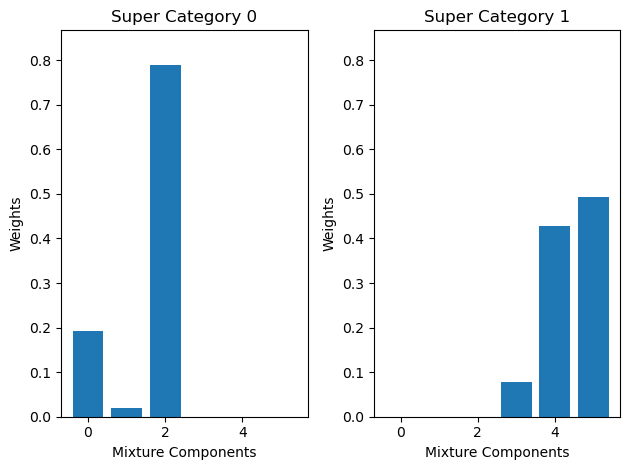

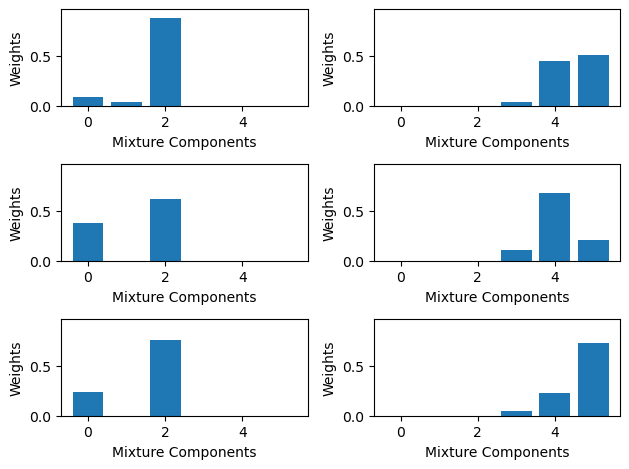

In [10]:
super_mix_weights = ground_truth["super_mix_weights"]
child_mix_weights = ground_truth["child_mix_weights"]
fig, axs = plt.subplots(1, struct_upbd["G1"])
for i in range(struct_upbd["G1"]):
    ax = axs[i]
    ax.bar(range(struct_upbd["G0"]), super_mix_weights[i].numpy())
    ax.set_title(f"Super Category {i}")
    ax.set_xlabel("Mixture Components")
    ax.set_ylabel("Weights")
    ax.set_ylim(0, super_mix_weights.max().item() * 1.1)

# fig.suptitle(f"Super Category Weights of {struct_upbd['G0']} Shared Mixture Components", fontsize=16)
fig.tight_layout()
plt.show()

# Bar plots for each component
fig, axs = plt.subplots(struct_upbd["G2"], struct_upbd["G1"])
for i in range(struct_upbd["G2"]):
    for j in range(struct_upbd["G1"]):
        ax = axs[i, j]
        ax.bar(range(struct_upbd["G0"]), child_mix_weights[j][i].numpy())
        # ax.set_title(f"Super Category {j} Child Category {i}")
        ax.set_xlabel("Mixture Components")
        ax.set_ylabel("Weights")
        ax.set_ylim(0, child_mix_weights.max().item() * 1.1)

# fig.suptitle(f"Child Category Weights of {struct_upbd['G1']} Shared Mixture Components", fontsize=16)
fig.tight_layout()
plt.show()

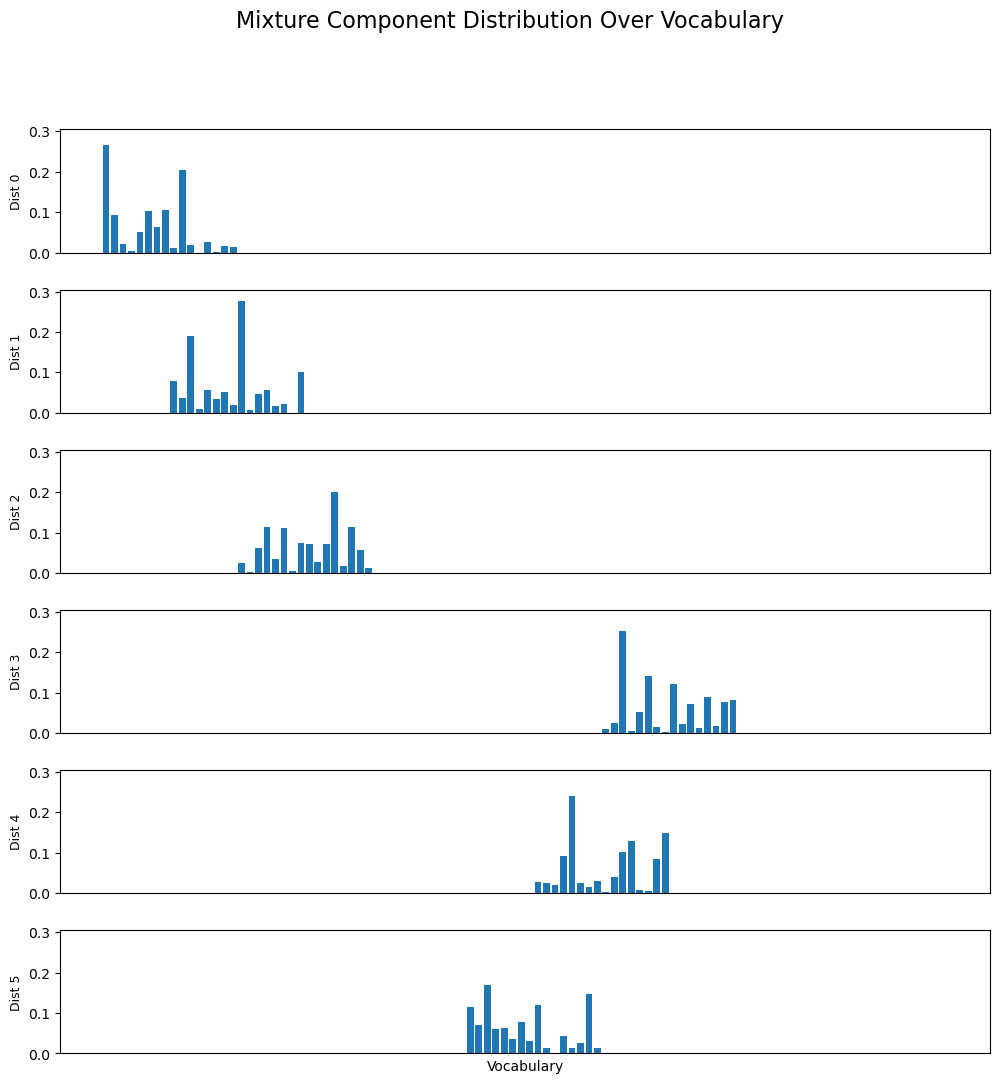

In [11]:
N = struct_upbd["G0"]
V = 100
gt_mix_comp = ground_truth["word_dists"]

fig, axs = plt.subplots(N, 1, figsize=(12, 2 * N), sharex=True)  # Share x-axis, increase height

for i in range(N):
    ax = axs[i]
    ax.bar(range(V), gt_mix_comp[i].numpy())
    ax.set_ylabel(f'Dist {i}', fontsize=9)
    ax.set_ylim(0, gt_mix_comp.max().item() * 1.1)

    # Hide x-axis labels except for the last one
    if i < N - 1:
        ax.set_xticks([])
    else:
        ax.set_xlabel("Vocabulary", fontsize=10)

# Tight layout with spacing between plots
fig.suptitle(f"Mixture Component Distribution Over Vocabulary", fontsize=16)
plt.subplots_adjust(hspace=0.3)
plt.show()

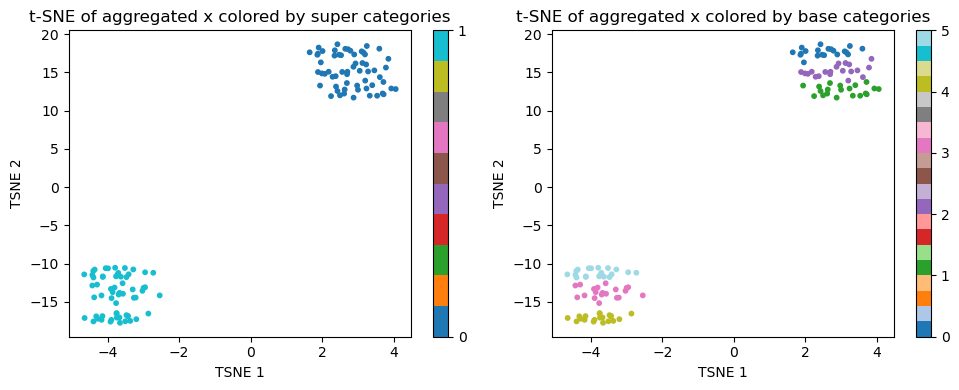

/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


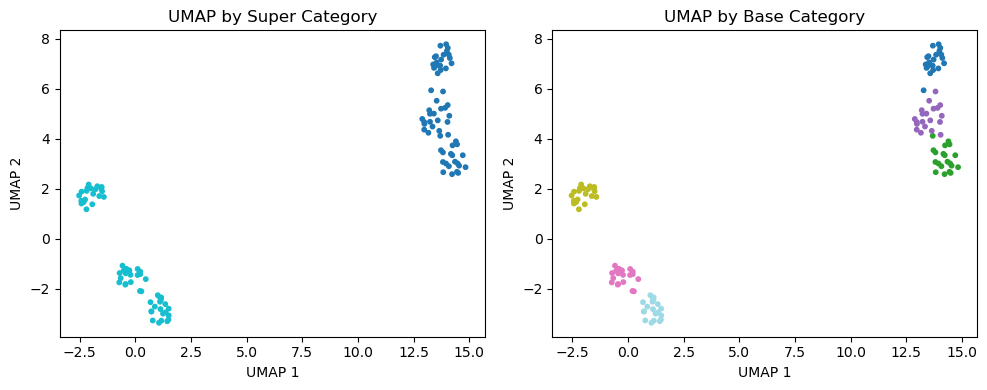

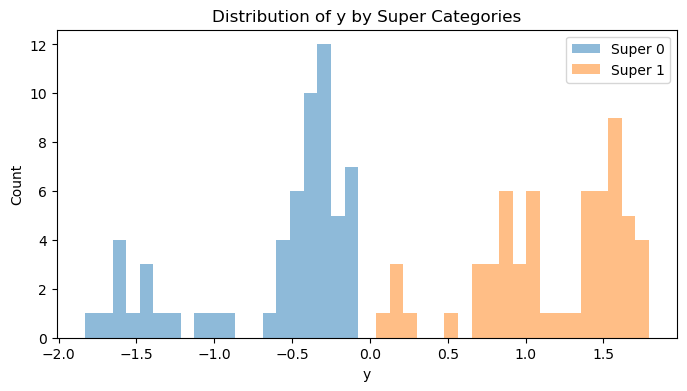

In [12]:
# Run t-SNE
x_agg = ground_truth["x"].sum(dim=1)
vocab_size = ground_truth["x"].shape[-1]
tsne = TSNE(n_components=2, random_state=0)
x_embedded = tsne.fit_transform(x_agg.numpy())

# Plot t-SNE colored by super categories
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=ground_truth["super_labels"], cmap="tab10", s=10)
plt.colorbar(scatter, ticks=range(6))
plt.title("t-SNE of aggregated x colored by super categories")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

# Plot t-SNE colored by base categories
plt.subplot(1, 2, 2)
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=ground_truth["base_labels"], cmap="tab20", s=10)
plt.colorbar(scatter, ticks=range(18))
plt.title("t-SNE of aggregated x colored by base categories")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

plt.tight_layout()
plt.show()

# === UMAP projection ===
reducer = umap.UMAP(random_state=0)
x_umap = reducer.fit_transform(x_agg.numpy().astype(np.float32))


# === UMAP Plots ===
plt.figure(figsize=(10, 4))

# Super category coloring
plt.subplot(1, 2, 1)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=ground_truth["super_labels"], cmap="tab10", s=10)
plt.title("UMAP by Super Category")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# Base category coloring
plt.subplot(1, 2, 2)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=ground_truth["base_labels"], cmap="tab20", s=10)
plt.title("UMAP by Base Category")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.tight_layout()
plt.show()

# Plot distribution of y by super categories
plt.figure(figsize=(8, 4))
for super_id in range(struct_upbd["G1"]):
    y_vals = ground_truth["y"][ground_truth["super_labels"] == super_id].numpy()
    plt.hist(y_vals, bins=20, alpha=0.5, label=f"Super {super_id}")

plt.title("Distribution of y by Super Categories")
plt.xlabel("y")
plt.ylabel("Count")
plt.legend()
plt.show()



In [13]:
def generalized_einsum(tensor_a, tensor_b):
    # Get shapes
    shape_a = tensor_a.shape  # e.g., (n, a1, a2, a3, a4, ...)
    shape_b = tensor_b.shape  # e.g., (..., k) = (a4, a3, a2, a1, k)
    
    # Extract n (first dimension of A)
    n = shape_a[0]
    
    # Extract additional dimensions from A (excluding n)
    dims_a = list(shape_a[1:])  # e.g., [a1, a2, a3, a4]
    
    # Extract dimensions from B (excluding k)
    dims_b = list(shape_b[:-1])  # e.g., [a4, a3, a2, a1]
    k = shape_b[-1]
    
    # Validate that B's dimensions (excluding k) are the reverse of A's (excluding n)
    if dims_a != dims_b[::-1]:
        raise ValueError(f"Dimensions {dims_a} and {dims_b} are not compatible (must be reverse order)")
    
    # Create dimension labels
    # Use unique letters for each dimension (e.g., i, j, k, l for a1, a2, a3, a4)
    dim_labels = [chr(105 + i) for i in range(len(dims_a))]  # e.g., ['i', 'j', 'k', 'l']
    
    # Pattern for A: n followed by additional dims
    pattern_a = f"a {' '.join(dim_labels)}"  # e.g., "n i j k l"
    
    # Pattern for B: reversed additional dims followed by k
    pattern_b = f"{' '.join(dim_labels[::-1])} z"  # e.g., "l k j i k"
    
    # Output pattern: n k
    pattern_out = "a z"
    
    # Full einsum pattern
    pattern = f"{pattern_a}, {pattern_b} -> {pattern_out}"  # e.g., "n i j k l, l k j i k -> n k"
    
    # Perform einsum
    return einops.einsum(tensor_a, tensor_b, pattern)

In [21]:
def mix_weights(beta):
    # Compute cumulative product of (1 - beta) along the last dimension
    beta1m_cumprod = (1 - beta).cumprod(dim=-1)
    # Pad beta with a 1 at the end of the last dimension
    beta_padded = F.pad(beta, (0, 1), value=1)
    # Pad beta1m_cumprod with a 1 at the start of the last dimension
    beta1m_cumprod_padded = F.pad(beta1m_cumprod, (1, 0), value=1)
    # Element-wise multiplication
    weight = beta_padded * beta1m_cumprod_padded
    rlt = torch.max(weight, torch.tensor(1e-6, device=beta.device))
    rlt = rlt/rlt.sum(dim=-1, keepdim=True)
    # return F.softmax(beta_padded * beta1m_cumprod_padded, dim=-1)
    return rlt
    

In [35]:
@config_enumerate
def model_with_ground_truth(data, struct_upbd, vocab_size, device):
    # # Initialize parameters
    param_dims = list(struct_upbd.values())
    param_dims.reverse()
    
    struct_params = {}
    # dimension: number of mixture
    cp = 1
    struct_params["alpha0"] = pyro.param("model_alpha0", torch.tensor(100, device=device) , constraint=constraints.positive).expand(param_dims[-1:])
    # dimension: number of mixture
    struct_params["alpha1"] = pyro.param("model_alpha1", cp*torch.rand(1, device=device) , constraint=constraints.positive).expand(param_dims[-1:])
    
    for i in range(2, len(struct_upbd)+1, 1):
        # dimension: level i category * level i-1 category * ... * level 1 category * number of mixture
        struct_params[f"alpha{i}"] = pyro.param(f"model_alpha{i}", cp*torch.rand(param_dims[-i:-1], device=device) , constraint=constraints.positive).unsqueeze(-1).expand(param_dims[-i:])
    # dimension: number of mixture * vocabulary size
    alpha_g = 1./vocab_size
    gen_params = gt_mix_comp
    # gen_params = pyro.param("model_phi_u", torch.distributions.Dirichlet(alpha_g*torch.ones(vocab_size, device=device)).sample((struct_upbd["G0"], )), constraint=constraints.simplex)
    # dimension: number of mixture * 1
    reg_params_mu = pyro.param("model_phi_y_mu", torch.distributions.Normal(loc = torch.tensor(0.0, device=device), scale = torch.tensor(1.0, device=device)).sample((struct_upbd["G0"], )))
    # dimension: number of mixture * 1
    reg_params_sigma = pyro.param("model_phi_y_sigma", torch.distributions.Uniform(torch.tensor(1e-3, device=device), torch.tensor(1.0, device=device)).sample((struct_upbd["G0"], )), constraint=constraints.positive)

    struct_weights = {}
    # dimension: number of mixture
    beta_0 = pyro.sample("G0", dist.Beta(torch.ones([struct_upbd["G0"]], device=device), struct_params["alpha0"]).to_event(1))
    # dimension: number of mixture
    struct_weights["G0"] = mix_weights(beta_0)[..., :-1]
    for level in range(1, len(struct_upbd), 1):
        struct_weights["G0"] = struct_weights["G0"].flatten()
        # dimension: level level category * level level-1 category * ... * level 1 category * number of mixture
        param_alpha = struct_params[f"alpha{level}"]*struct_weights[f"G{level-1}"]
        # print(struct_params[f"alpha{level}"].shape, struct_weights[f"G{level-1}"].shape)
        # print(f"level {level}, alpha shape {param_alpha.shape}")

        param_beta = struct_params[f"alpha{level}"]*(1 - struct_weights[f"G{level-1}"].cumsum(-1))
        # with pyro.plate(f"LoG{level}", struct_upbd[f"G{level}"]):
        # dimension: level level+1 category * level level category * level level-1 category * ... * level 1 category * number of mixture
        beta = pyro.sample(f"G{level}", dist.Beta(param_alpha.unsqueeze(0).expand(param_dims[-level-1:]), param_beta.unsqueeze(0).expand(param_dims[-level-1:])).to_event(level+1))
        # dimension: level level+1 category * level level category * level level-1 category * ... * level 1 category * number of mixture
        # print(f"next level {beta.shape}")
        struct_weights[f"G{level}"] = mix_weights(beta)[..., :-1]

    assign_prior = {}
    # dimension: number of level - 1
    etas = torch.distributions.Gamma(torch.tensor(1.0, device=device), torch.tensor(1.0, device=device)).sample((len(struct_upbd)-1,))
    for level in range(1, len(struct_upbd), 1):
        params_shape = param_dims[-level-1:-1]
        params_shape.reverse()
        # dimension: level 1 category * level 2 category * ... * level level category
        assign_prior[f"LoZ{level}"] = pyro.param(f"model_LoZ{level}", torch.distributions.Dirichlet(etas[level-1]*torch.ones(struct_upbd[f"G{level}"], device=device)).sample(params_shape[:-1]), constraint=constraints.simplex)

    # repulsive = torch.zeros(1, device=device)
    # for i in range(struct_upbd["G0"]):
    #     for j in range(struct_upbd["G0"]):
    #         repulsive += js_divergence(gen_params[i], gen_params[j])
    # temp = 0.1
    # pyro.factor("repel_components", temp*repulsive)

    if (data[0] is not None):
        feature = data[0].to(device)
    else:
        feature = data[0]
    if data[1] is not None:
        label = data[1].to(device)
    else:
        label = data[1]
    N = feature.shape[0]
    M = feature.shape[1]

    assigned_zs = [torch.tensor([0], device=device).expand(N)]
    
    with pyro.plate("Data", N):
        for level in range(1, len(struct_upbd), 1):
            # parent_z = assigned_zs[-1]
            param = assign_prior[f"LoZ{level}"].unsqueeze(0)[assigned_zs[:]]
            assigned_zs.append(pyro.sample(f"z{level}", dist.Categorical(param)))

        assigned_zs.reverse()
        weights_prior = struct_weights[f"G{len(struct_upbd)-1}"][assigned_zs[:-1]]
        concentrate = struct_params[f"alpha{len(struct_upbd)}"][assigned_zs[:-1]]

        # topic_dist = pyro.sample("g", dist.Dirichlet(concentrate*weights_prior))
        topic_dist = weights_prior
        reg_dists = dist.Normal(reg_params_mu.expand(N, struct_upbd["G0"]), reg_params_sigma.expand(N, struct_upbd["G0"]))
        reg_mix = dist.Categorical(topic_dist)
        pyro.sample("y", dist.MixtureSameFamily(reg_mix, reg_dists), obs=label)
        # print("topic", topic_dist.shape)

        topic_over_docs = topic_dist.unsqueeze(1).expand(-1, M, -1)
        z = pyro.sample(f"z{len(struct_upbd)}", dist.Categorical(probs=topic_over_docs).to_event(1))
        # print(z.shape)

        # Sample observed words from selected topics
        word_dists = gen_params[z]  # shape: (D, N, V)
        # print(word_dists.shape)
        pyro.sample("u", dist.Multinomial(1, probs=word_dists).to_event(1), obs=feature)

In [31]:
def guide_2(data, struc_upbd, vocab_size, device):
    # # Initialize parameters
    param_dims = list(struct_upbd.values())
    param_dims.reverse()

    init = torch.rand(struct_upbd["G0"])
    init = init.to(device).clone().detach().requires_grad_() 
    q_beta_0_alpha = pyro.param("guide_beta_0_alpha", init, constraint=constraints.positive)
    init = torch.rand(struct_upbd["G0"])
    init = init.to(device).clone().detach().requires_grad_() 
    q_beta_0_beta = pyro.param("guide_beta_0_beta", init, constraint=constraints.positive)
    beta_0 = pyro.sample("G0", dist.Beta(q_beta_0_alpha, q_beta_0_beta).to_event(1))
    for level in range(1, len(struct_upbd), 1):
        init = torch.rand(param_dims[-level-1:])
        init = init.to(device).clone().detach().requires_grad_() 
        param_alpha = pyro.param(f"guide_beta_{level}_alpha", init, constraint=constraints.positive)
        param_alpha = torch.nn.functional.softplus(param_alpha) + 1e-3
        init = torch.rand(param_dims[-level-1:])
        init = init.to(device).clone().detach().requires_grad_() 
        param_beta = pyro.param(f"guide_beta_{level}_beta", init, constraint=constraints.positive)
        param_beta = torch.nn.functional.softplus(param_beta) + 1e-3
        # print(f"for guide at level {level}, parameter shape is {param_alpha.shape}")
        assert not torch.isnan(param_alpha).any()
        assert not torch.isnan(param_beta).any()

        # with pyro.plate(f"LoG{level}", struct_upbd[f"G{level}"]):
        beta = pyro.sample(f"G{level}", dist.Beta(param_alpha, param_beta).to_event(level+1))

    if (data[0] is not None):
        feature = data[0].to(device)
    else:
        feature = data[0]
    if (data[1] is not None):
        label = data[1].to(device)
    else:
        label = data[1]
    N = feature.shape[0]
    M = feature.shape[1]

    # Guide only for the continuous latent variable: g
    # Variational parameters for Dirichlet over topic_dist
    g_concentration = pyro.param("guide_g_concentration", torch.ones((N, struct_upbd["G0"]), device=device),
                                 constraint=constraints.positive)

    
    with pyro.plate("Data", N):
        for level in range(1, len(struct_upbd), 1):
            z_param = pyro.param(f"z_param{level}", torch.rand((N, struct_upbd[f"G{level}"]), device=device), constraint=constraints.simplex)
            pyro.sample(f"z{level}", dist.Categorical(z_param))
        # pyro.sample("g", dist.Dirichlet(g_concentration))
        z_param = pyro.param(f"z_param{len(struct_upbd)}", torch.rand((N, M, struct_upbd["G0"]), device=device), constraint=constraints.simplex)
        pyro.sample(f"z{len(struct_upbd)}", dist.Categorical(z_param).to_event(1))

In [18]:
def set_requires_grad_by_prefix(prefix, requires_grad):
    for name, param in pyro.get_param_store().items():
        if name.startswith(prefix) and param.is_leaf:
            param.requires_grad = requires_grad

In [19]:
def visualize_learned_structure(predictive, dataset, struct_upbd, vocab_size, device, repeat = 10):

    weights = {"w0":[], "w1":[], "w2":[]}
    for r in range(repeat):
        for level in range(len(struct_upbd)):
            param_alpha = pyro.param(f"guide_beta_{level}_alpha")
            param_beta = pyro.param(f"guide_beta_{level}_beta")
            beta = pyro.sample(f"G{level}", dist.Kumaraswamy(param_alpha, param_beta))
            weights[f"w{level}"].append(beta)
    betas = {}
    for key, val in weights.items():
        betas[key] = torch.stack(val, dim=0).mean(dim=0)
    vis_global_mix_weights = mix_weights(betas["w0"].detach())
    vis_super_mix_weights = mix_weights(betas["w1"].detach())
    vis_child_mix_weights = mix_weights(betas["w2"].detach())
    print(vis_global_mix_weights.shape)
    print(vis_super_mix_weights.shape)
    print(vis_child_mix_weights.shape)
    


    fig, ax = plt.subplots(1, 1)
    ax.bar(range(struct_upbd["G0"]+1), vis_global_mix_weights.numpy())
    ax.set_title(f"Global Category")
    ax.set_xlabel("Mixture Components")
    ax.set_ylabel("Weights")
    ax.set_ylim(0, vis_global_mix_weights.max().item() * 1.1)
    
    # fig.suptitle(f"Super Category Weights of {struct_upbd['G0']} Shared Mixture Components", fontsize=16)
    fig.tight_layout()
    plt.show()
    
    fig, axs = plt.subplots(1, struct_upbd["G1"])
    for i in range(struct_upbd["G1"]):
        ax = axs[i]
        ax.bar(range(struct_upbd["G0"]+1), vis_super_mix_weights[i].numpy())
        ax.set_title(f"Super Category {i}")
        ax.set_xlabel("Mixture Components")
        ax.set_ylabel("Weights")
        ax.set_ylim(0, vis_super_mix_weights.max().item() * 1.1)
    
    # fig.suptitle(f"Super Category Weights of {struct_upbd['G0']} Shared Mixture Components", fontsize=16)
    fig.tight_layout()
    plt.show()
    
    # Bar plots for each component
    fig, axs = plt.subplots(struct_upbd["G2"], struct_upbd["G1"])
    for i in range(struct_upbd["G2"]):
        for j in range(struct_upbd["G1"]):
            ax = axs[i, j]
            ax.bar(range(struct_upbd["G0"]+1), vis_child_mix_weights[i][j].numpy())
            # ax.set_title(f"Super Category {j} Child Category {i}")
            ax.set_xlabel("Mixture Components")
            ax.set_ylabel("Weights")
            ax.set_ylim(0, vis_child_mix_weights.max().item() * 1.1)
    
    # fig.suptitle(f"Child Category Weights of {struct_upbd['G1']} Shared Mixture Components", fontsize=16)
    fig.tight_layout()
    plt.show()
    


🔁 Round 1 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 350479.40
📌 Optimizing model...
  [Model] Step 0, loss = 360803.43
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


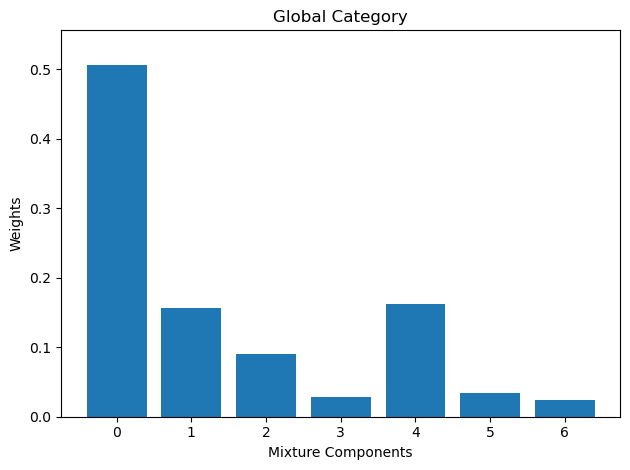

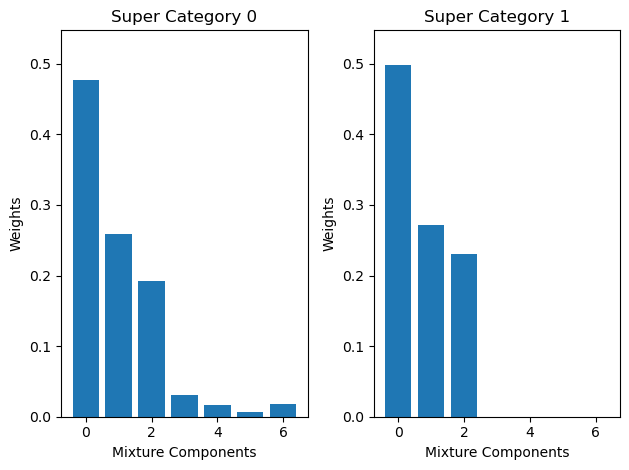

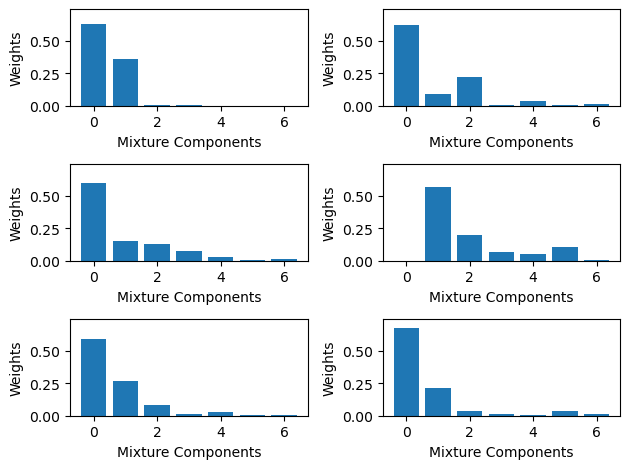


🔁 Round 2 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 355835.44
📌 Optimizing model...
  [Model] Step 0, loss = 347419.72
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


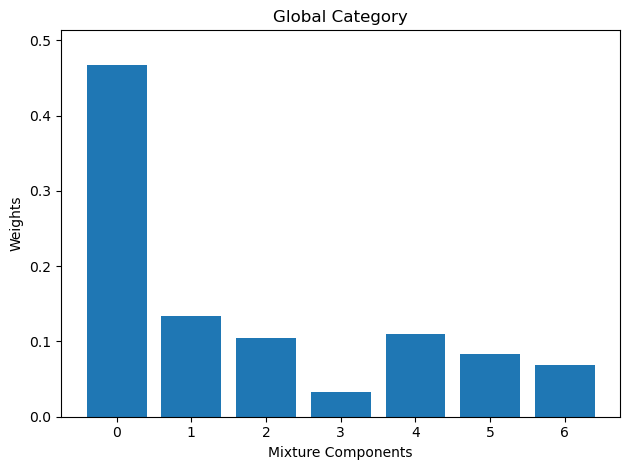

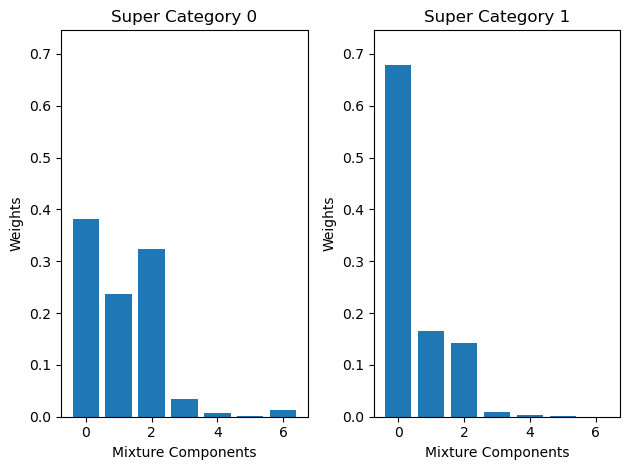

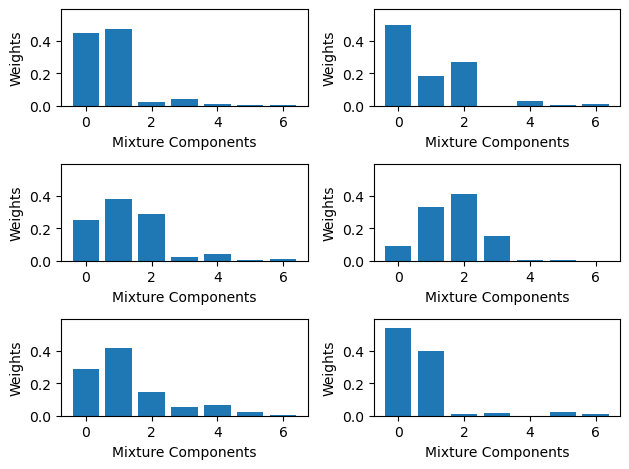


🔁 Round 3 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 350463.13
📌 Optimizing model...
  [Model] Step 0, loss = 345797.91
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


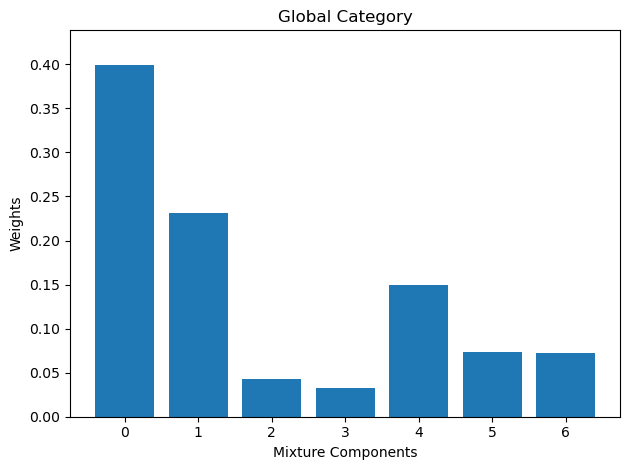

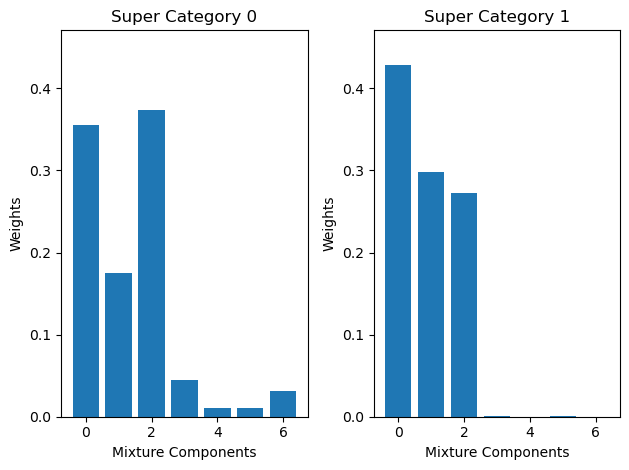

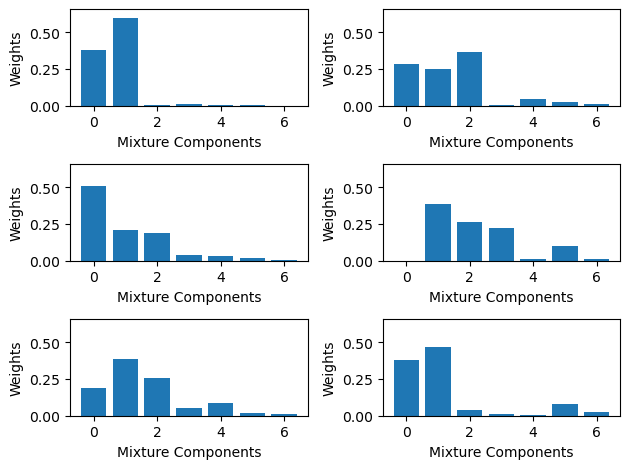


🔁 Round 4 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 329170.24
📌 Optimizing model...
  [Model] Step 0, loss = 353462.29
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


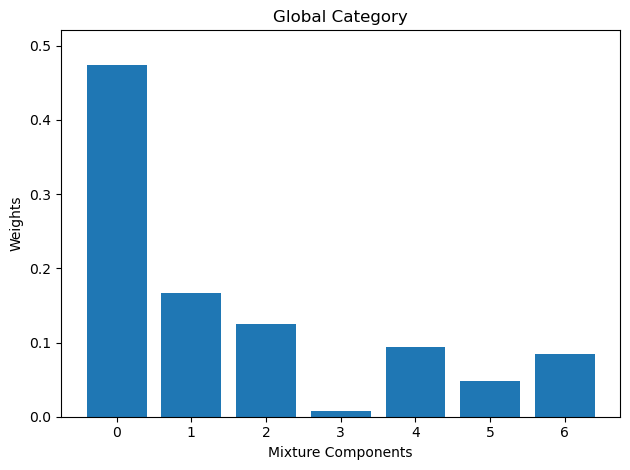

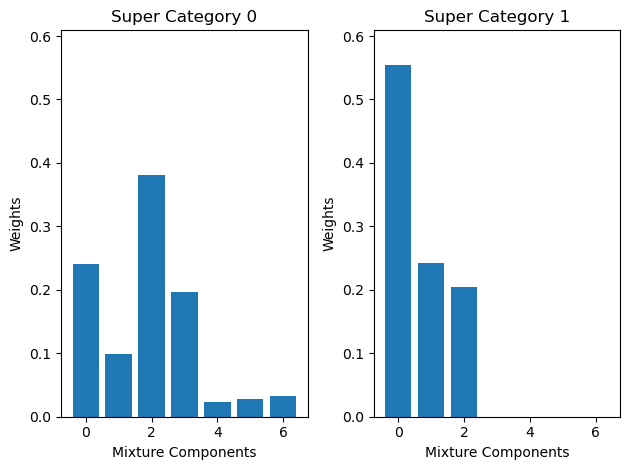

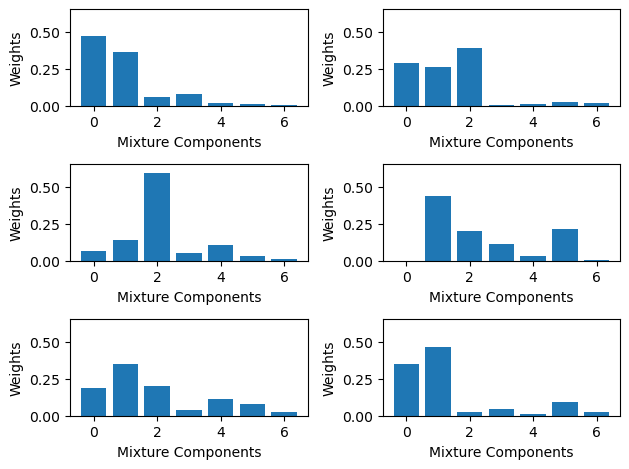


🔁 Round 5 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 340220.73
📌 Optimizing model...
  [Model] Step 0, loss = 322739.10
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


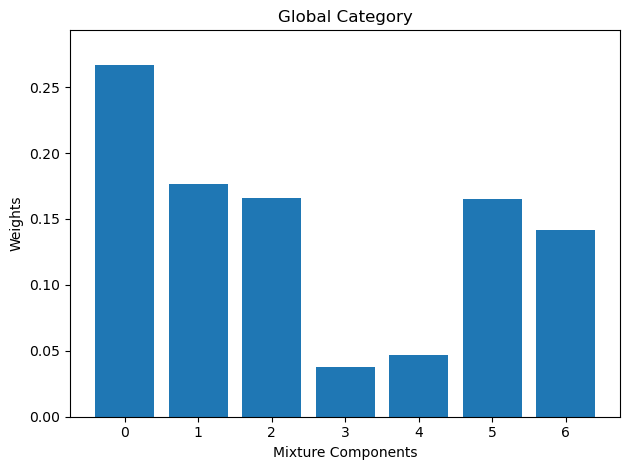

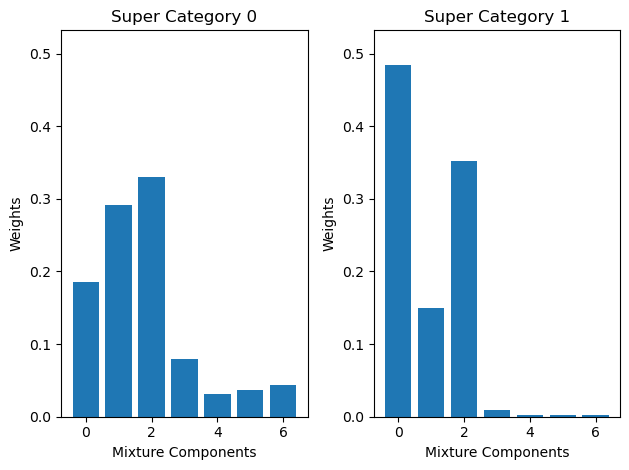

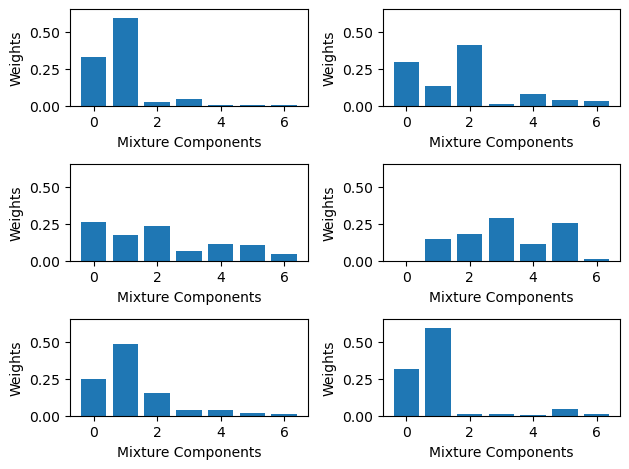


🔁 Round 6 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 339170.00
📌 Optimizing model...
  [Model] Step 0, loss = 324331.37
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


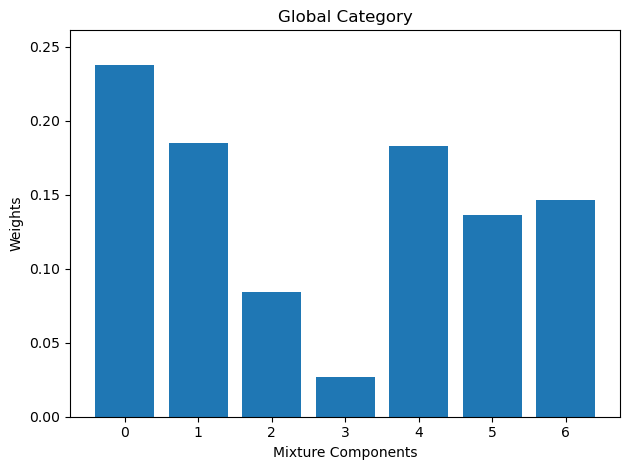

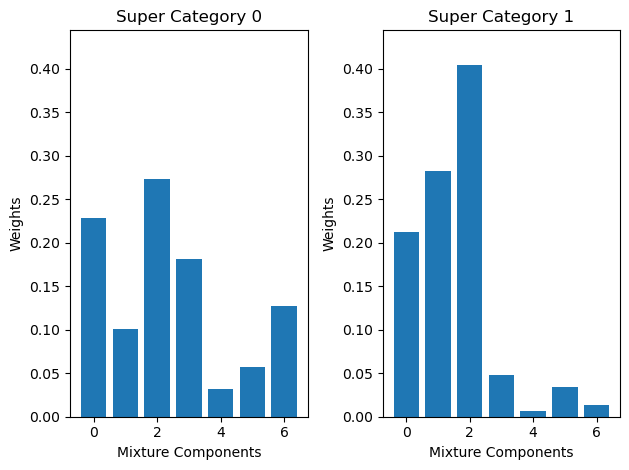

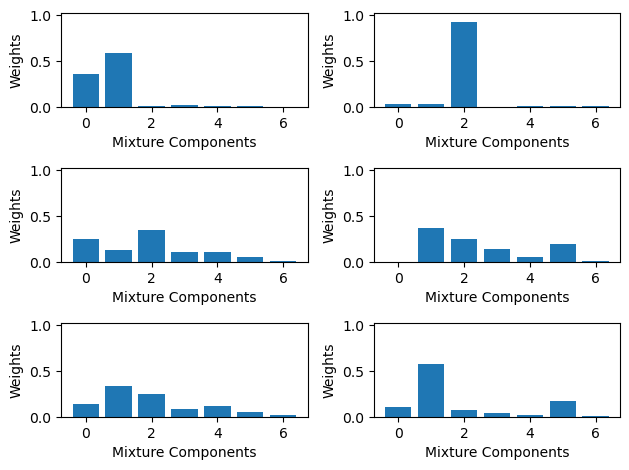


🔁 Round 7 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 337759.60
📌 Optimizing model...
  [Model] Step 0, loss = 339383.91
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


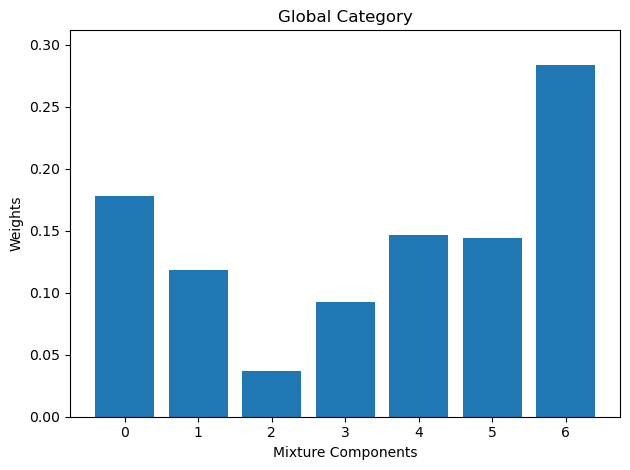

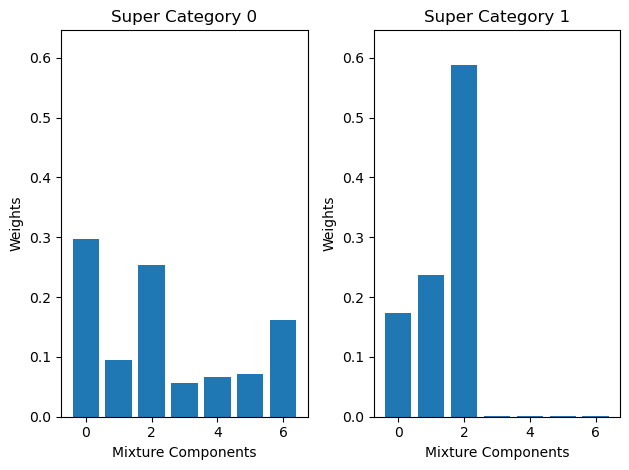

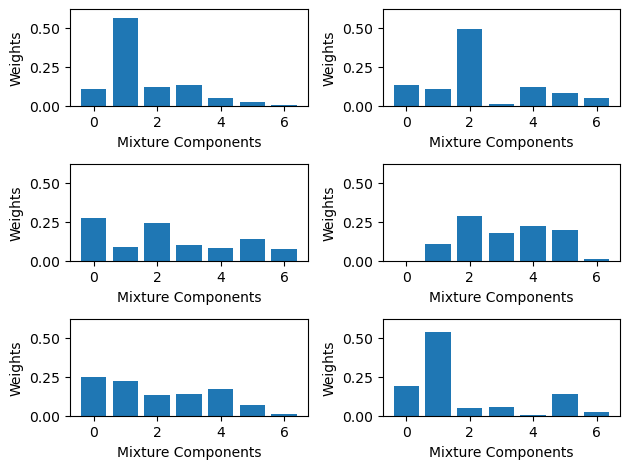


🔁 Round 8 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 336223.51
📌 Optimizing model...
  [Model] Step 0, loss = 327611.88
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


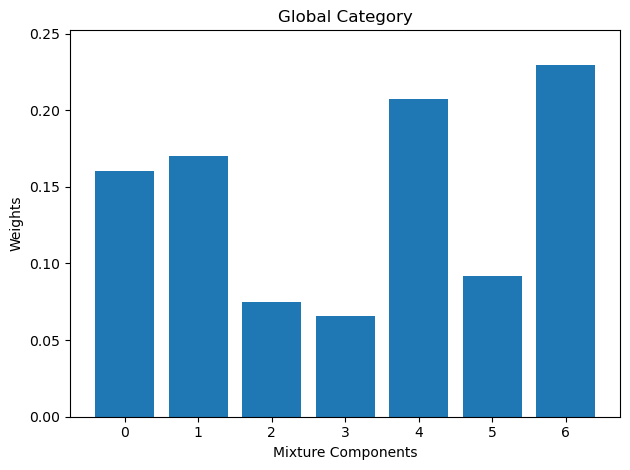

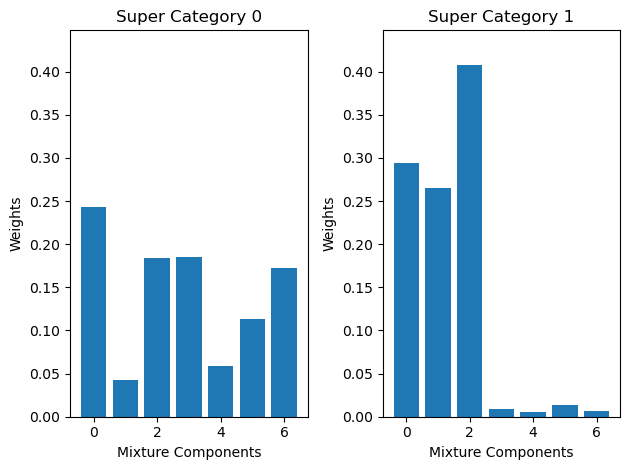

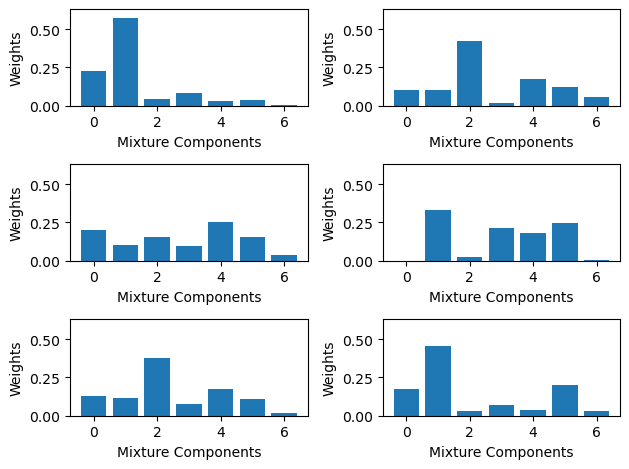


🔁 Round 9 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 337260.99
📌 Optimizing model...
  [Model] Step 0, loss = 332952.79
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


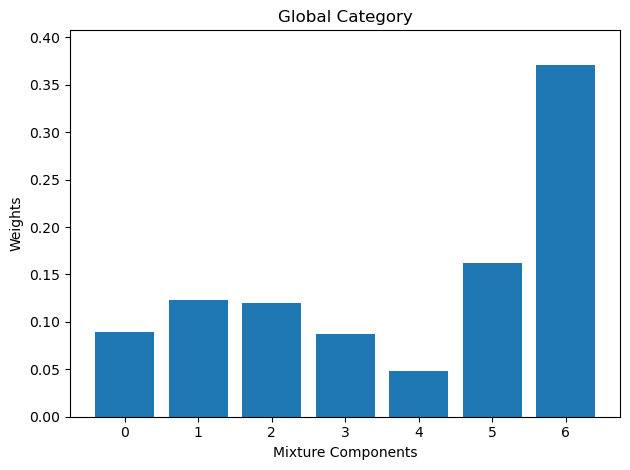

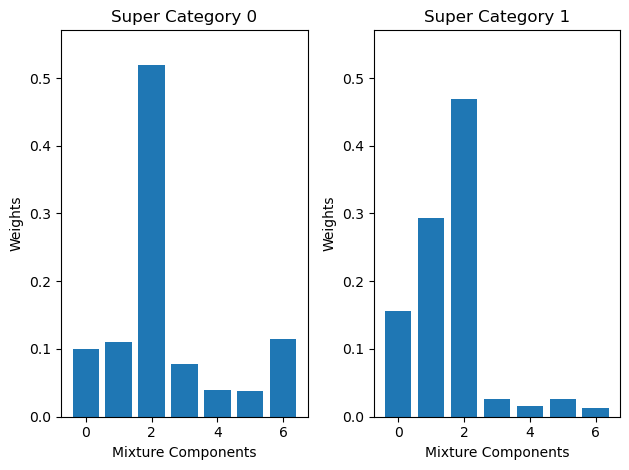

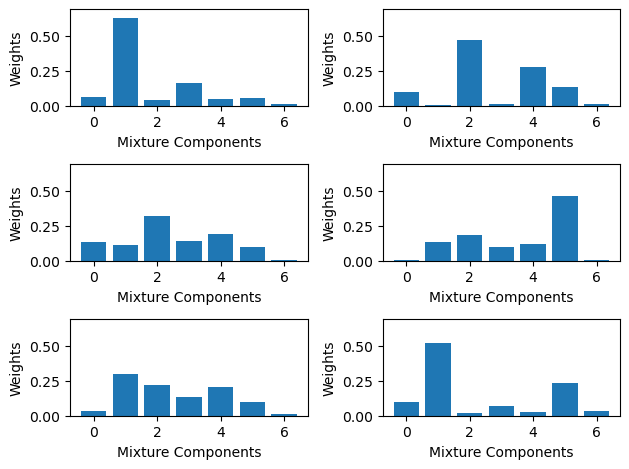


🔁 Round 10 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 337708.54
📌 Optimizing model...
  [Model] Step 0, loss = 334113.34
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


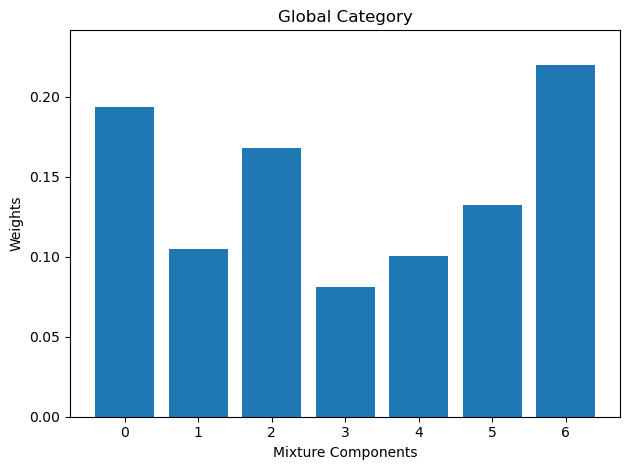

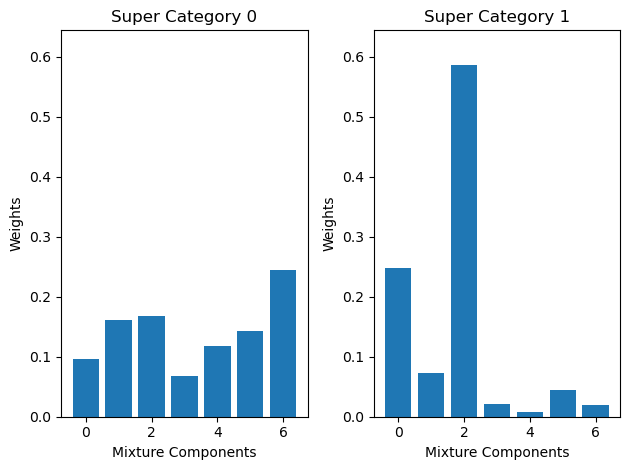

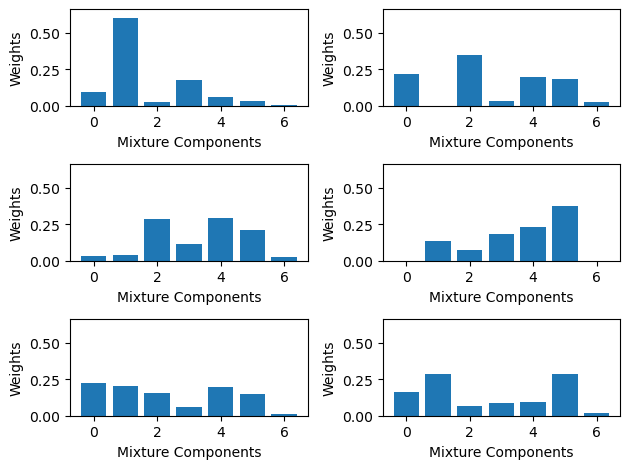


🔁 Round 11 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 330680.64
📌 Optimizing model...
  [Model] Step 0, loss = 325014.11
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


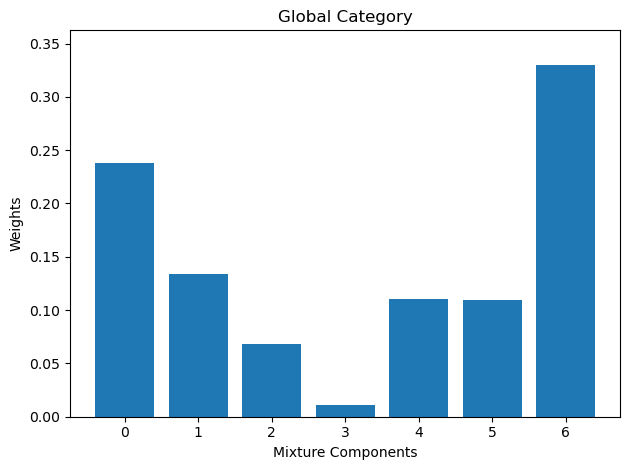

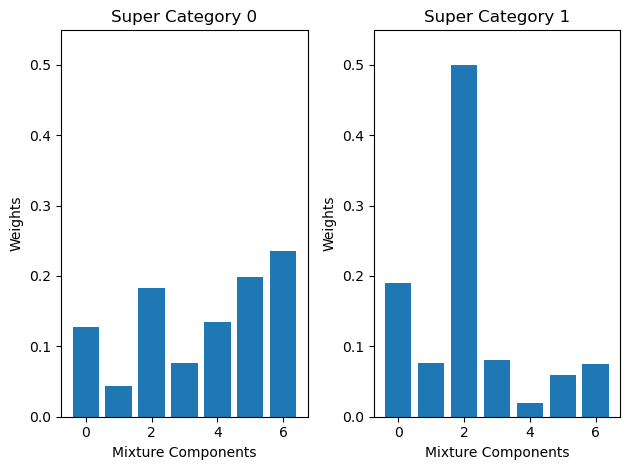

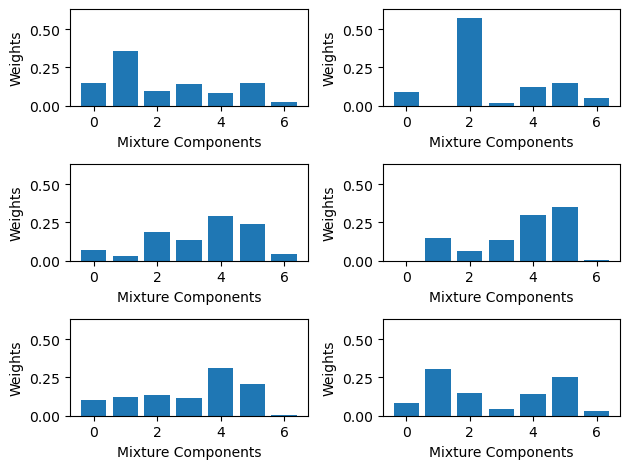


🔁 Round 12 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 320284.24
📌 Optimizing model...
  [Model] Step 0, loss = 318038.04
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


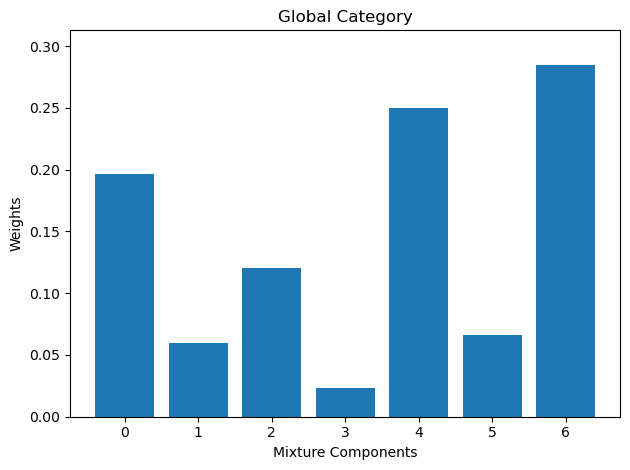

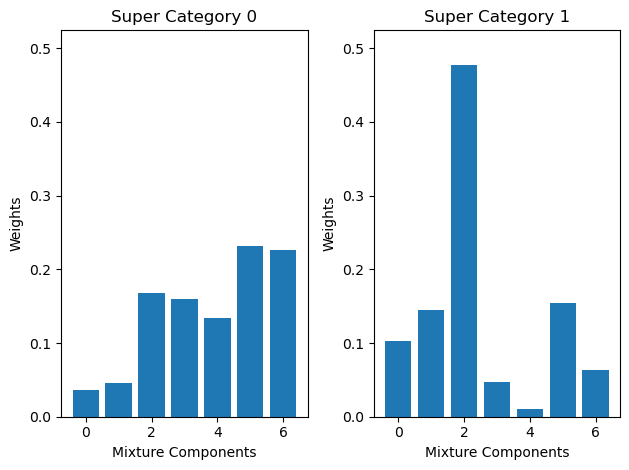

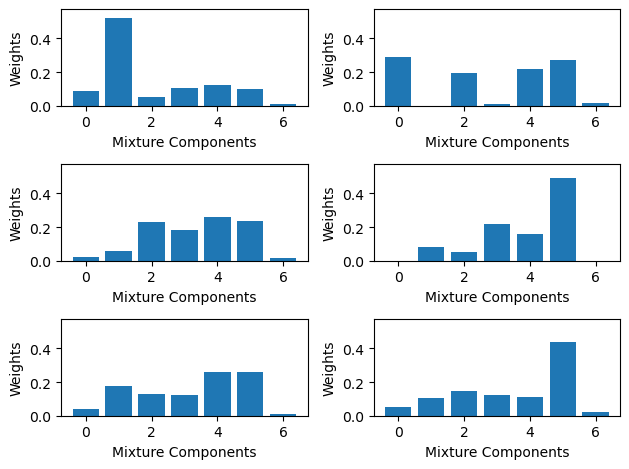


🔁 Round 13 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 320883.51
📌 Optimizing model...
  [Model] Step 0, loss = 323098.55
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


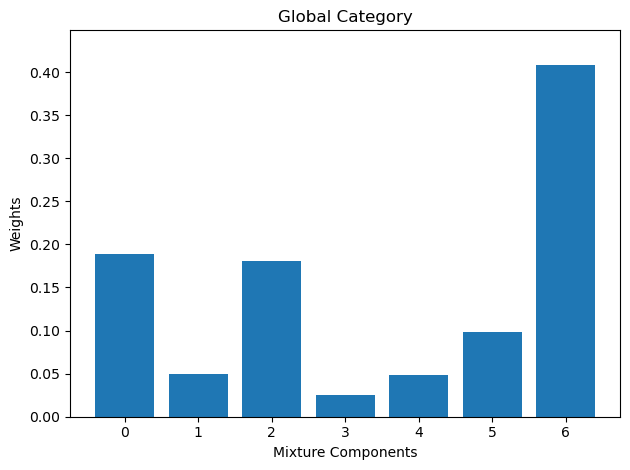

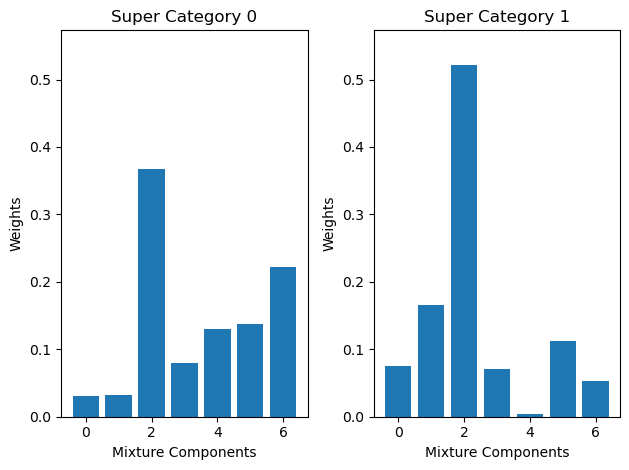

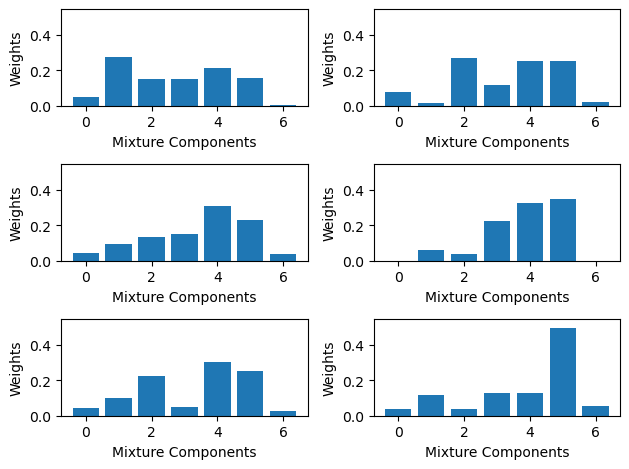


🔁 Round 14 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 325175.62
📌 Optimizing model...
  [Model] Step 0, loss = 326058.38
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


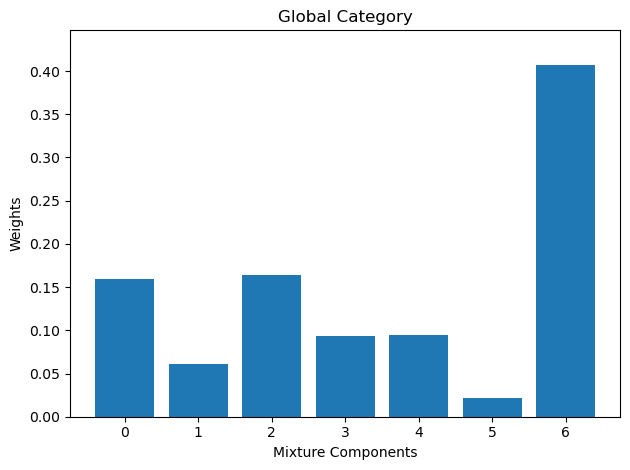

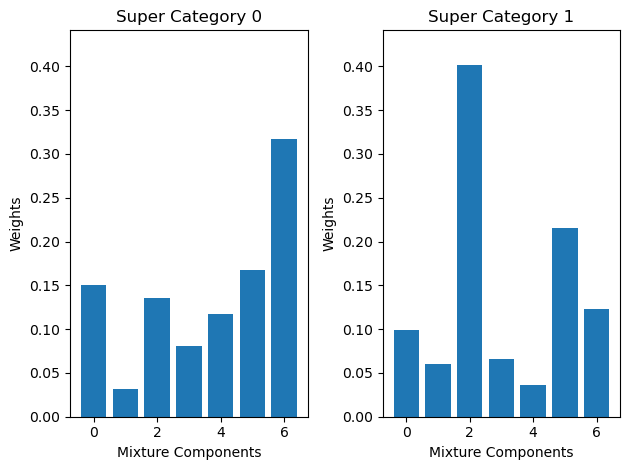

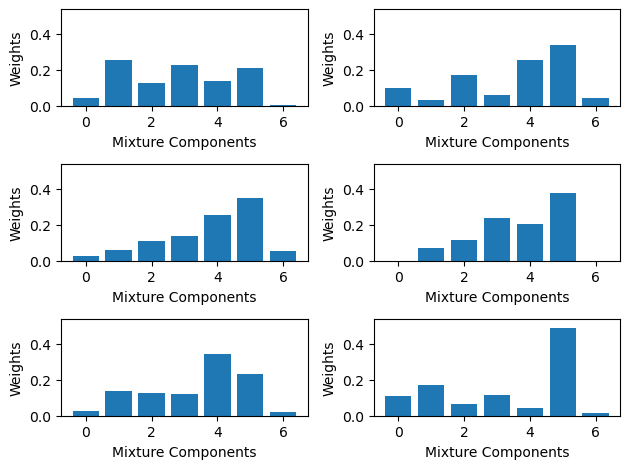


🔁 Round 15 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 356251.74
📌 Optimizing model...
  [Model] Step 0, loss = 326384.38
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


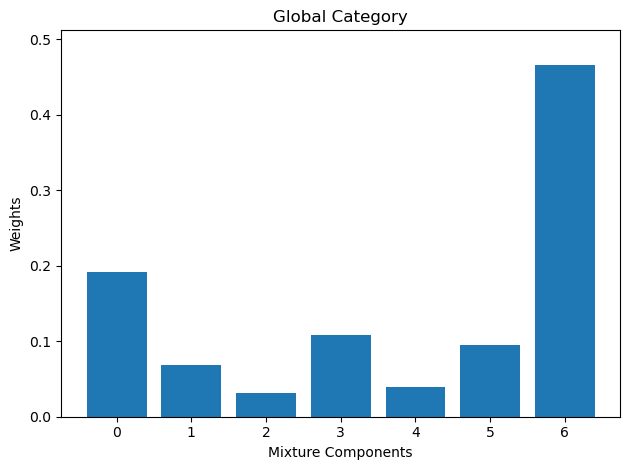

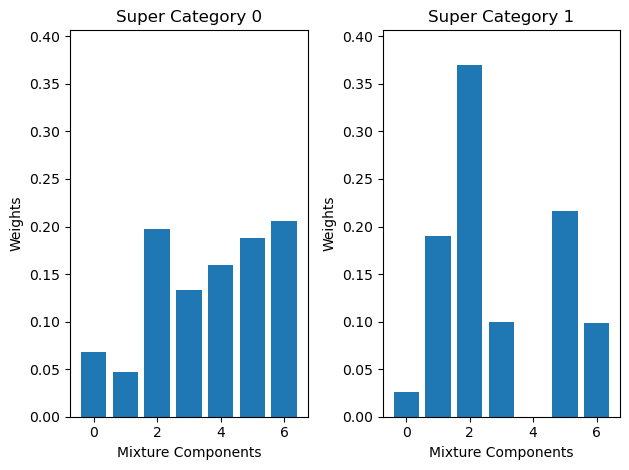

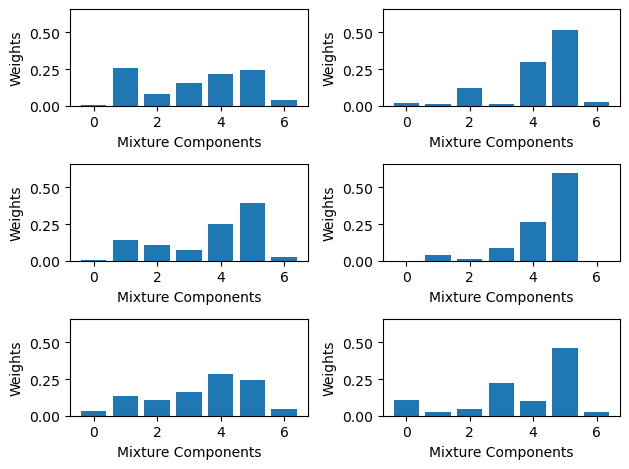


🔁 Round 16 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 326409.41
📌 Optimizing model...
  [Model] Step 0, loss = 322233.92
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


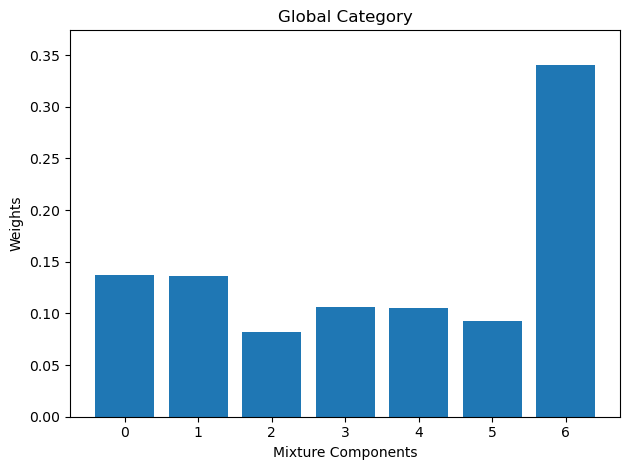

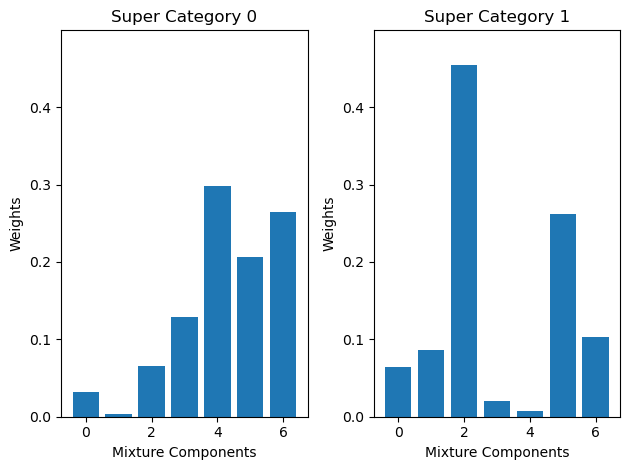

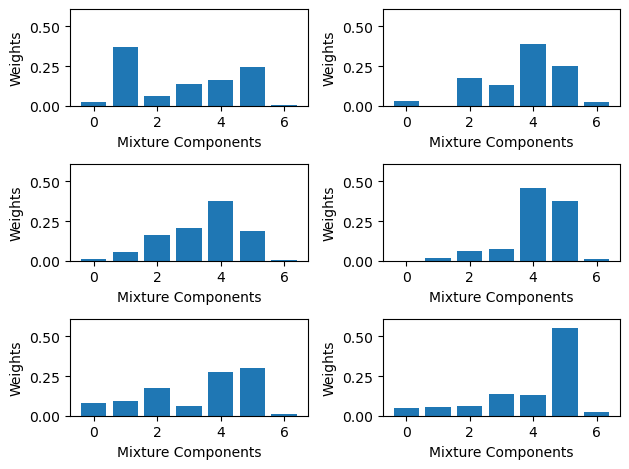


🔁 Round 17 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 321238.96
📌 Optimizing model...
  [Model] Step 0, loss = 313635.77
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


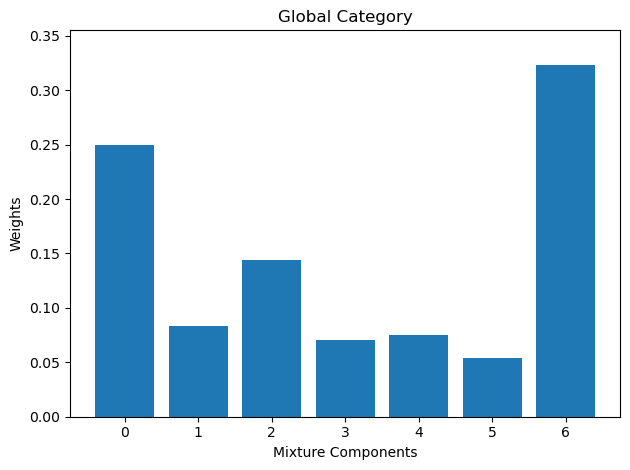

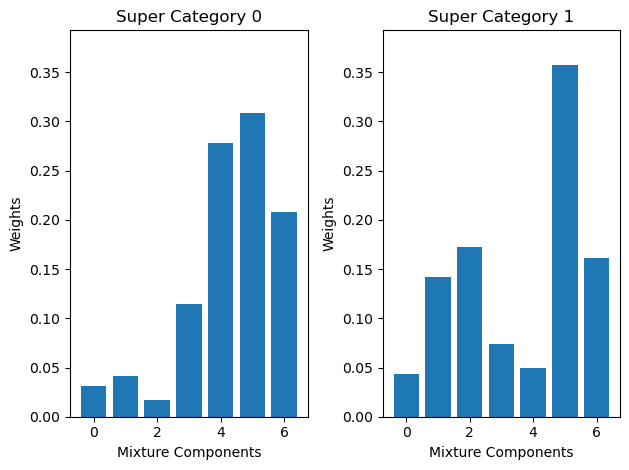

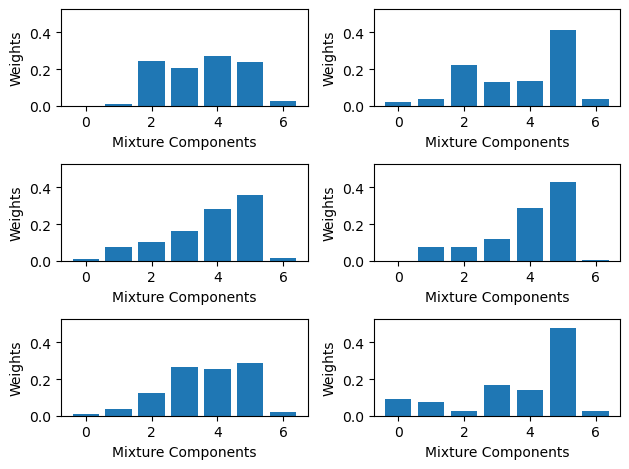


🔁 Round 18 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 318887.87
📌 Optimizing model...
  [Model] Step 0, loss = 317643.49
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


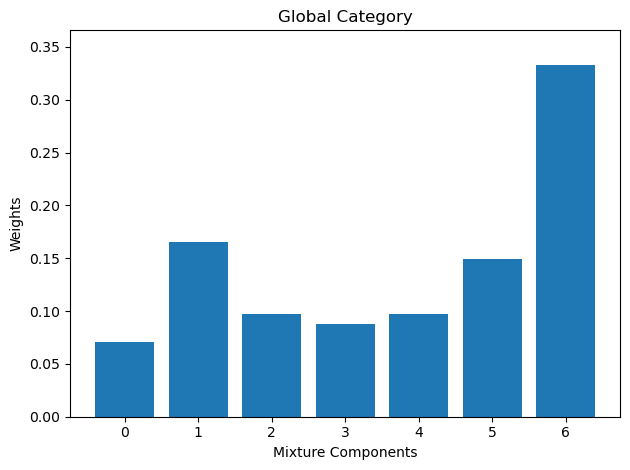

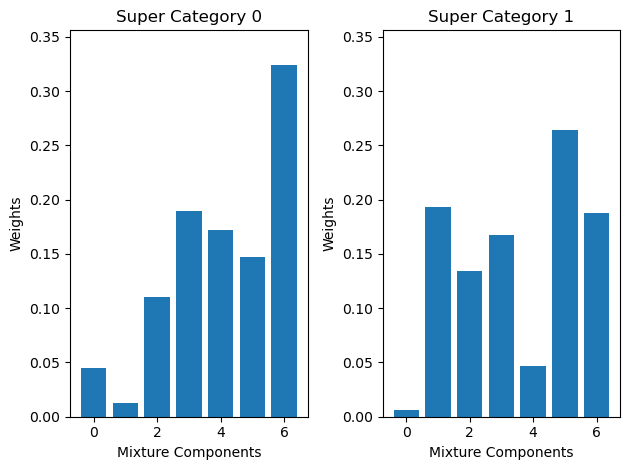

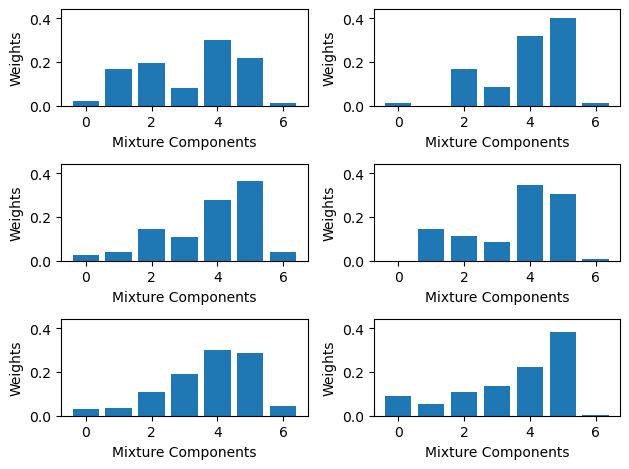


🔁 Round 19 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 324981.70
📌 Optimizing model...
  [Model] Step 0, loss = 316214.26
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


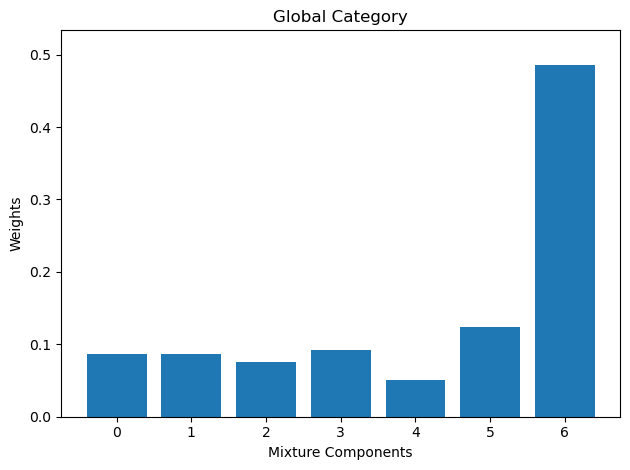

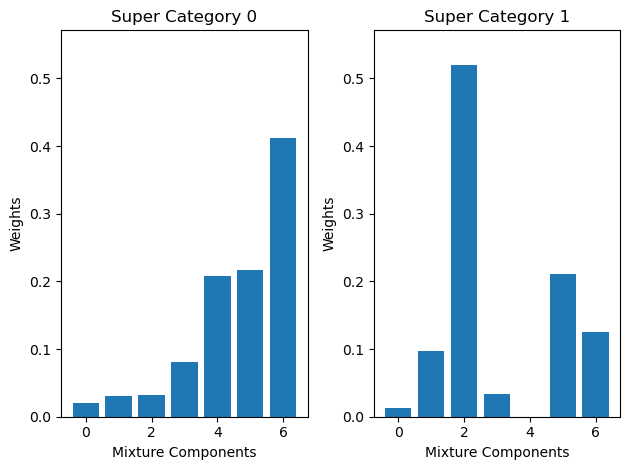

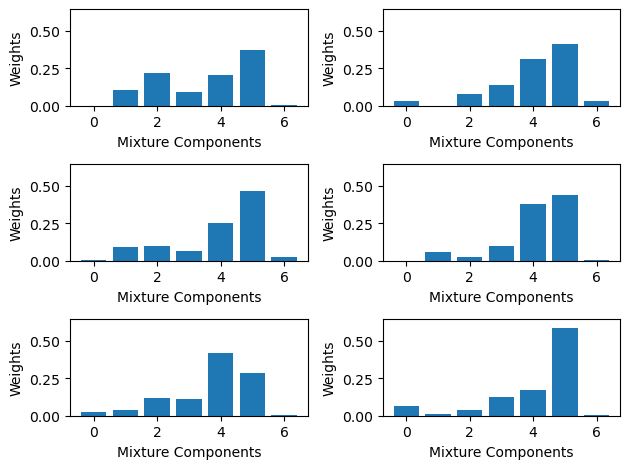


🔁 Round 20 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 312893.07
📌 Optimizing model...
  [Model] Step 0, loss = 316690.61
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


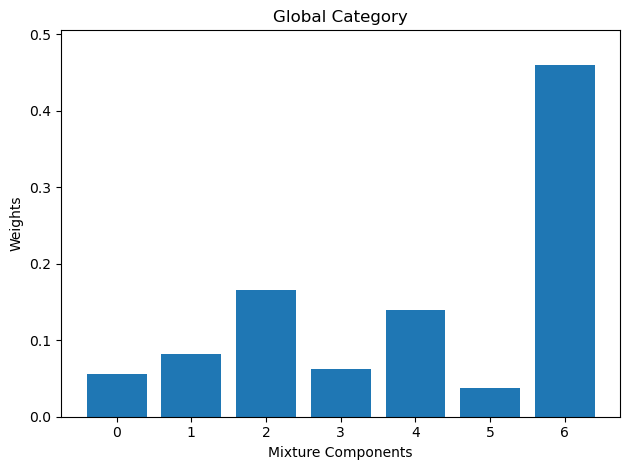

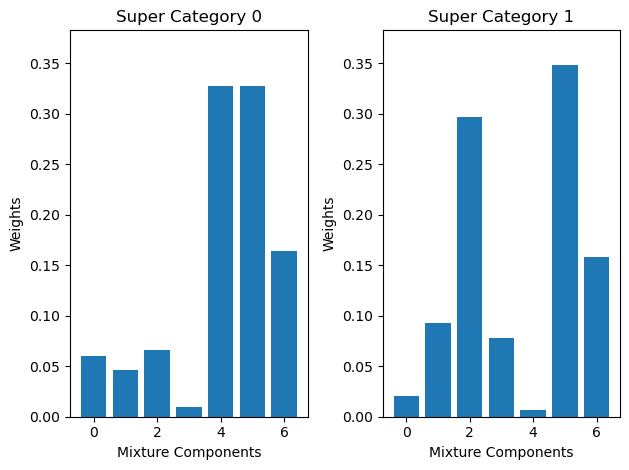

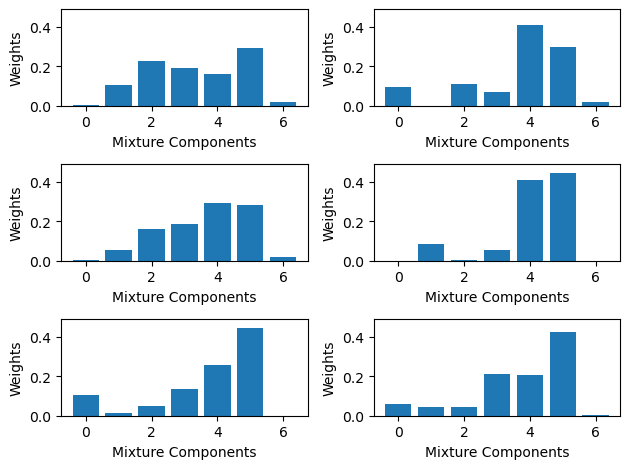


🔁 Round 21 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 317600.85
📌 Optimizing model...
  [Model] Step 0, loss = 319167.83
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


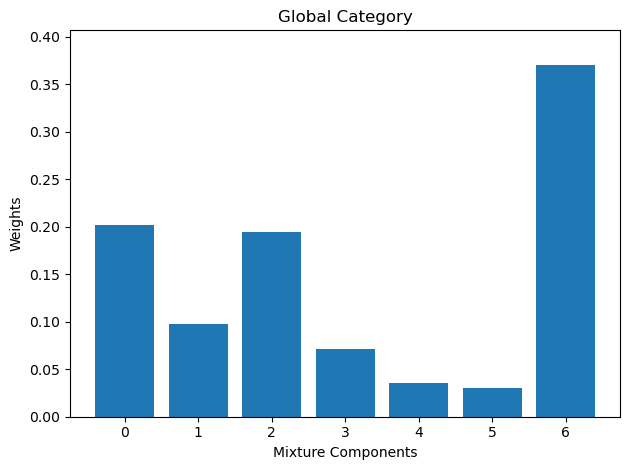

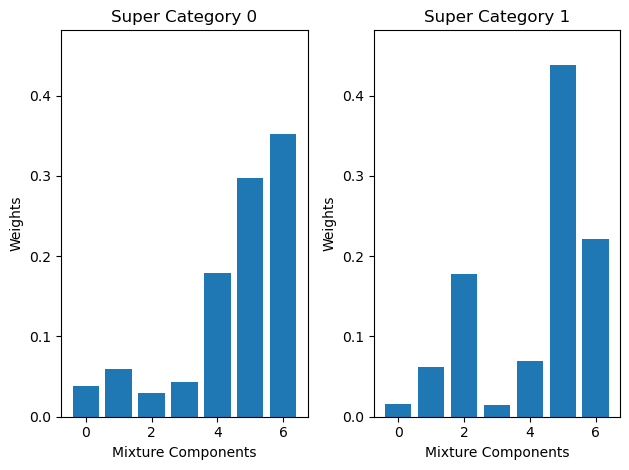

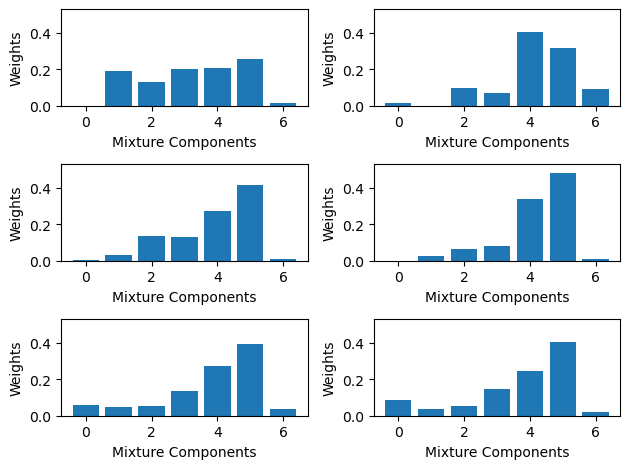


🔁 Round 22 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 315681.90
📌 Optimizing model...
  [Model] Step 0, loss = 323179.87
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


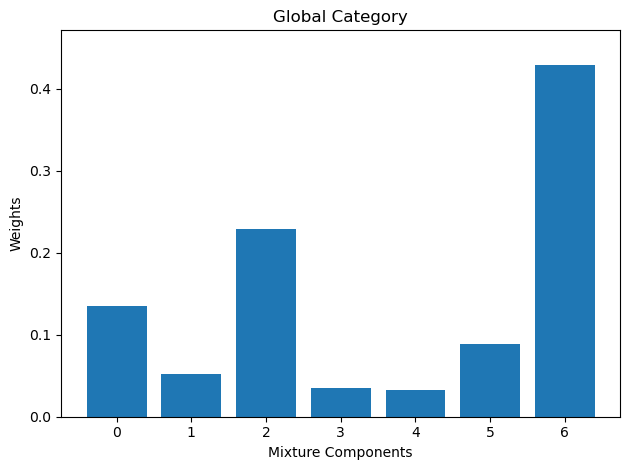

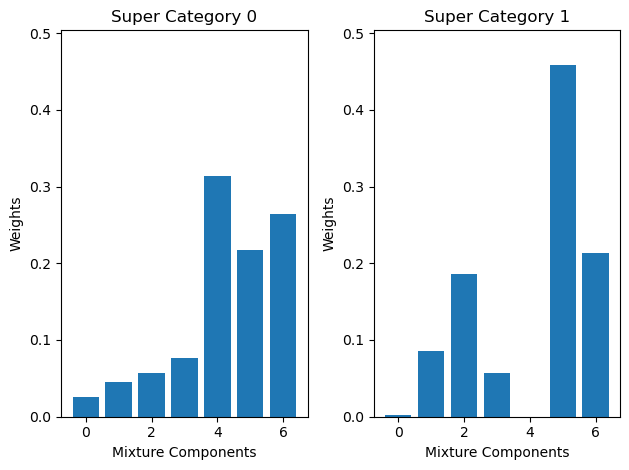

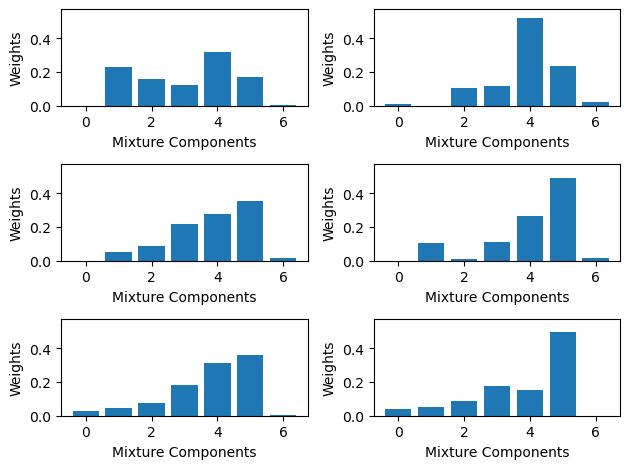


🔁 Round 23 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 313991.70
📌 Optimizing model...
  [Model] Step 0, loss = 320012.24
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


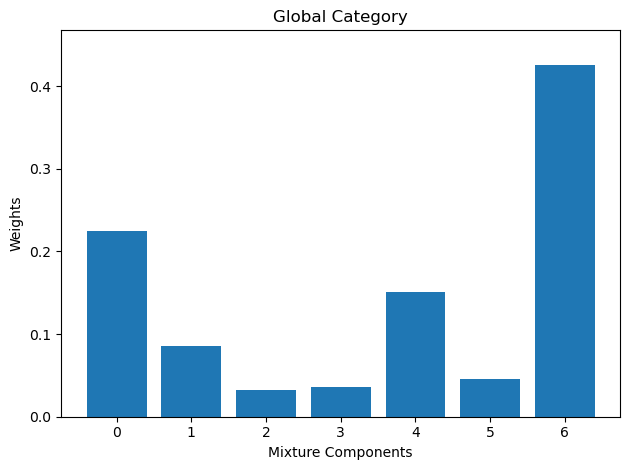

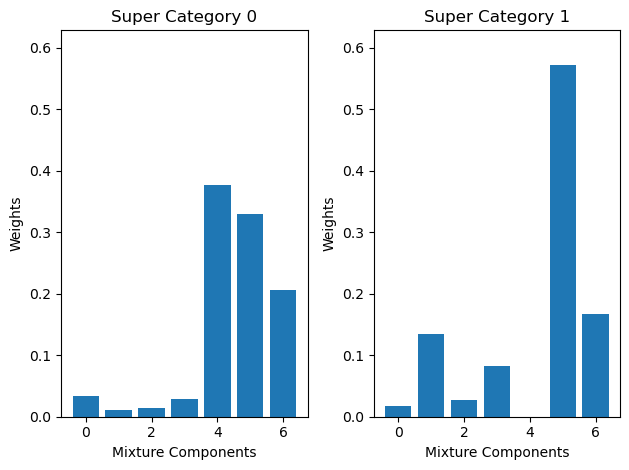

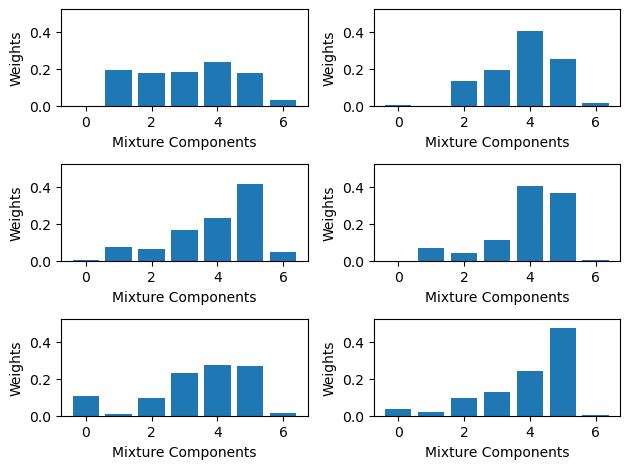


🔁 Round 24 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 319456.30
📌 Optimizing model...
  [Model] Step 0, loss = 316089.30
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


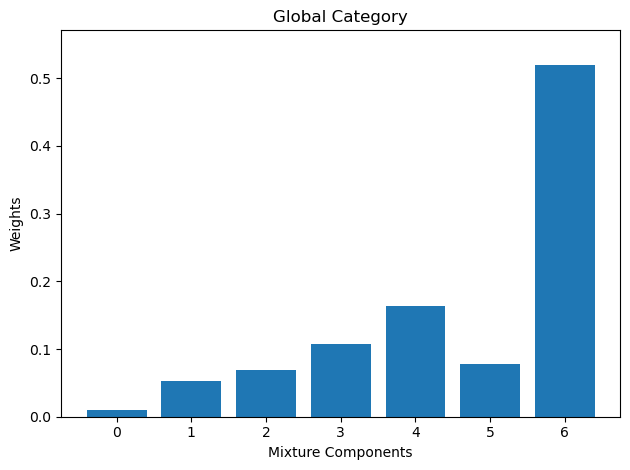

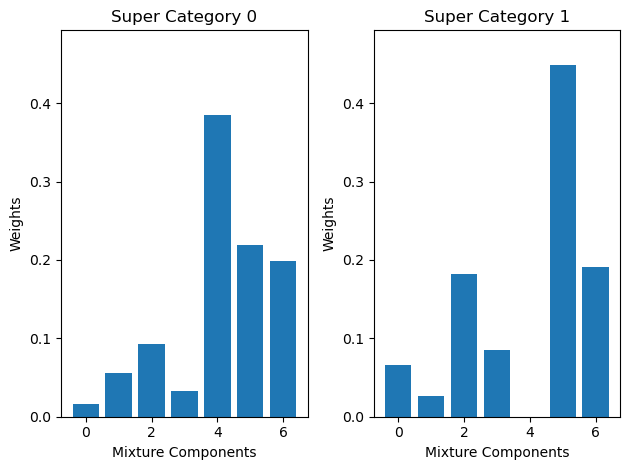

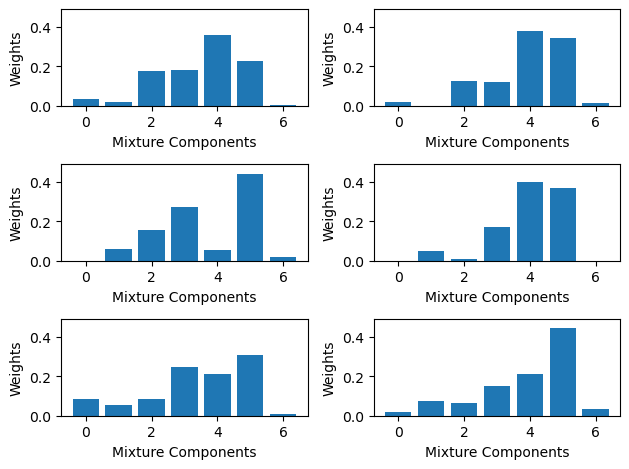


🔁 Round 25 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 316261.16
📌 Optimizing model...
  [Model] Step 0, loss = 323523.08
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


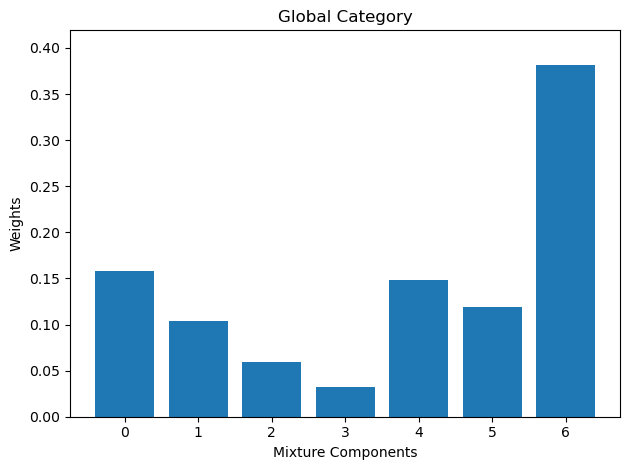

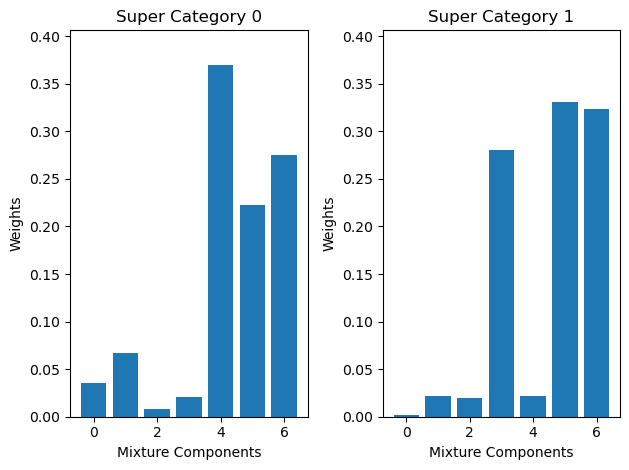

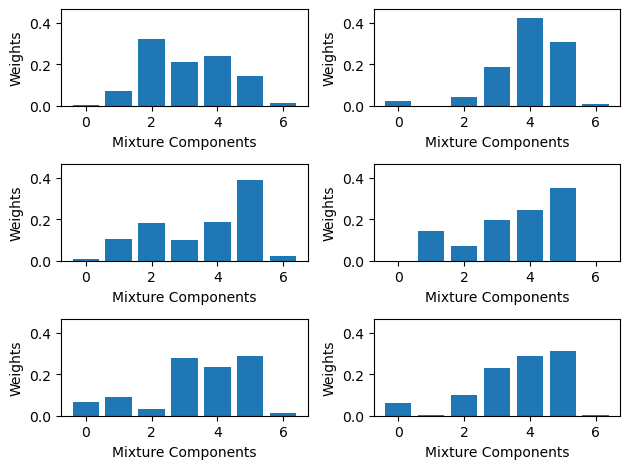


🔁 Round 26 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 317205.46
📌 Optimizing model...
  [Model] Step 0, loss = 319015.81
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


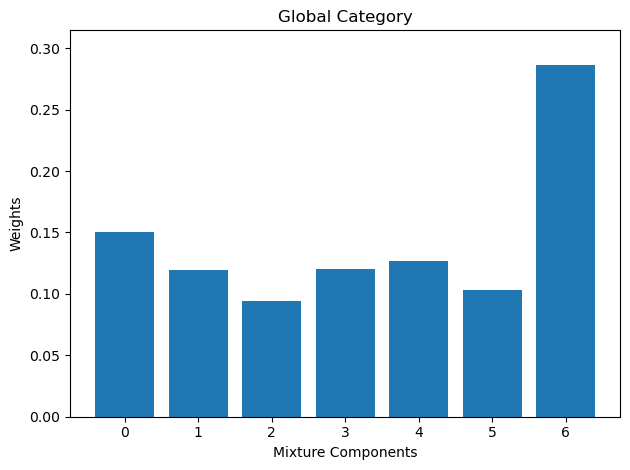

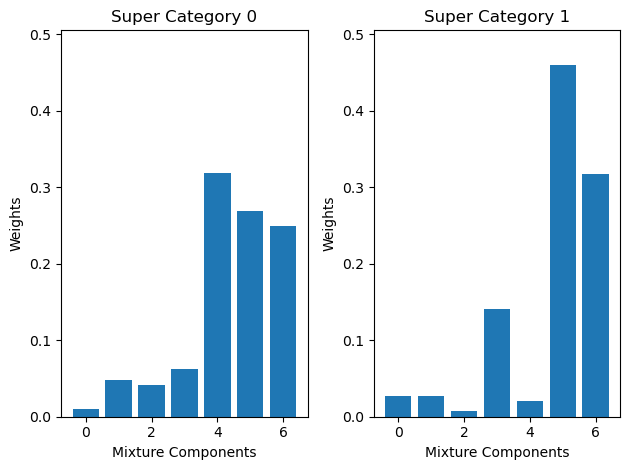

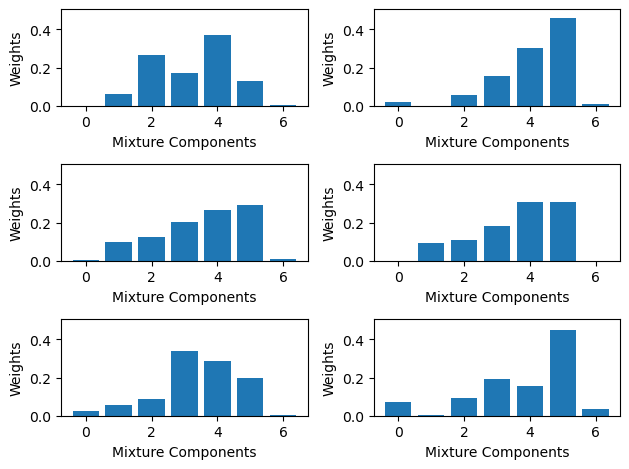


🔁 Round 27 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 316644.57
📌 Optimizing model...
  [Model] Step 0, loss = 313243.96
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


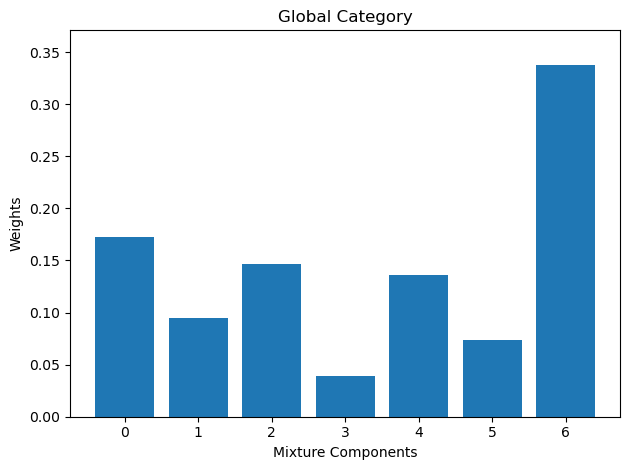

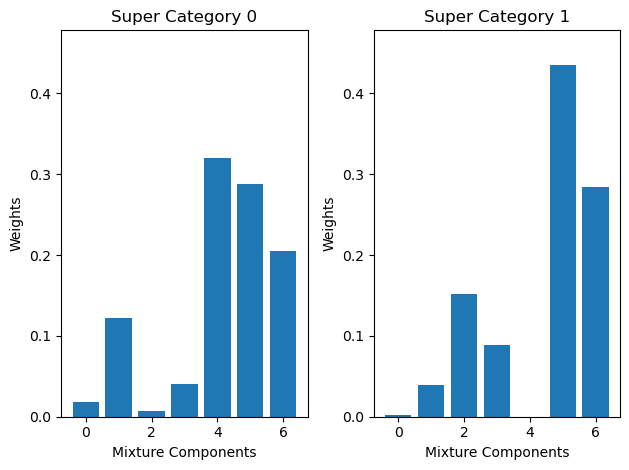

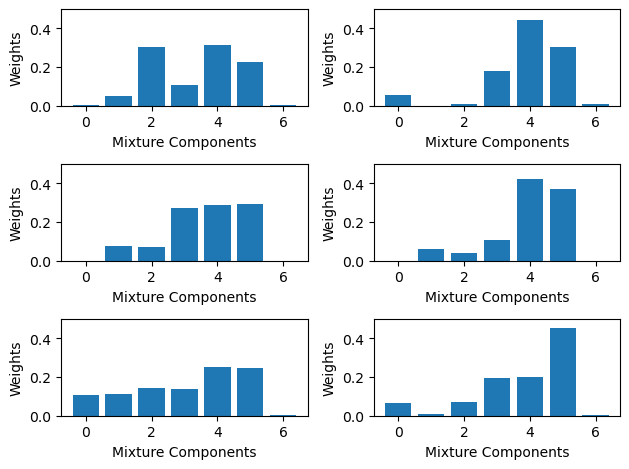


🔁 Round 28 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 319728.37
📌 Optimizing model...
  [Model] Step 0, loss = 318704.13
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


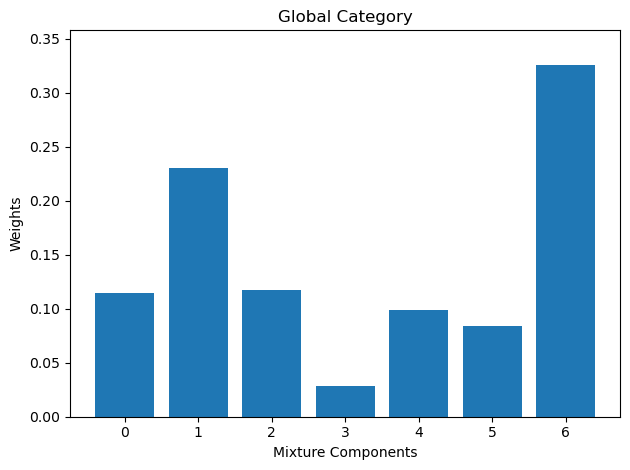

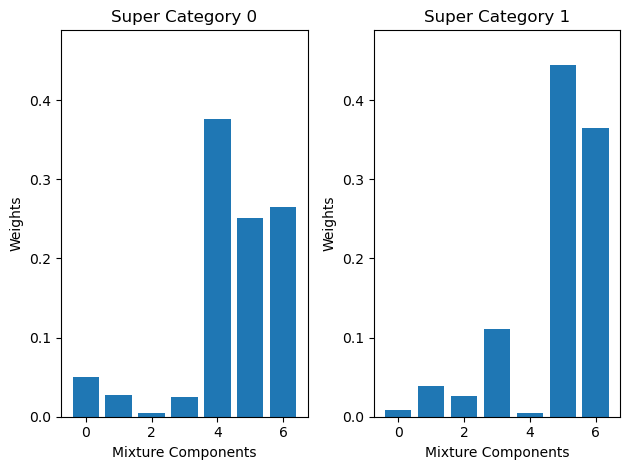

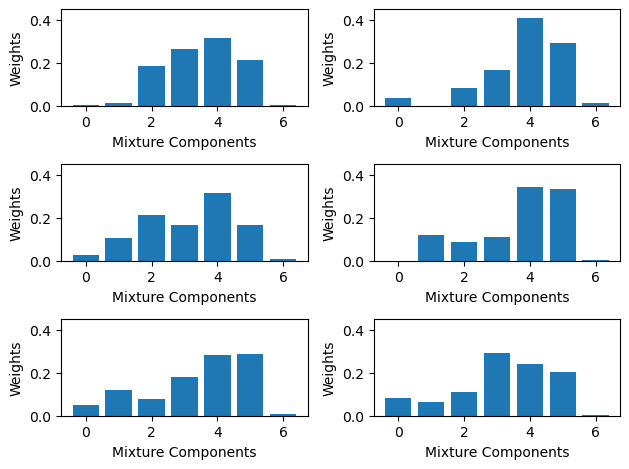


🔁 Round 29 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 314494.91
📌 Optimizing model...
  [Model] Step 0, loss = 317881.93
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


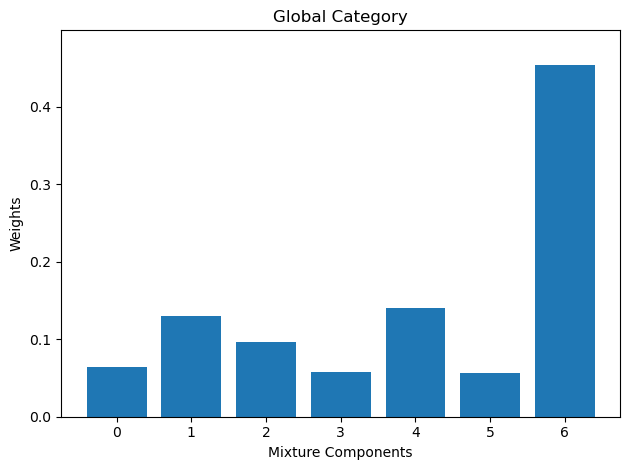

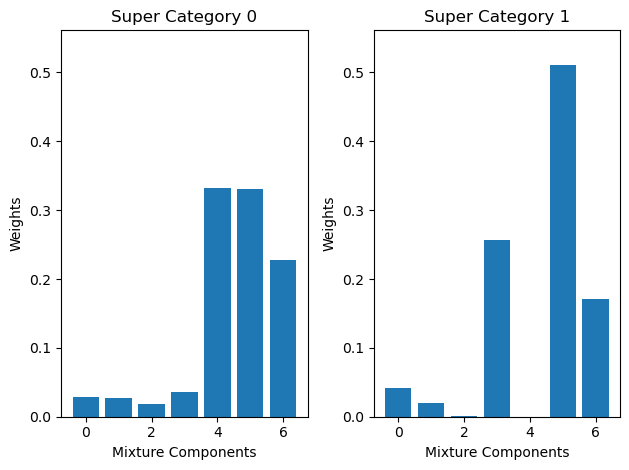

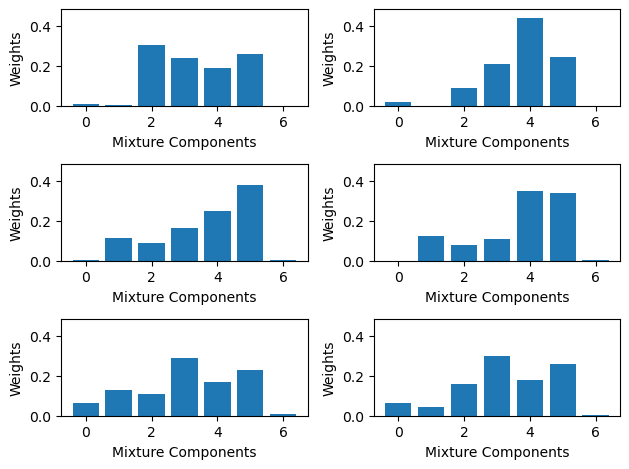


🔁 Round 30 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 316511.05
📌 Optimizing model...
  [Model] Step 0, loss = 313058.86
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


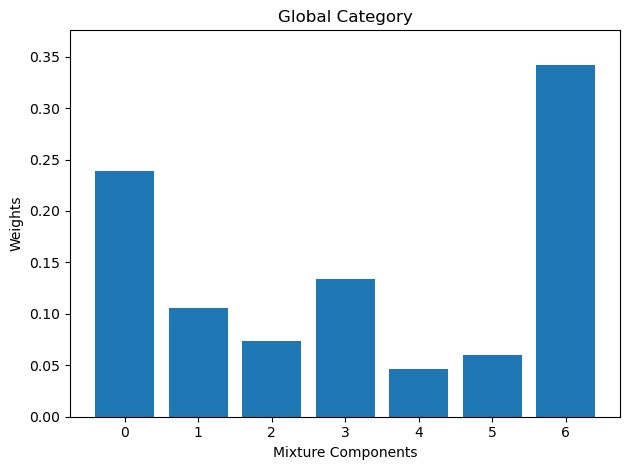

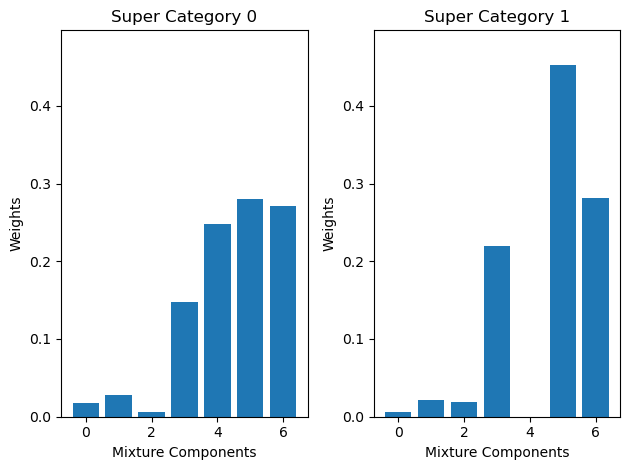

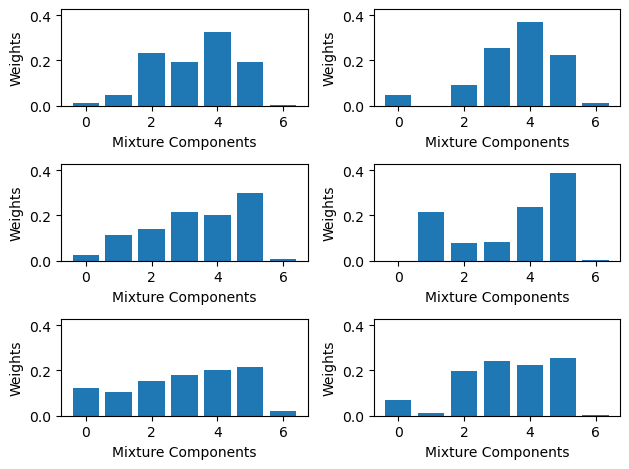


🔁 Round 31 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 316157.41
📌 Optimizing model...
  [Model] Step 0, loss = 315762.77
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


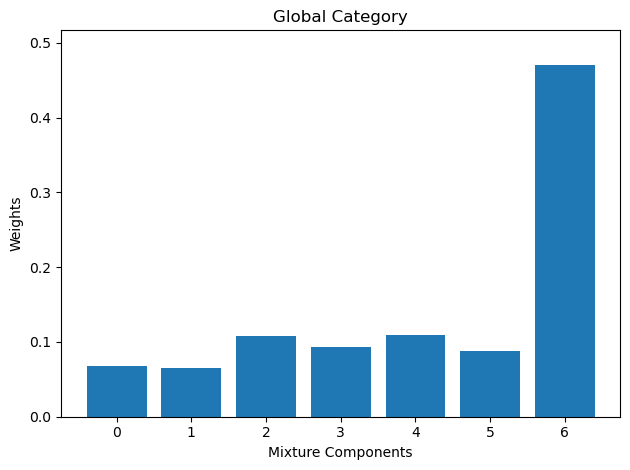

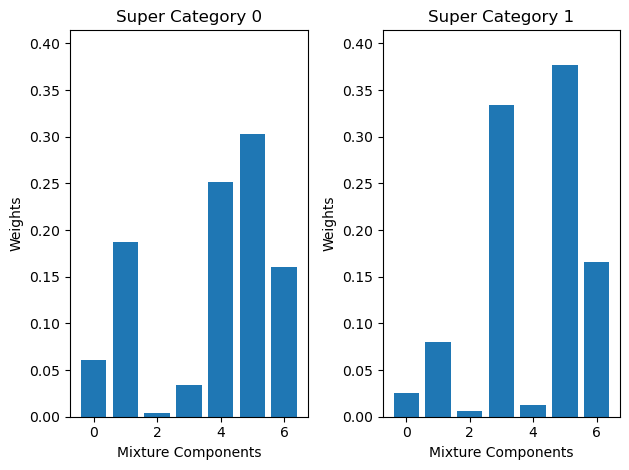

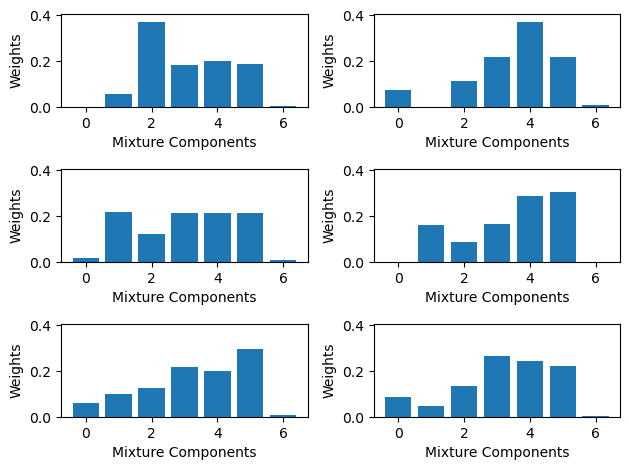


🔁 Round 32 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 316090.39
📌 Optimizing model...
  [Model] Step 0, loss = 324606.47
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


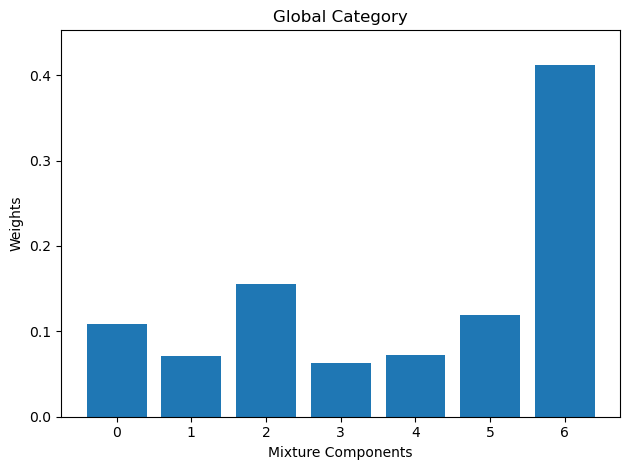

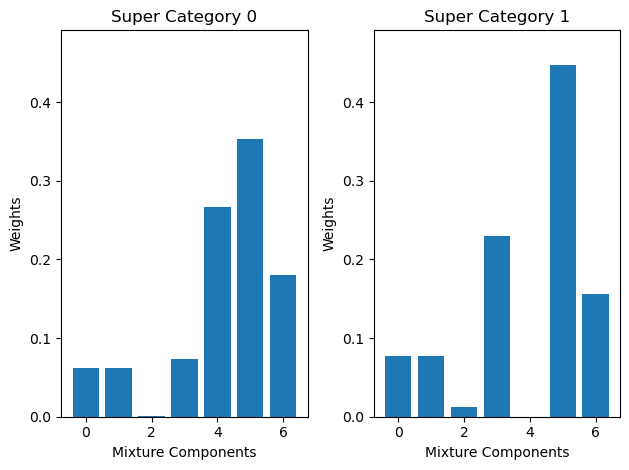

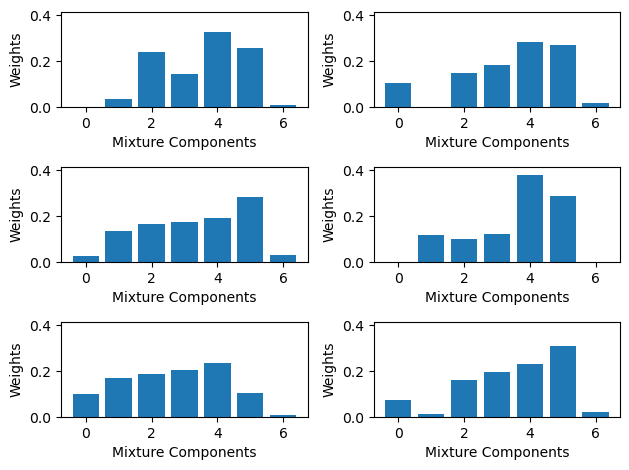


🔁 Round 33 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 312530.37
📌 Optimizing model...
  [Model] Step 0, loss = 317344.33
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


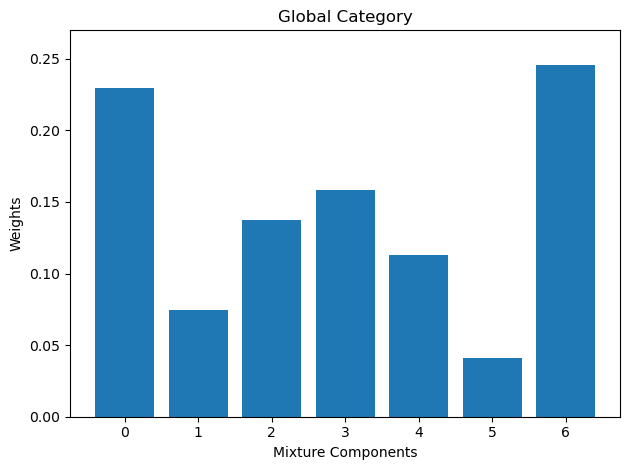

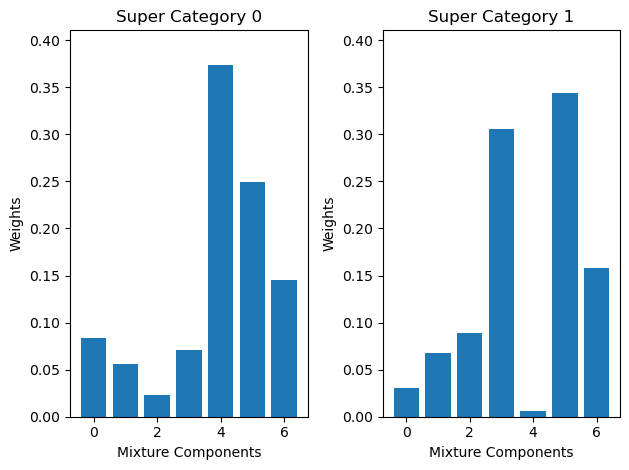

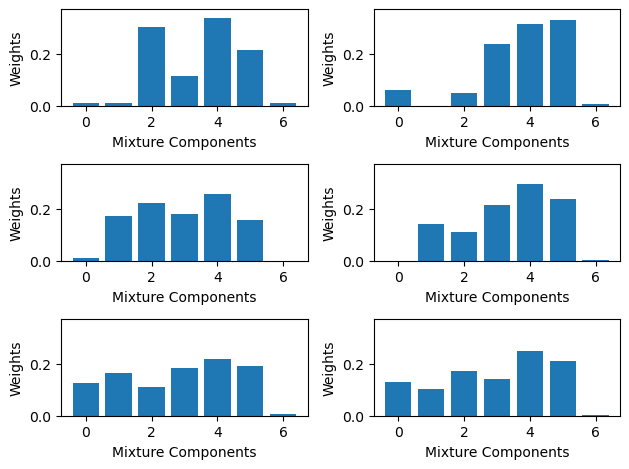


🔁 Round 34 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 317470.14
📌 Optimizing model...
  [Model] Step 0, loss = 310131.00
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


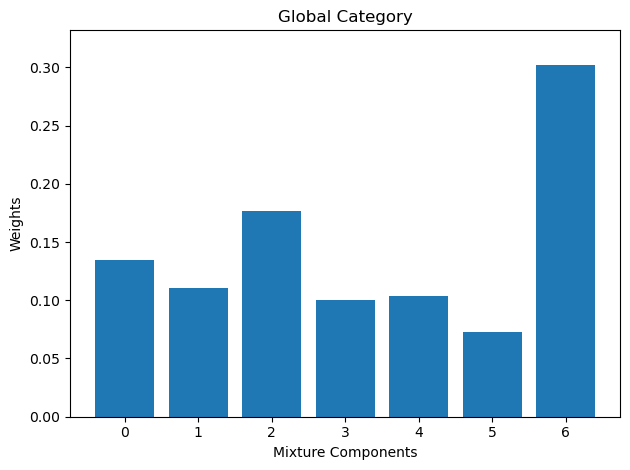

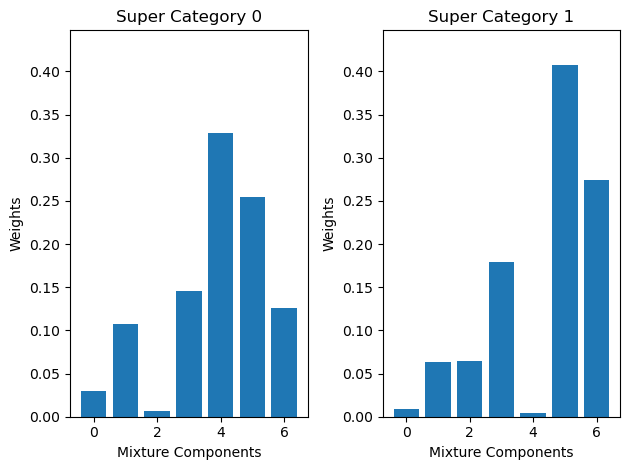

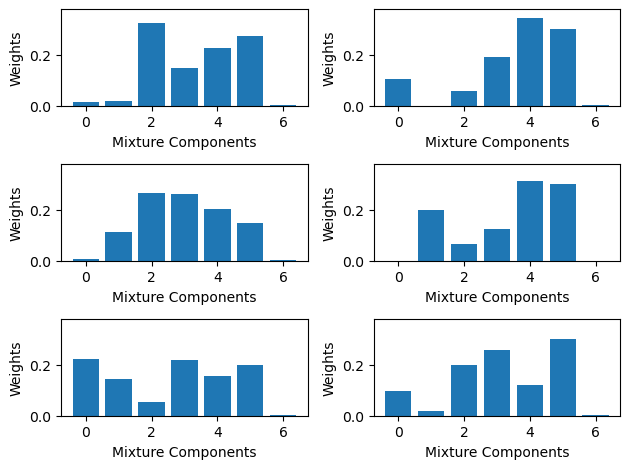


🔁 Round 35 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 312827.07
📌 Optimizing model...
  [Model] Step 0, loss = 318282.27
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


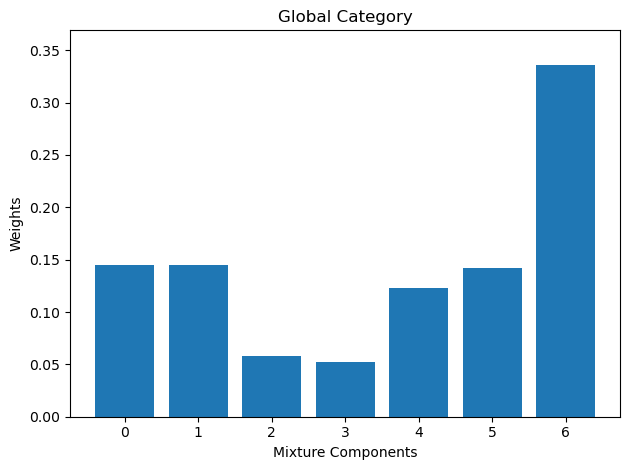

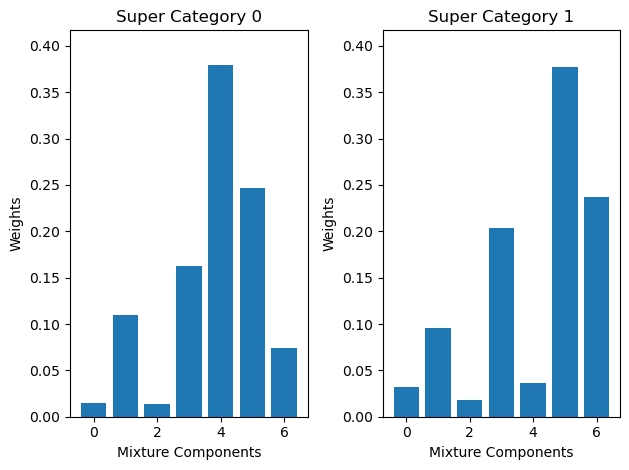

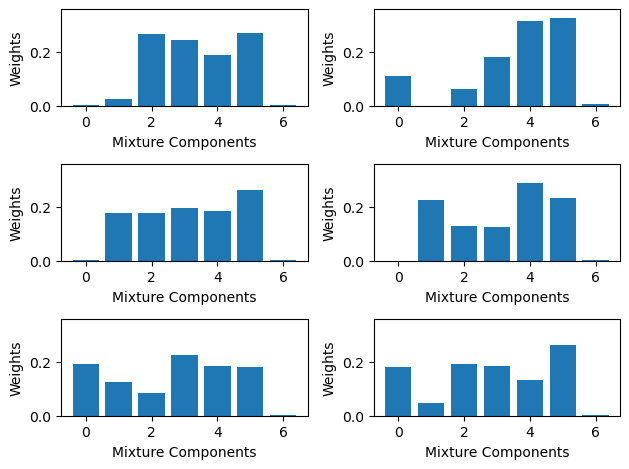


🔁 Round 36 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 313761.09
📌 Optimizing model...
  [Model] Step 0, loss = 318256.47
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


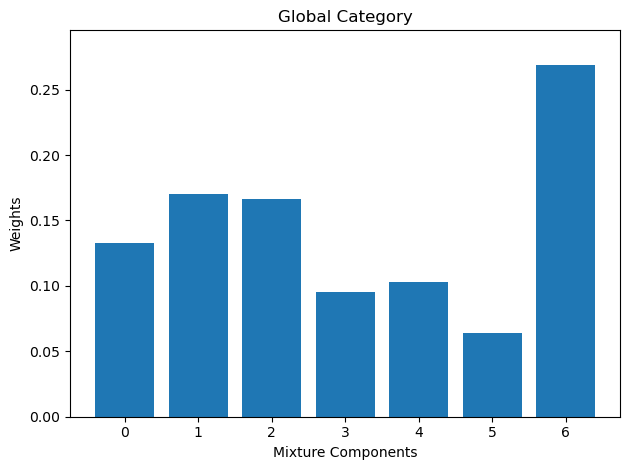

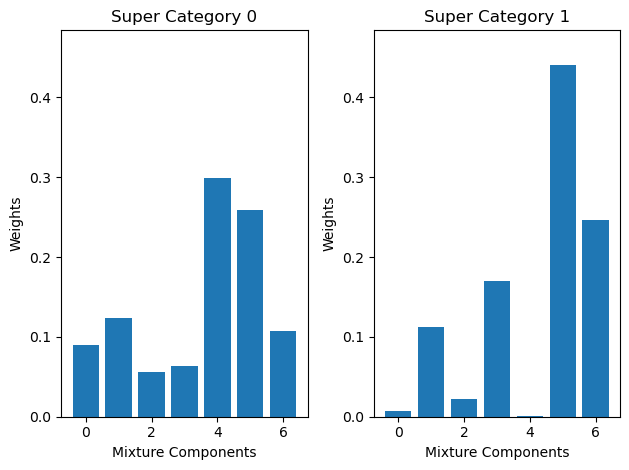

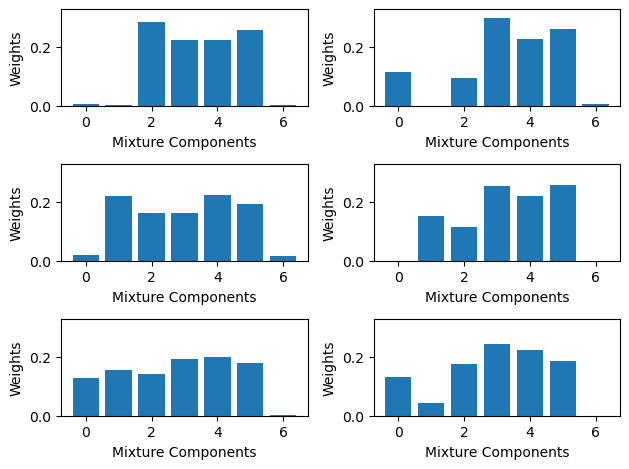


🔁 Round 37 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 317259.83
📌 Optimizing model...
  [Model] Step 0, loss = 321312.14
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


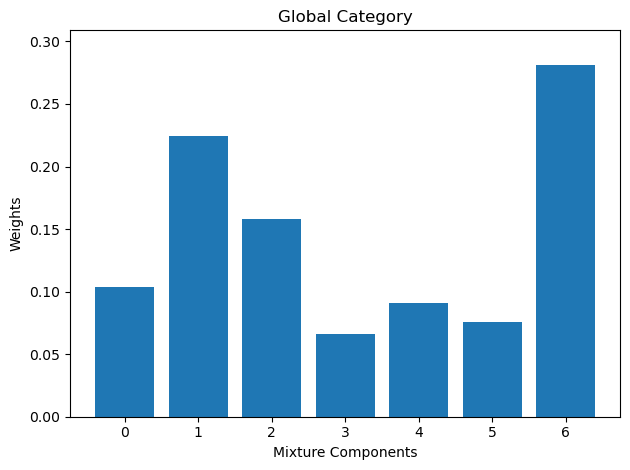

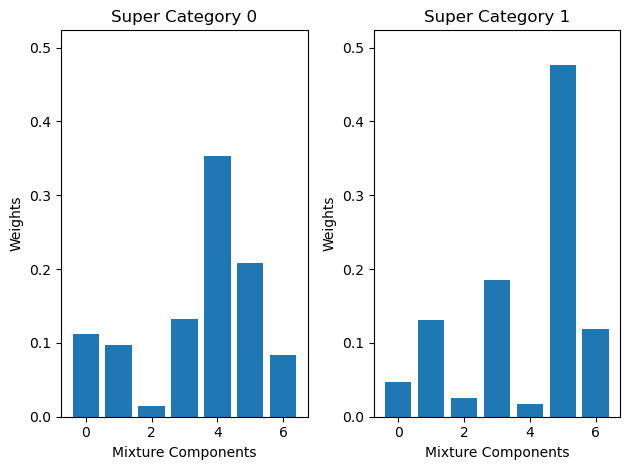

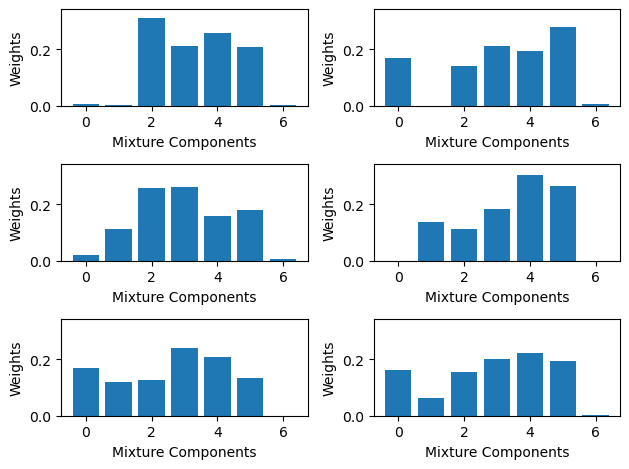


🔁 Round 38 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 323066.61
📌 Optimizing model...
  [Model] Step 0, loss = 319392.09
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


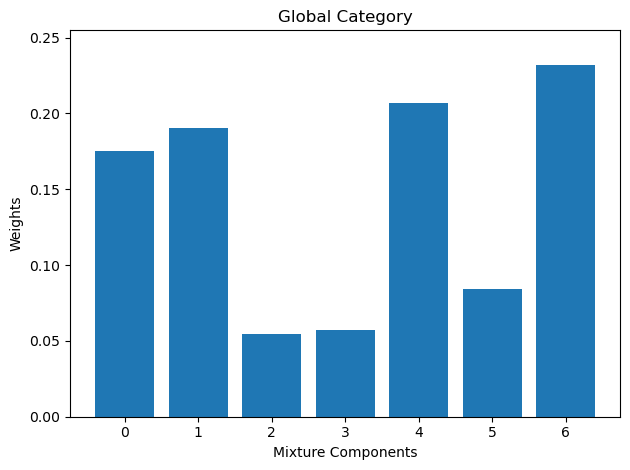

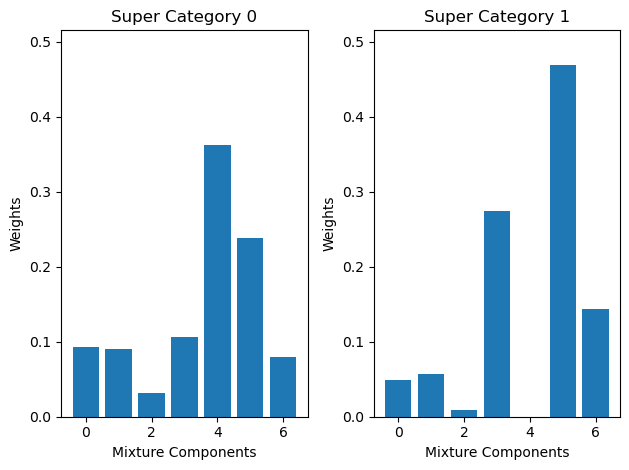

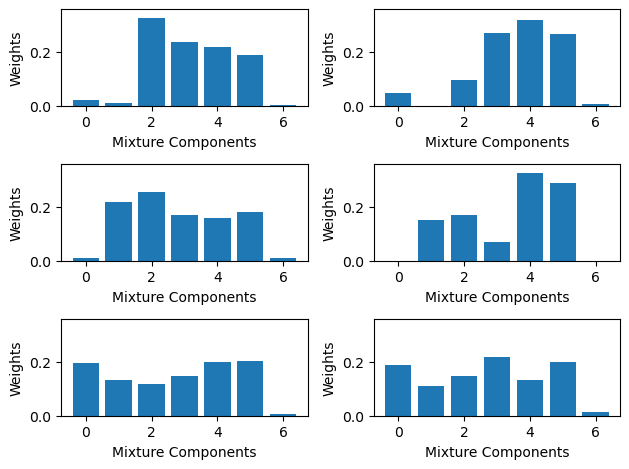


🔁 Round 39 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 320585.23
📌 Optimizing model...
  [Model] Step 0, loss = 310534.03
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


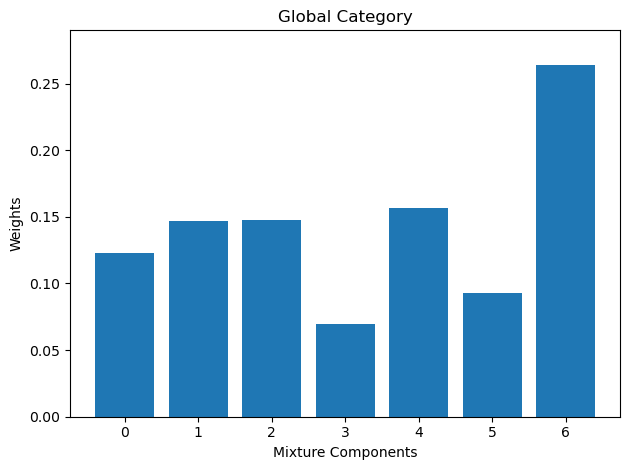

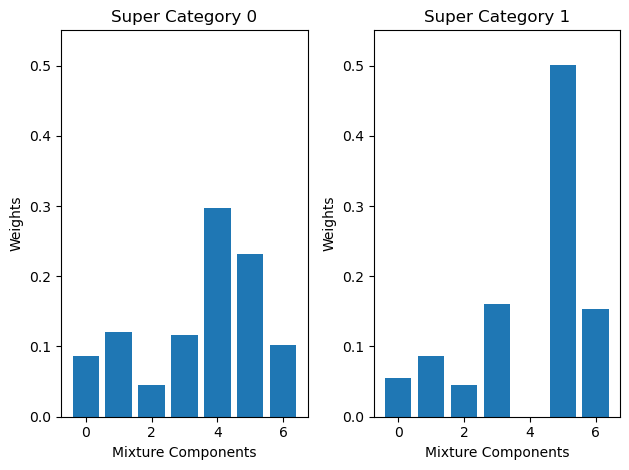

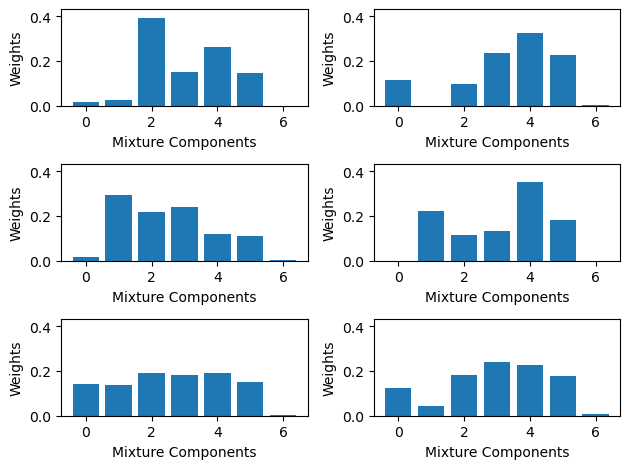


🔁 Round 40 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 312218.44
📌 Optimizing model...
  [Model] Step 0, loss = 315375.27
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


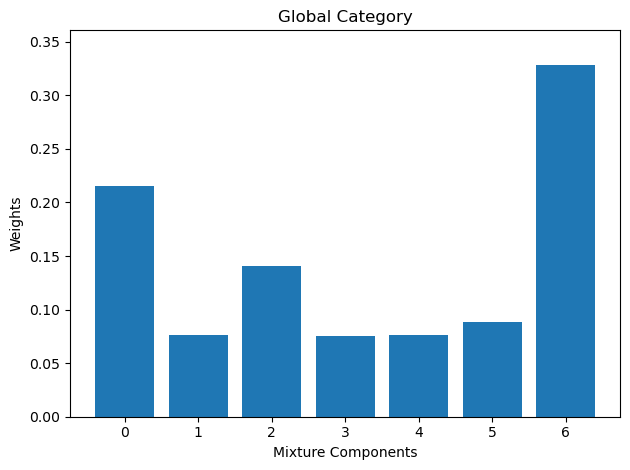

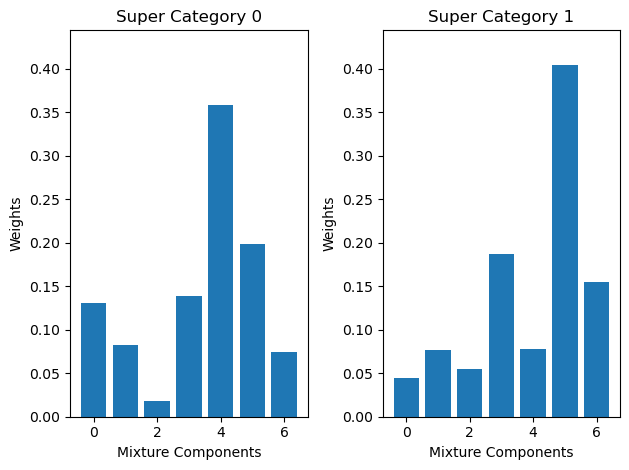

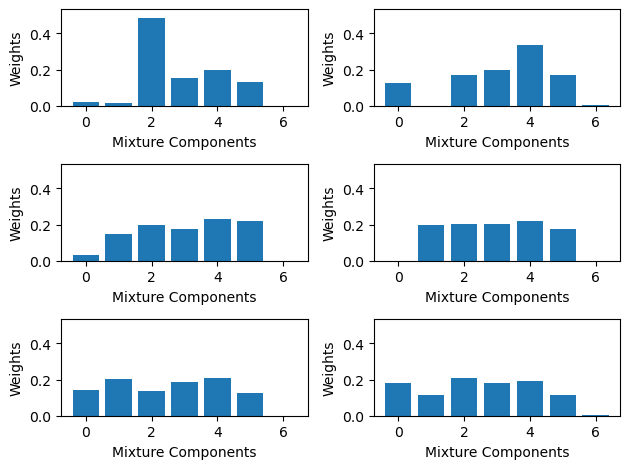


🔁 Round 41 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 313853.33
📌 Optimizing model...
  [Model] Step 0, loss = 314770.39
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


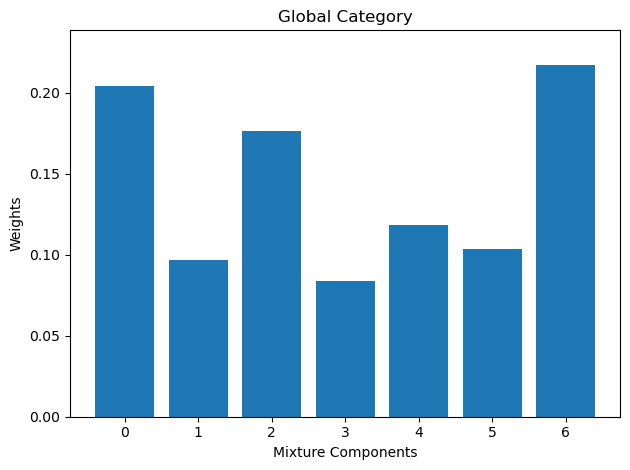

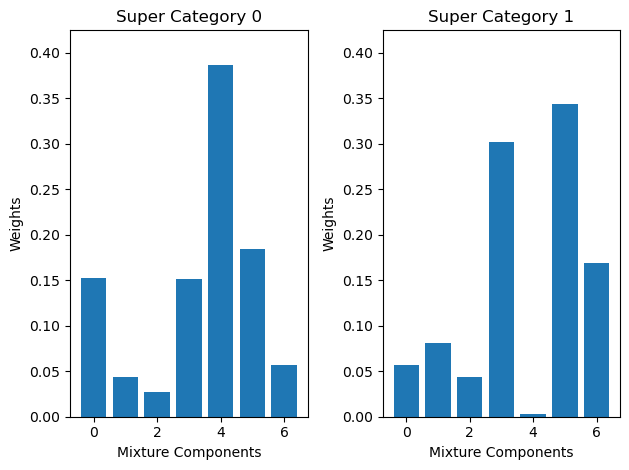

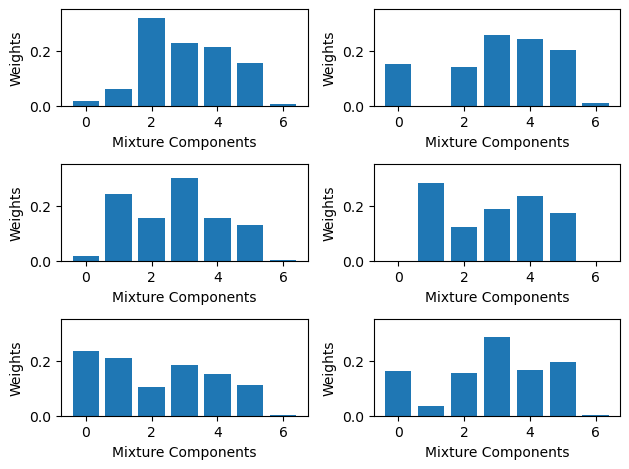


🔁 Round 42 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 315877.81
📌 Optimizing model...
  [Model] Step 0, loss = 317955.40
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


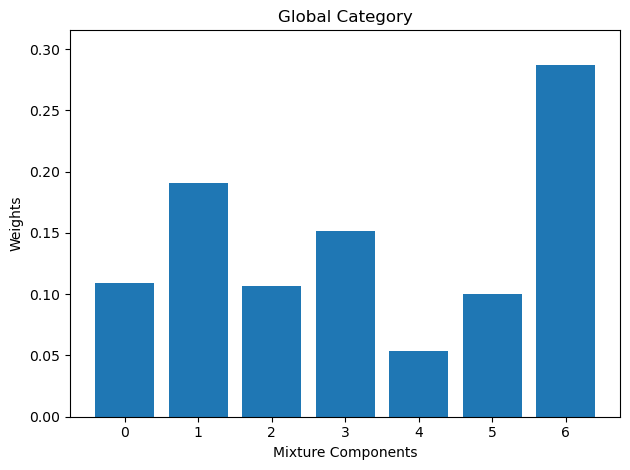

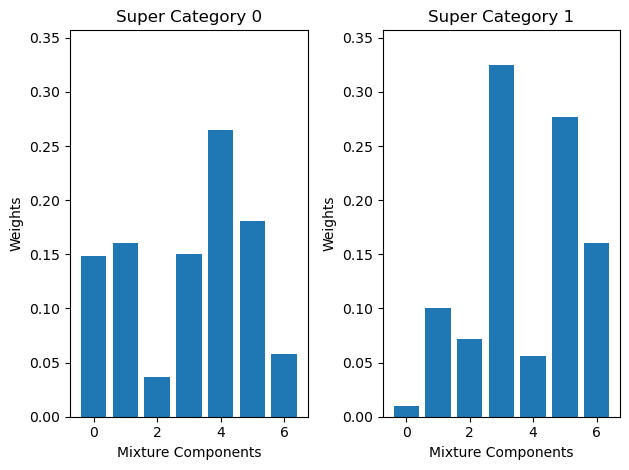

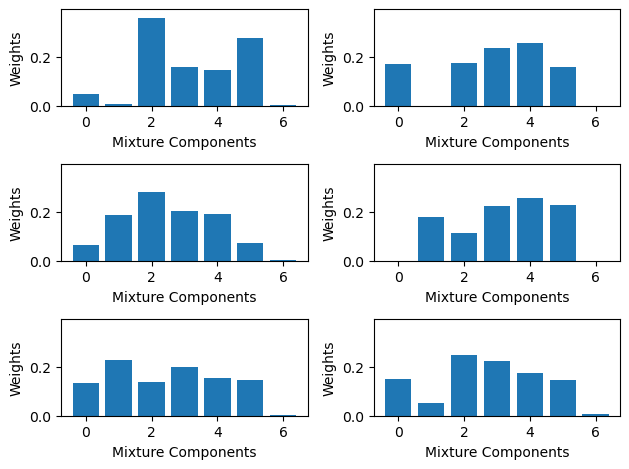


🔁 Round 43 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 311715.95
📌 Optimizing model...
  [Model] Step 0, loss = 310798.19
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


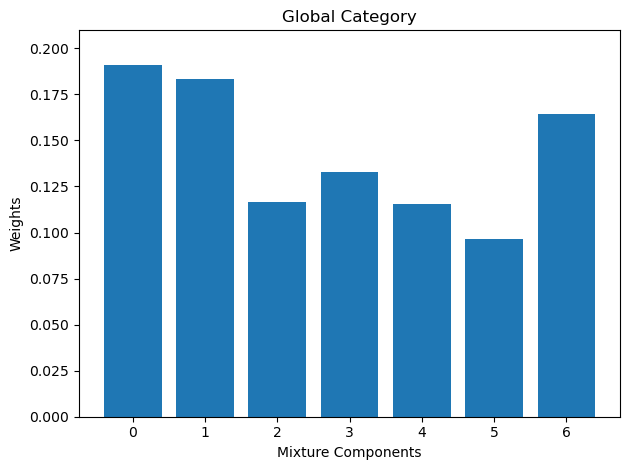

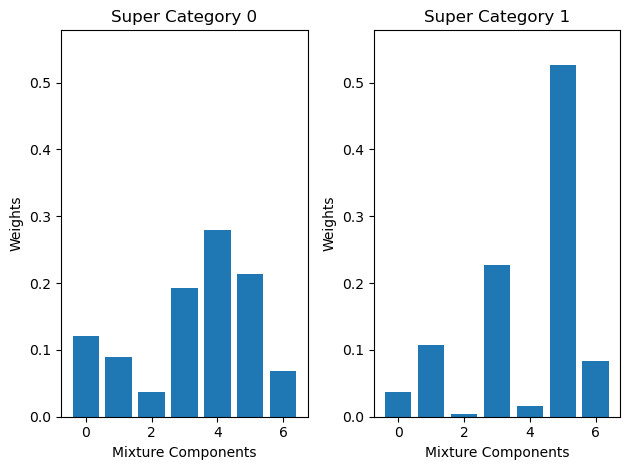

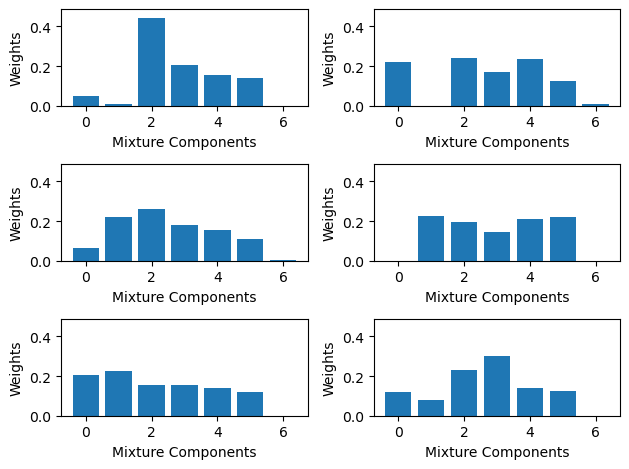


🔁 Round 44 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 313483.67
📌 Optimizing model...
  [Model] Step 0, loss = 314481.95
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


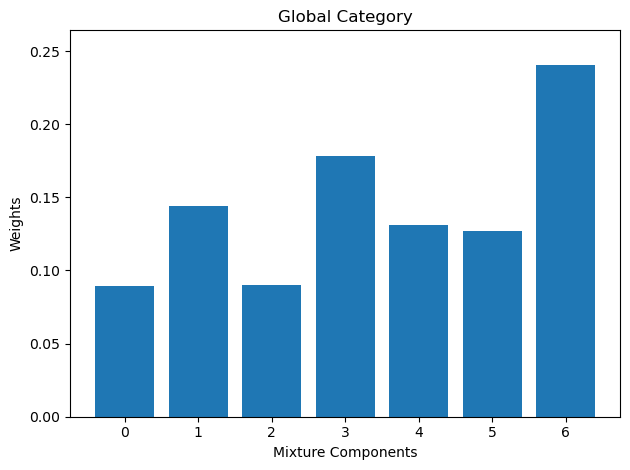

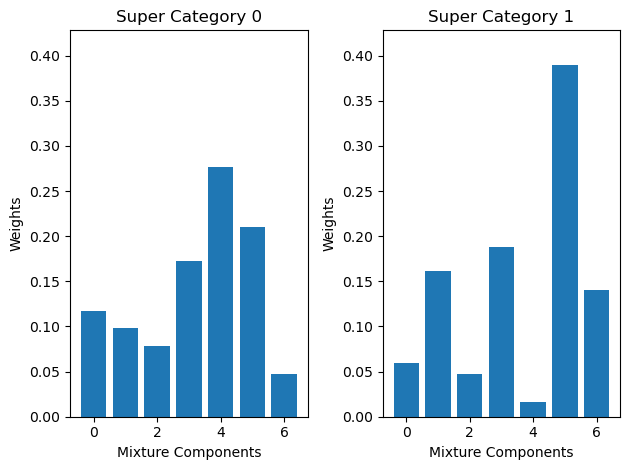

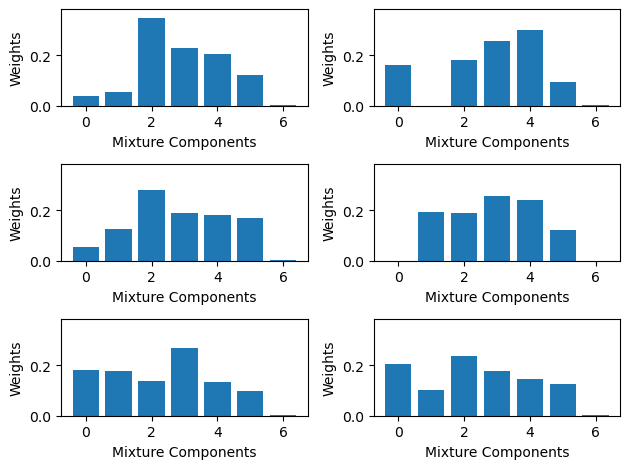


🔁 Round 45 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 315114.10
📌 Optimizing model...
  [Model] Step 0, loss = 312616.68
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


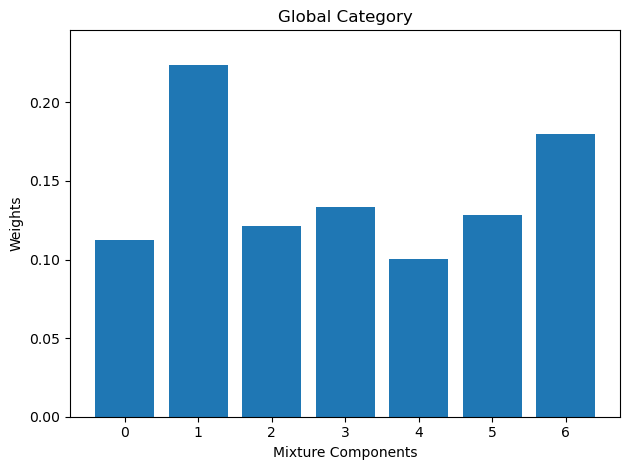

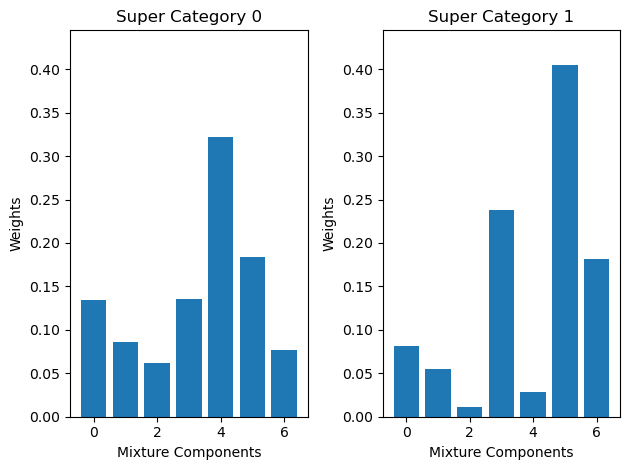

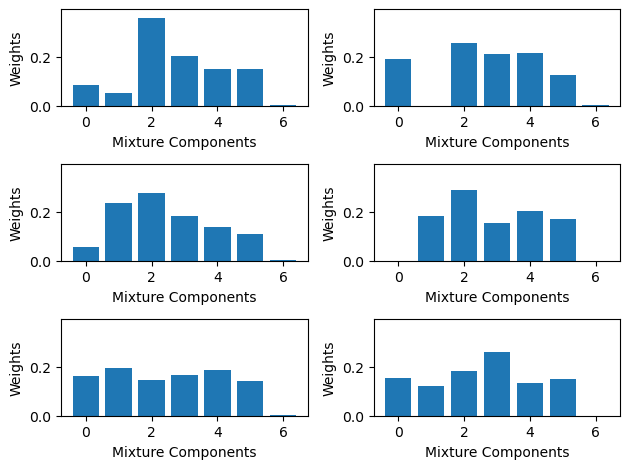


🔁 Round 46 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 311812.58
📌 Optimizing model...
  [Model] Step 0, loss = 308939.23
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


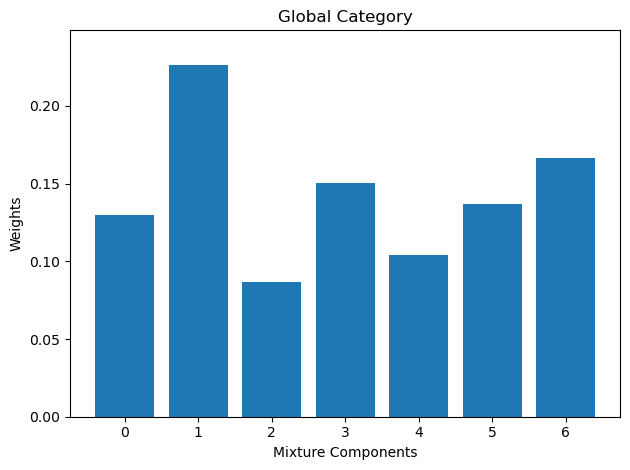

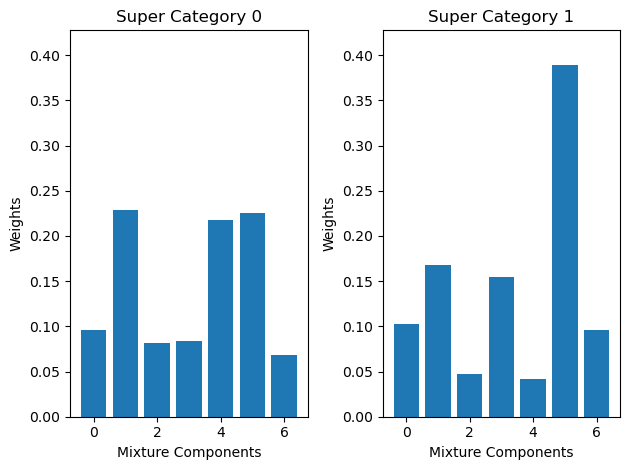

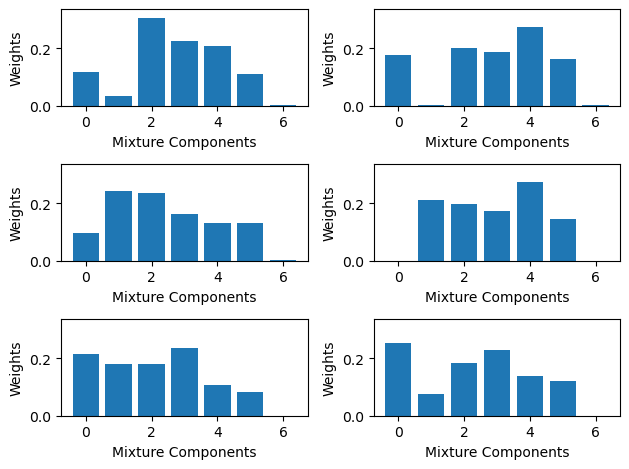


🔁 Round 47 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 312589.67
📌 Optimizing model...
  [Model] Step 0, loss = 311728.71
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


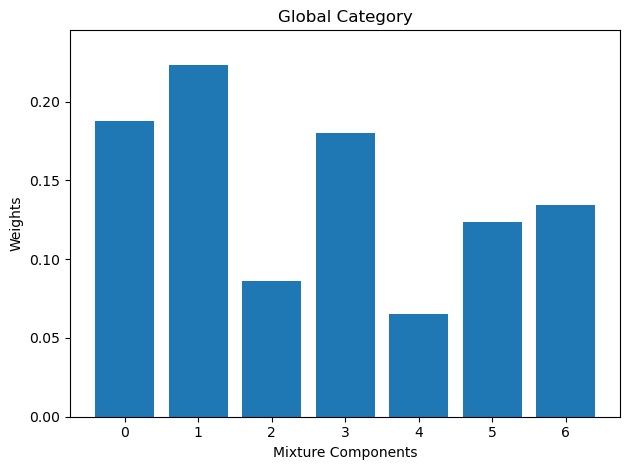

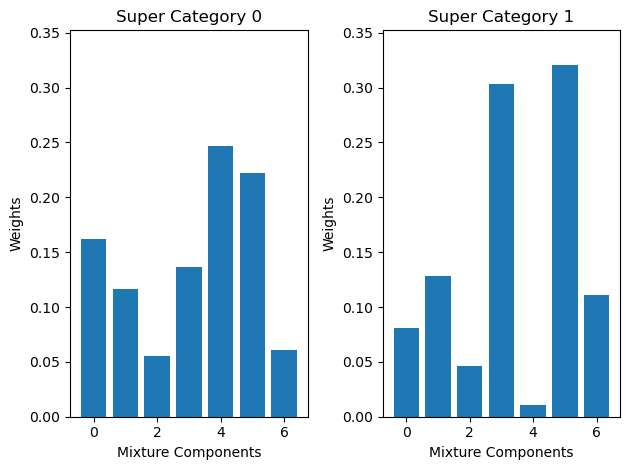

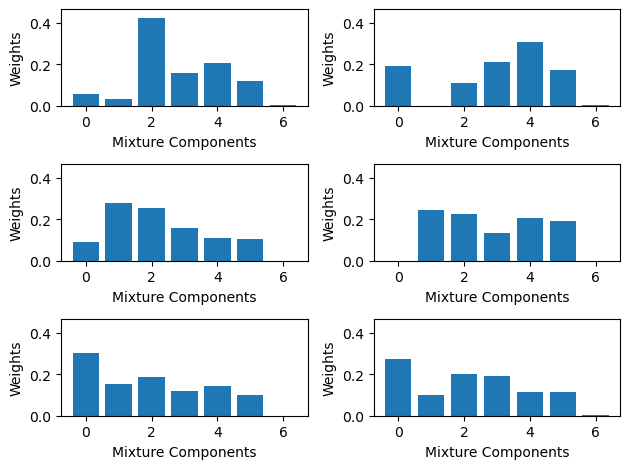


🔁 Round 48 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 309352.68
📌 Optimizing model...
  [Model] Step 0, loss = 312762.03
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


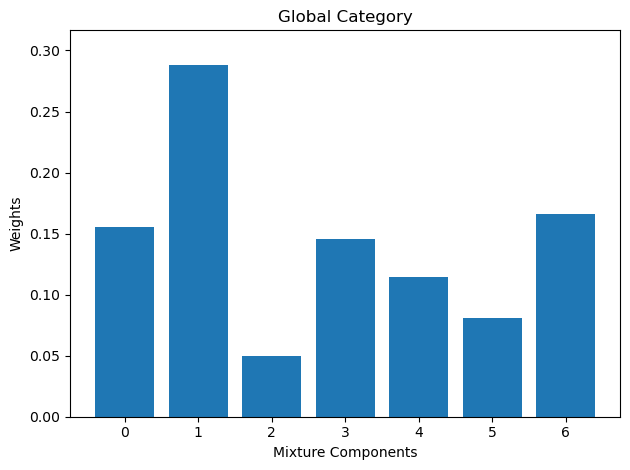

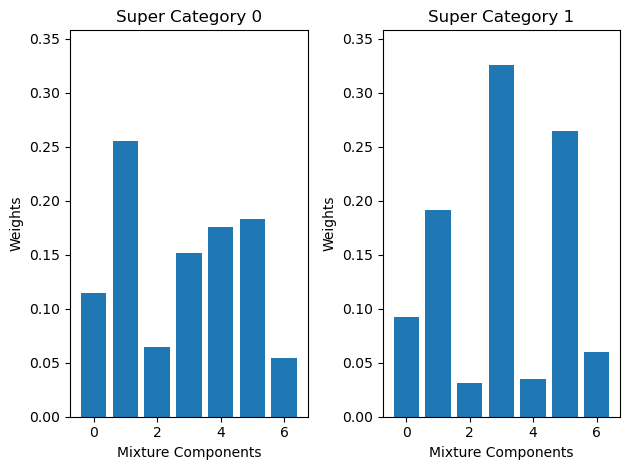

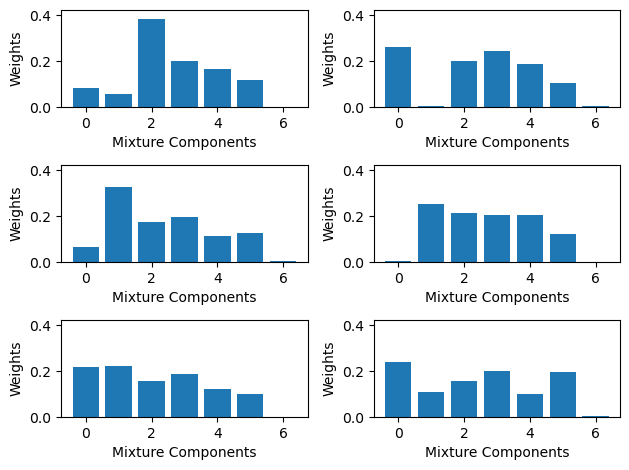


🔁 Round 49 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 312847.43
📌 Optimizing model...
  [Model] Step 0, loss = 309576.79
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


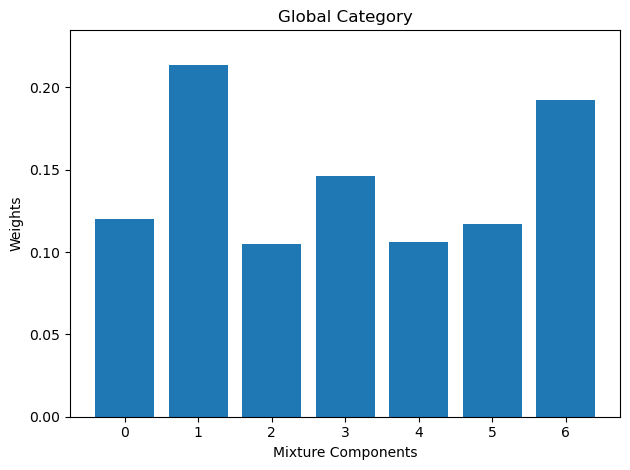

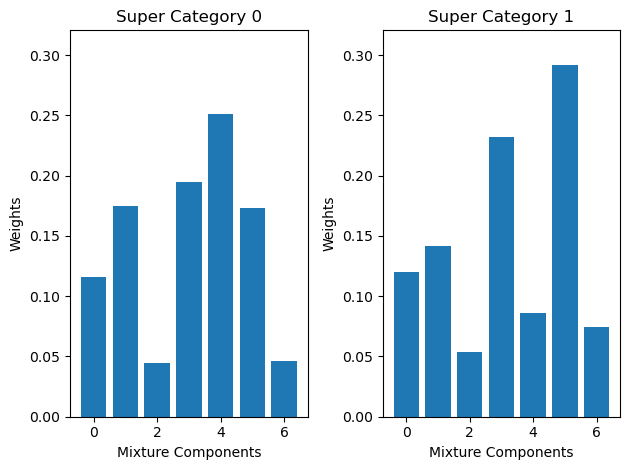

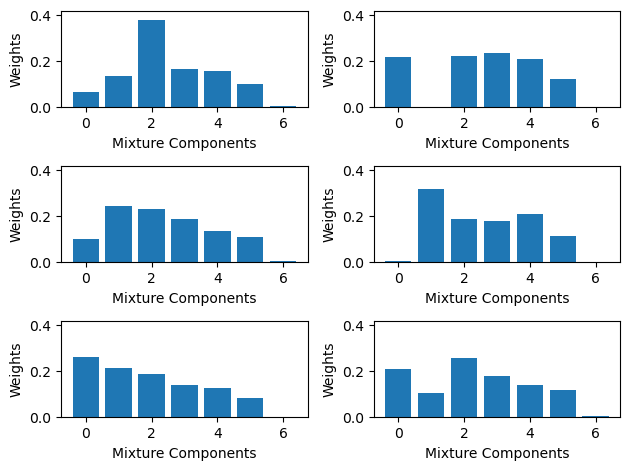


🔁 Round 50 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 311035.42
📌 Optimizing model...
  [Model] Step 0, loss = 307365.35
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


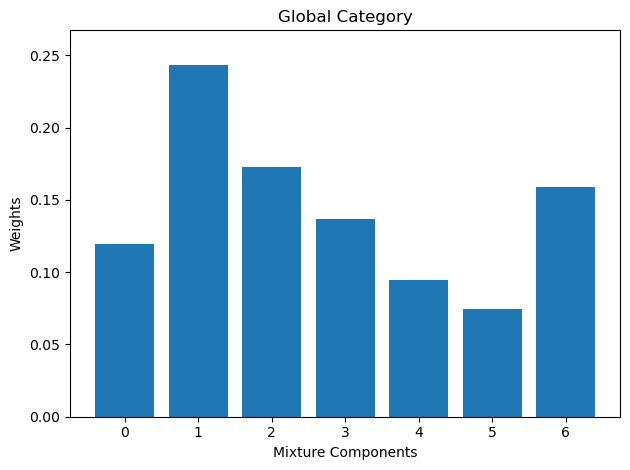

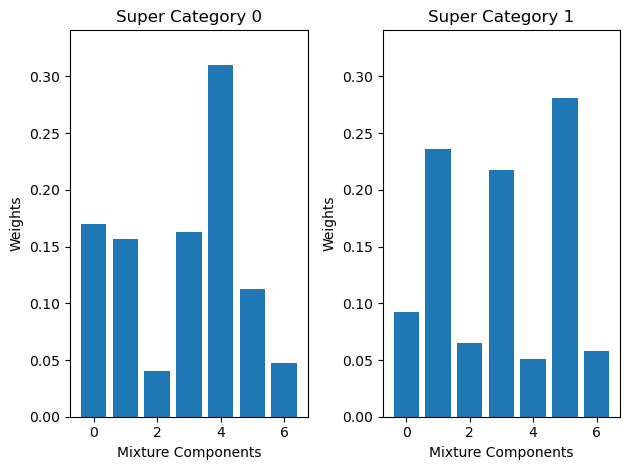

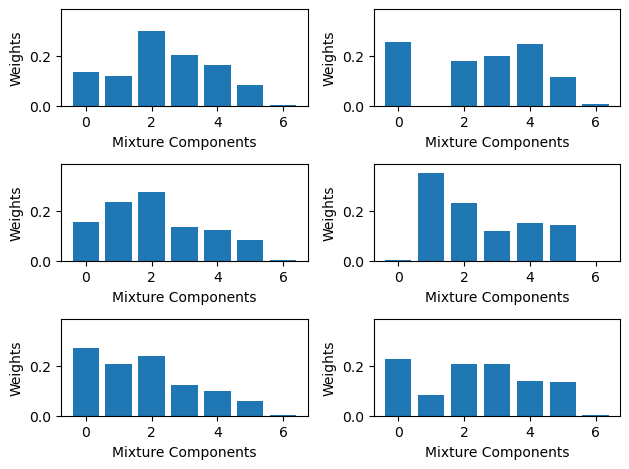


🔁 Round 51 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 311296.57
📌 Optimizing model...
  [Model] Step 0, loss = 314110.41
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


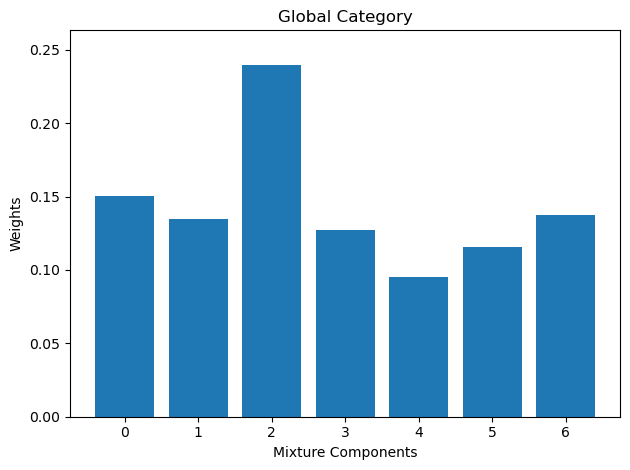

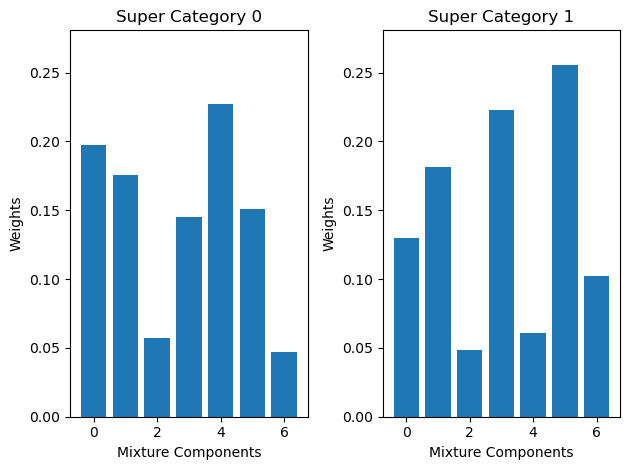

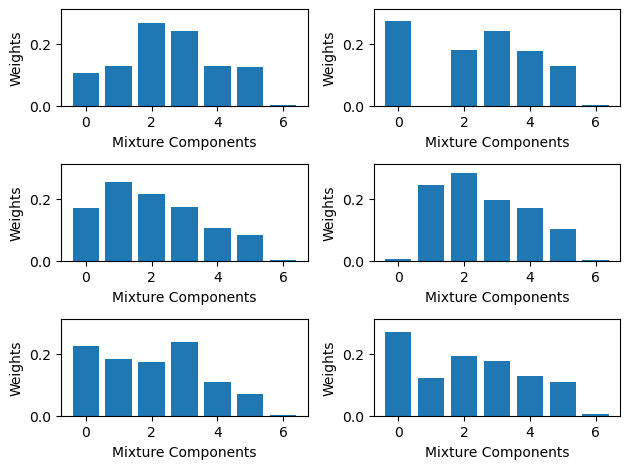


🔁 Round 52 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 314018.37
📌 Optimizing model...
  [Model] Step 0, loss = 311452.20
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


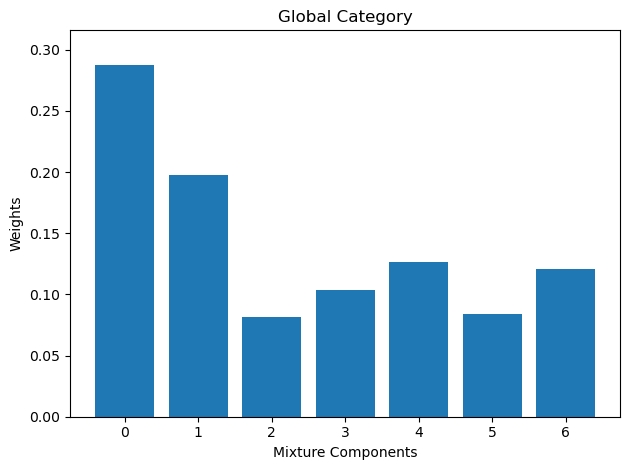

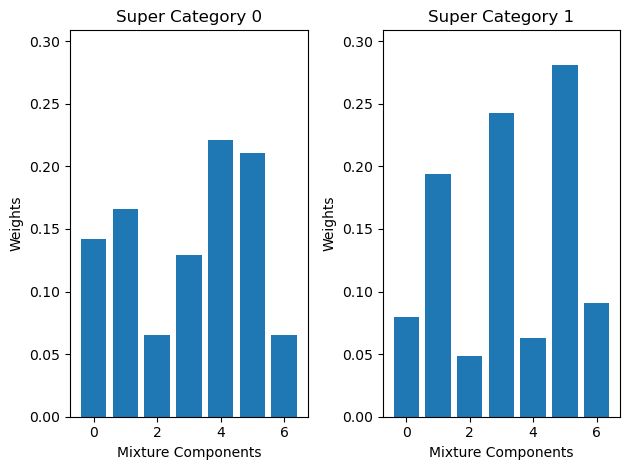

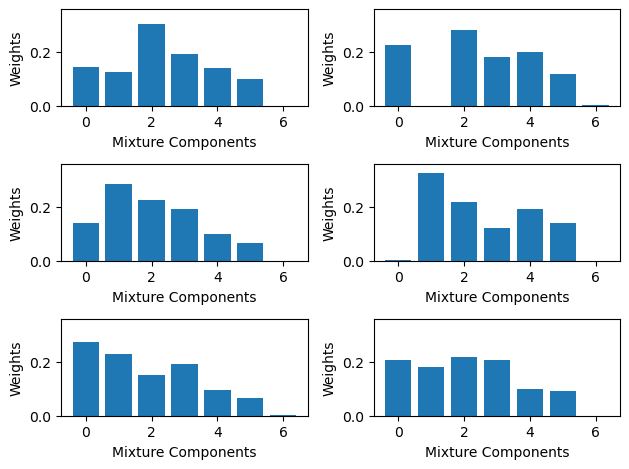


🔁 Round 53 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 310509.93
📌 Optimizing model...
  [Model] Step 0, loss = 311945.66
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


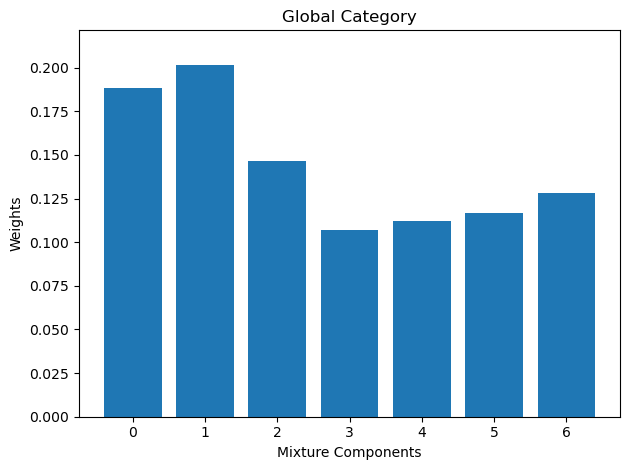

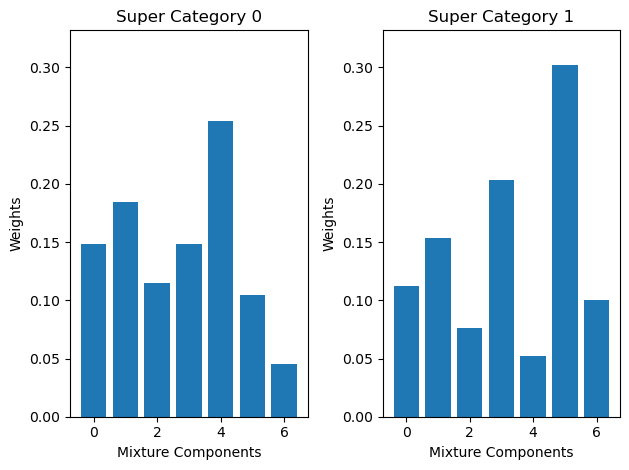

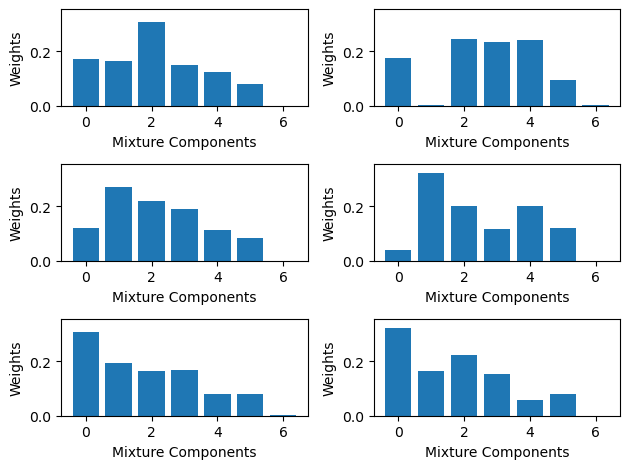


🔁 Round 54 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 309231.00
📌 Optimizing model...
  [Model] Step 0, loss = 309531.08
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


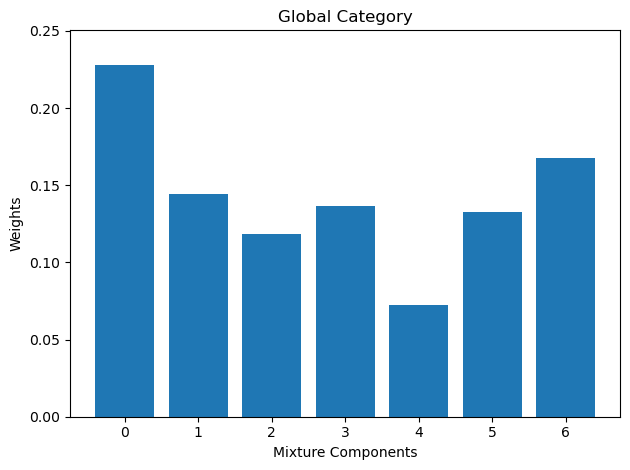

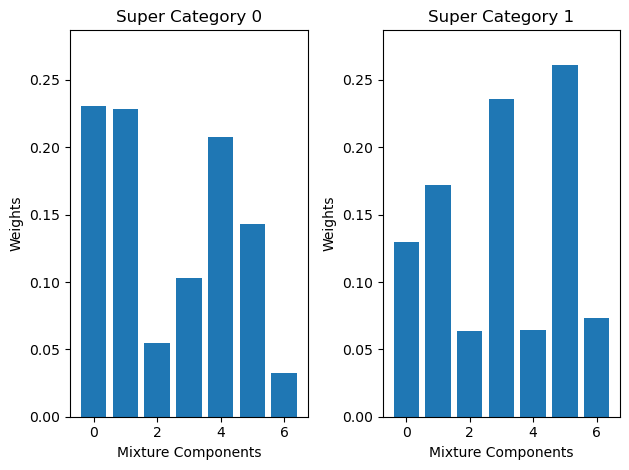

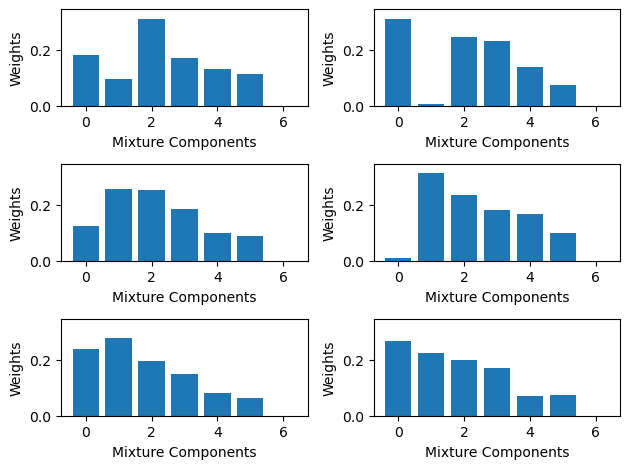


🔁 Round 55 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 308286.81
📌 Optimizing model...
  [Model] Step 0, loss = 312001.38
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


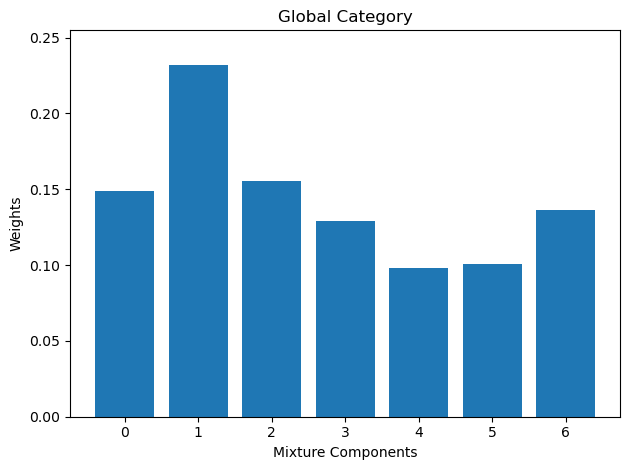

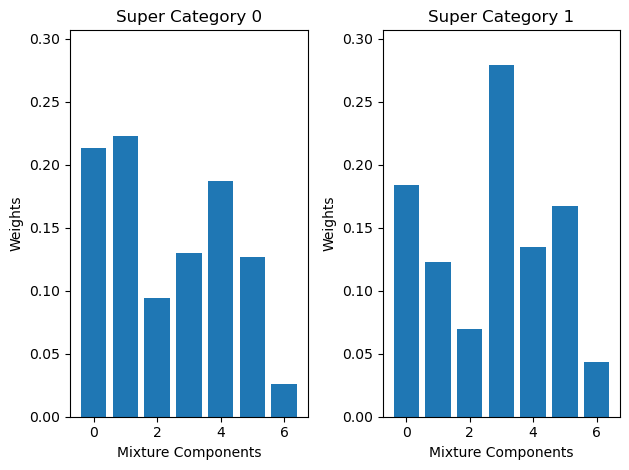

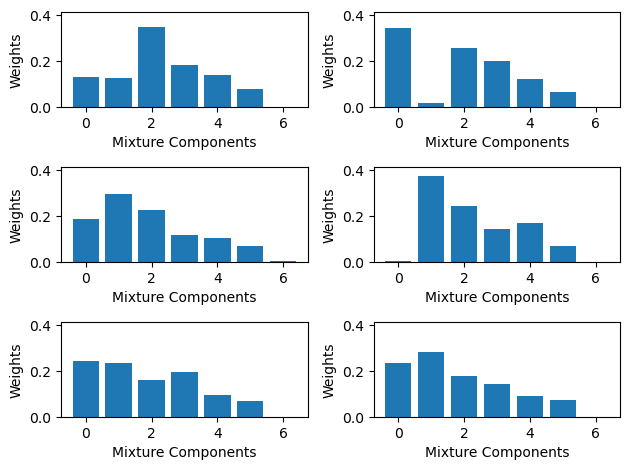


🔁 Round 56 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 309500.73
📌 Optimizing model...
  [Model] Step 0, loss = 311234.99
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


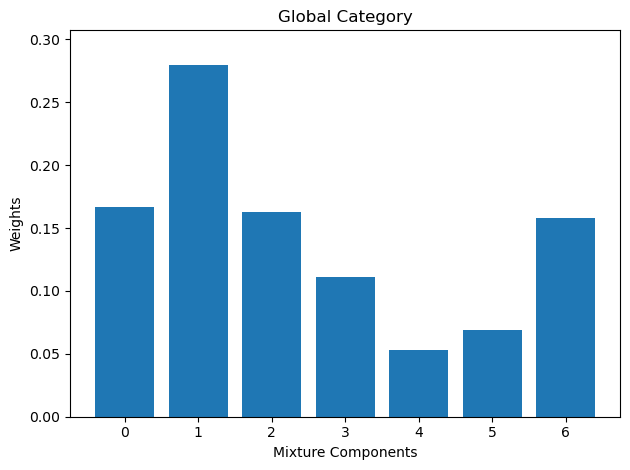

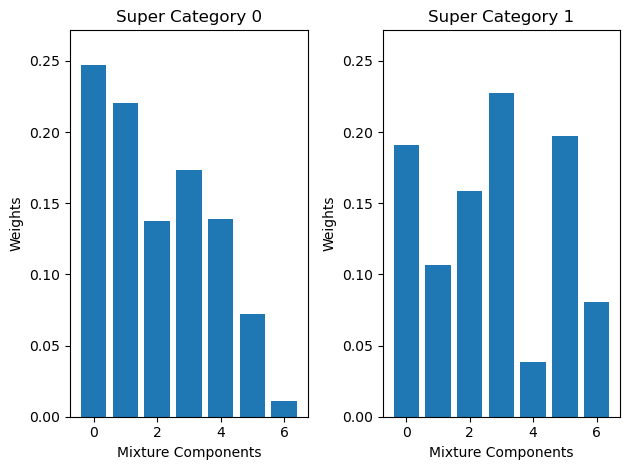

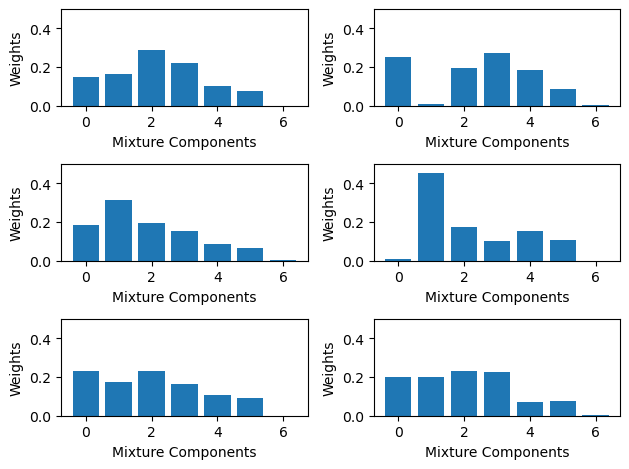


🔁 Round 57 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 313147.81
📌 Optimizing model...
  [Model] Step 0, loss = 310533.43
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


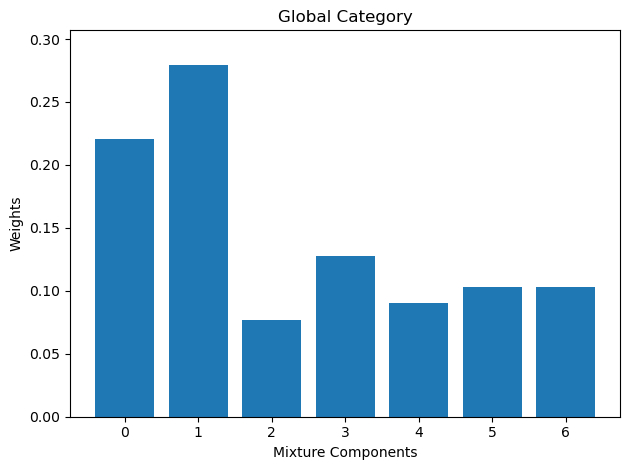

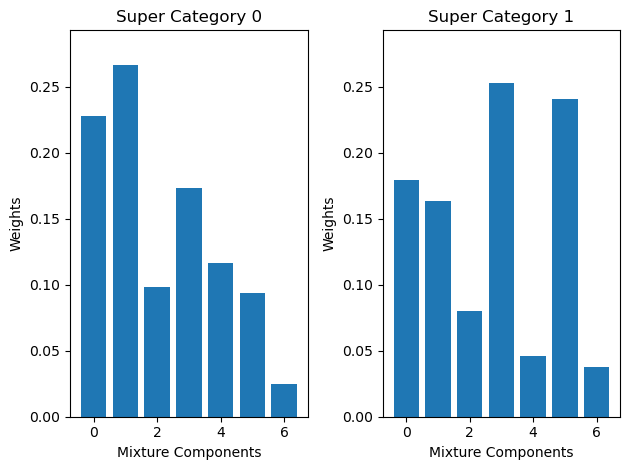

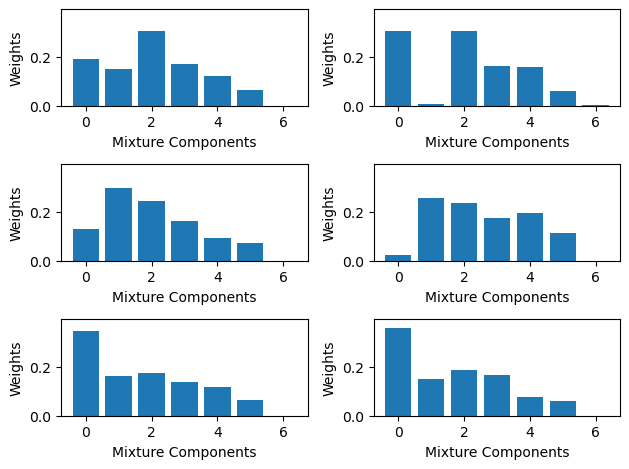


🔁 Round 58 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 311491.04
📌 Optimizing model...
  [Model] Step 0, loss = 308154.03
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


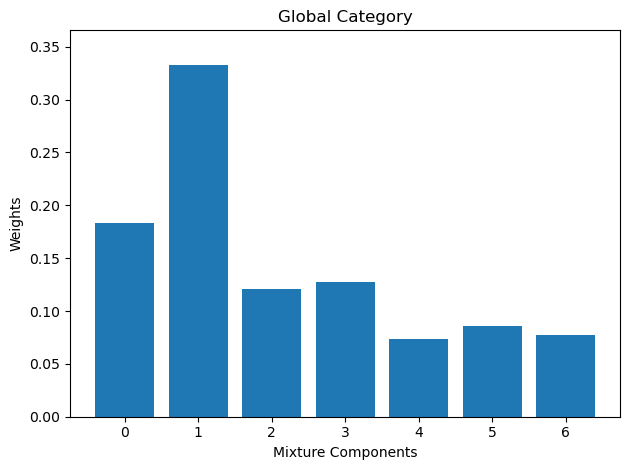

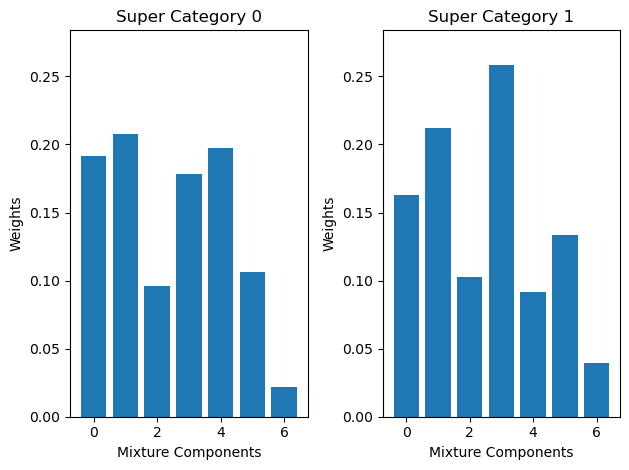

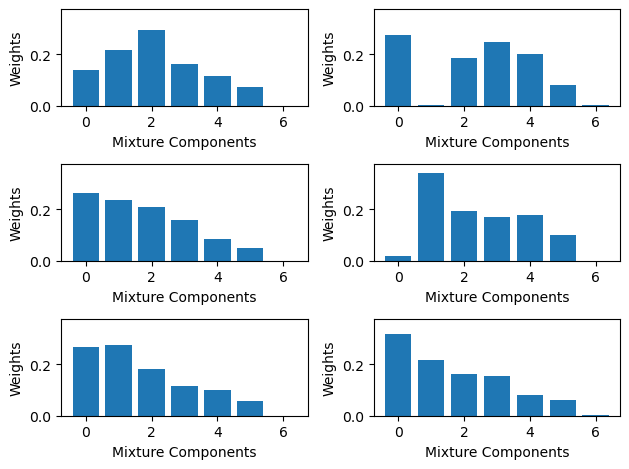


🔁 Round 59 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 310831.81
📌 Optimizing model...
  [Model] Step 0, loss = 309632.67
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


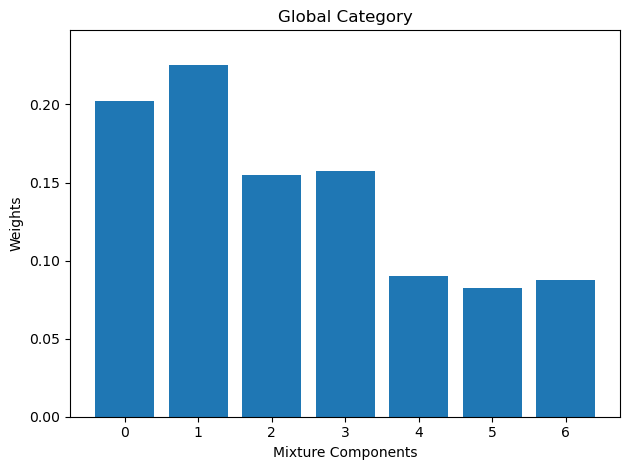

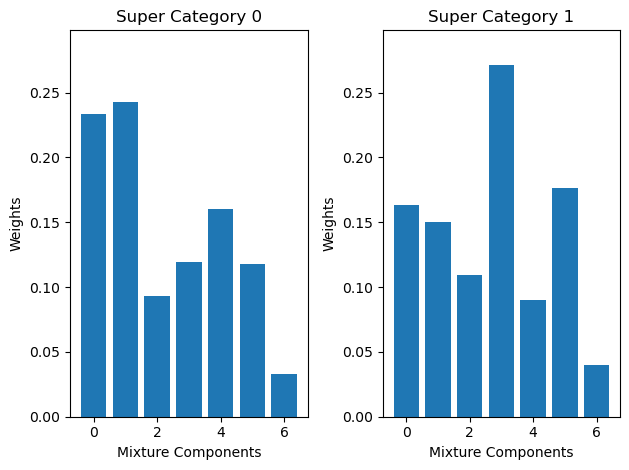

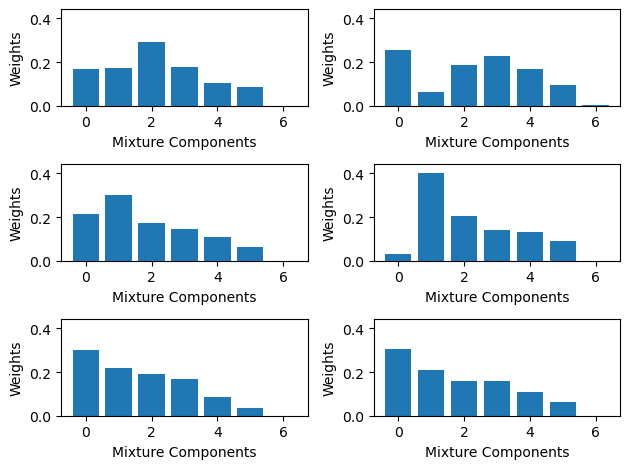


🔁 Round 60 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 308227.57
📌 Optimizing model...
  [Model] Step 0, loss = 310160.92
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


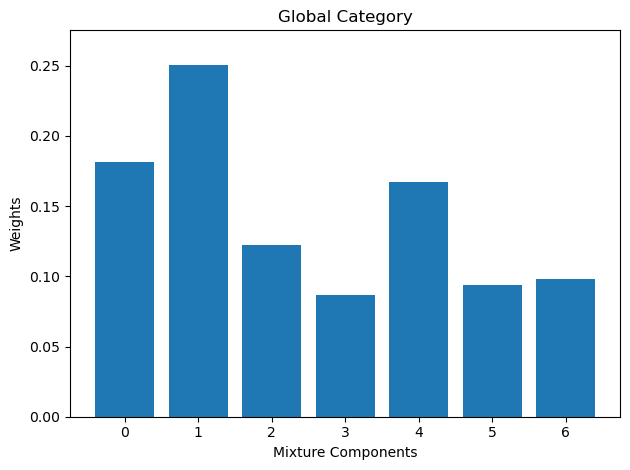

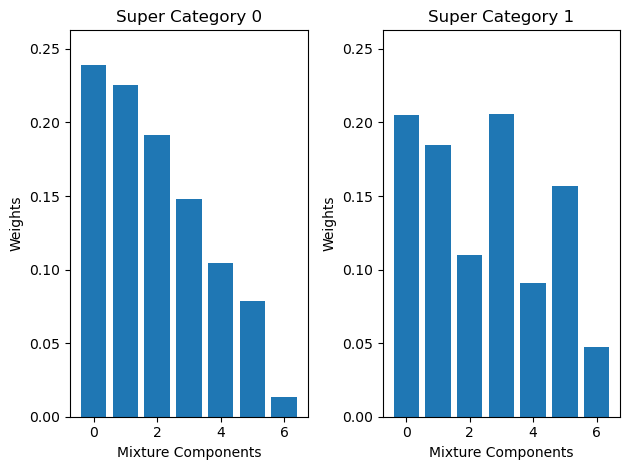

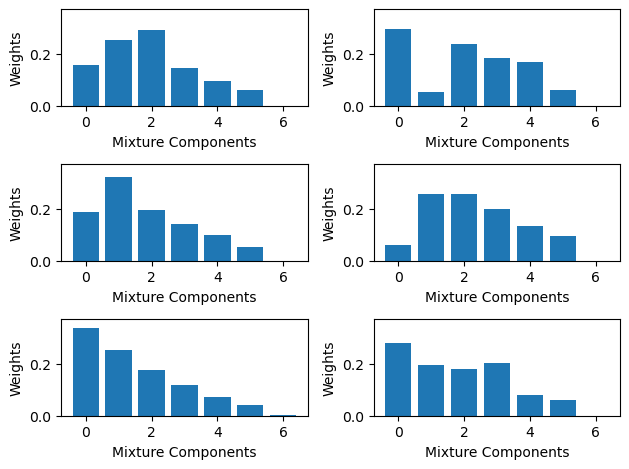


🔁 Round 61 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 310075.46
📌 Optimizing model...
  [Model] Step 0, loss = 310379.05
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


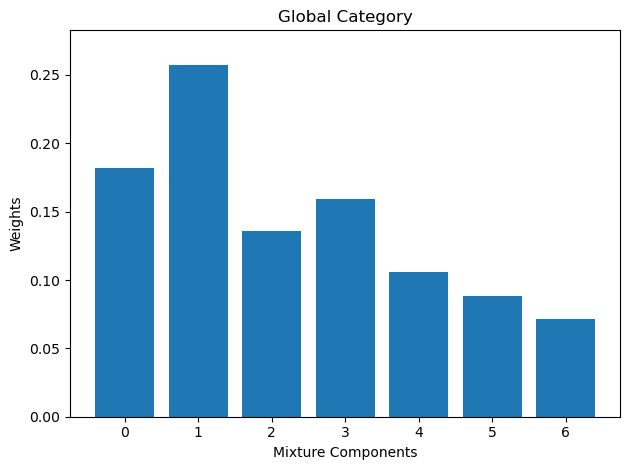

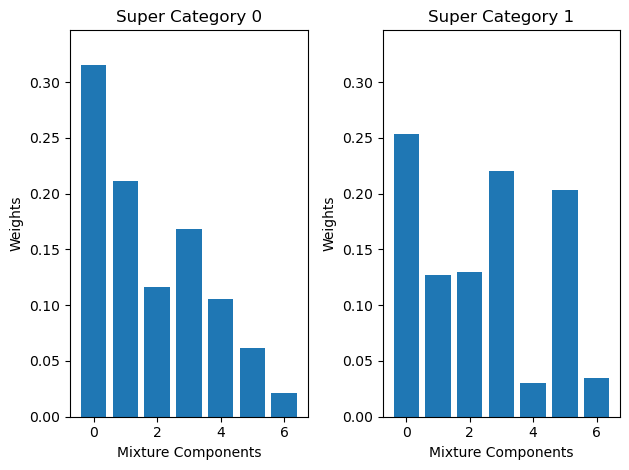

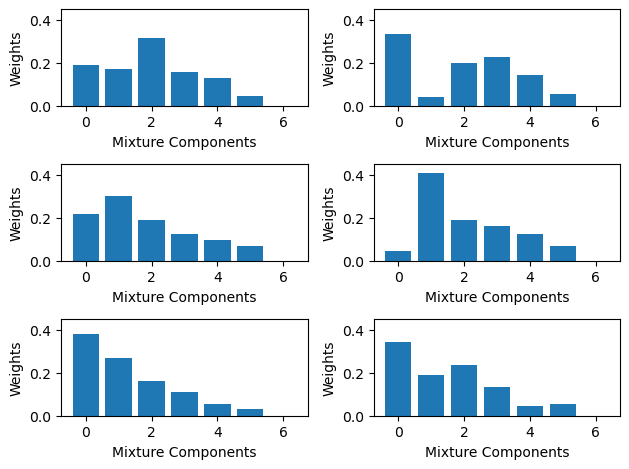


🔁 Round 62 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 307455.59
📌 Optimizing model...
  [Model] Step 0, loss = 309099.49
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


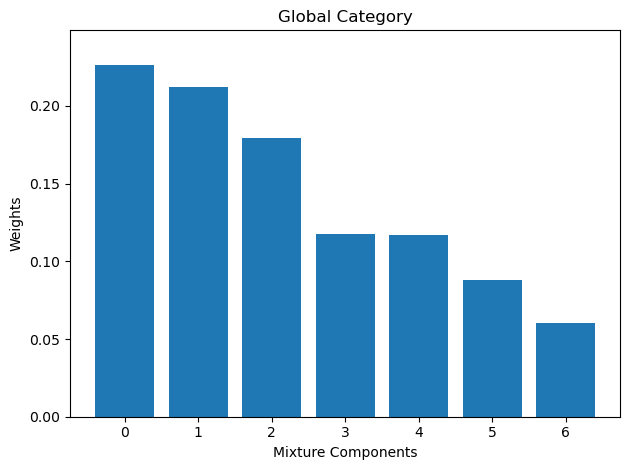

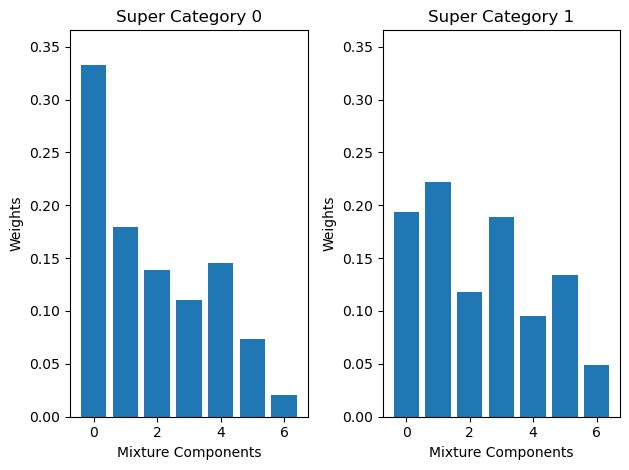

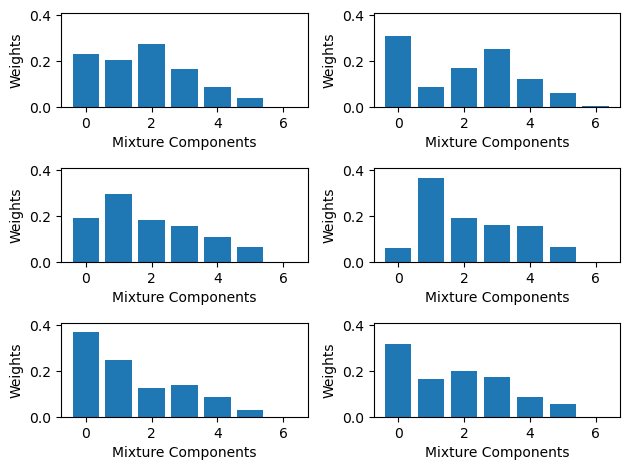


🔁 Round 63 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 308361.66
📌 Optimizing model...
  [Model] Step 0, loss = 308363.86
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


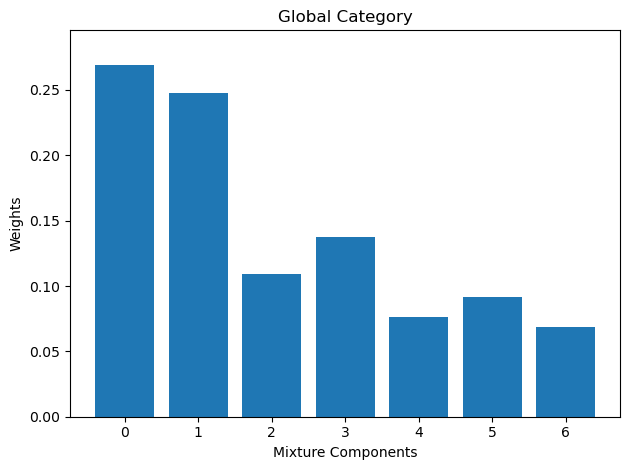

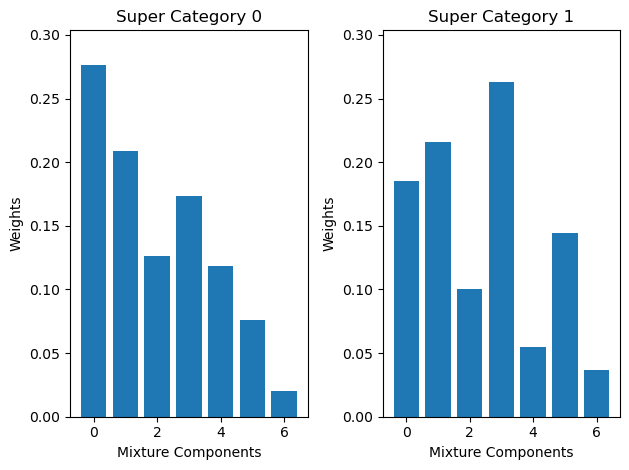

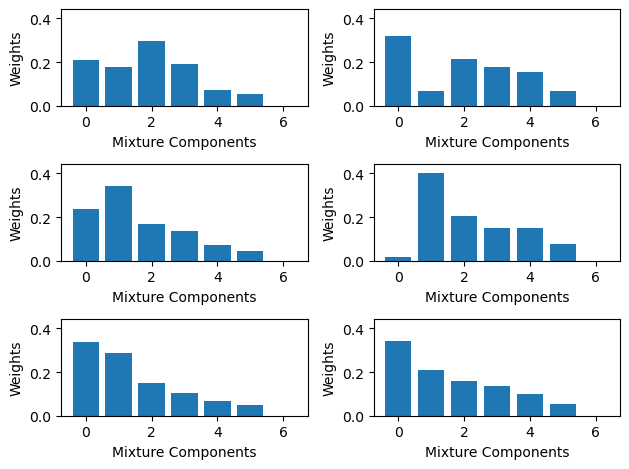


🔁 Round 64 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 309320.13
📌 Optimizing model...
  [Model] Step 0, loss = 309033.29
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


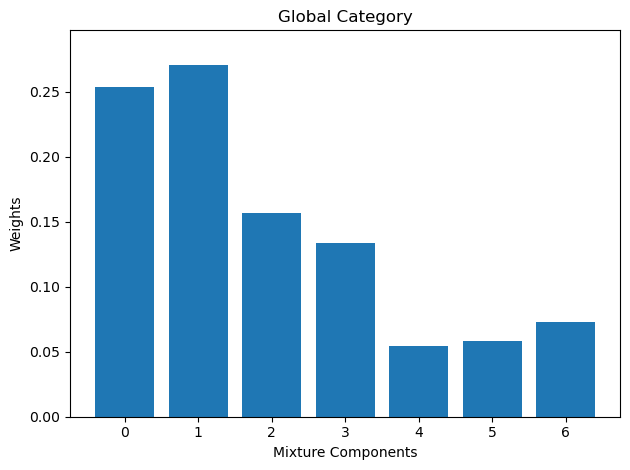

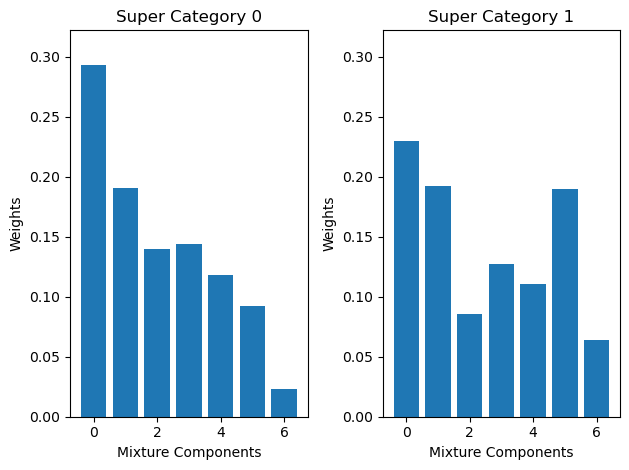

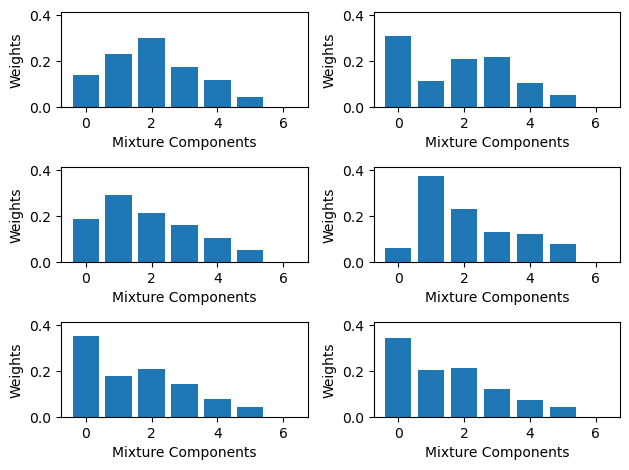


🔁 Round 65 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 309648.76
📌 Optimizing model...
  [Model] Step 0, loss = 310131.39
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


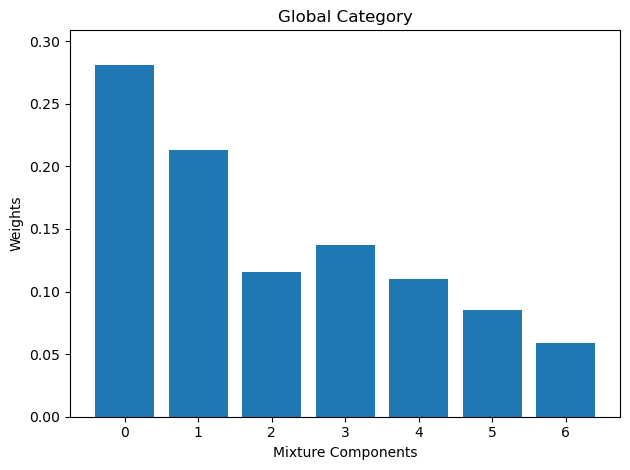

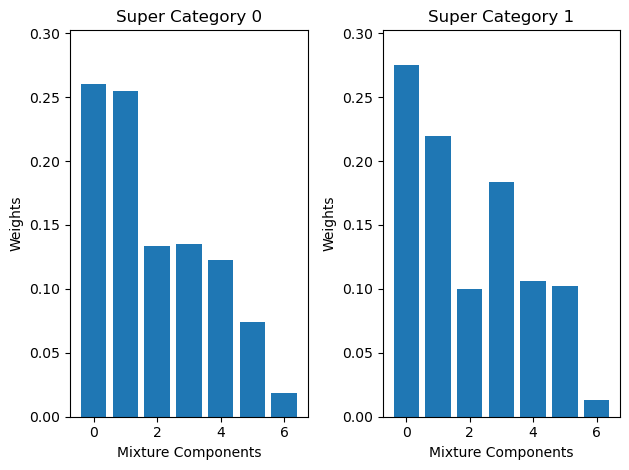

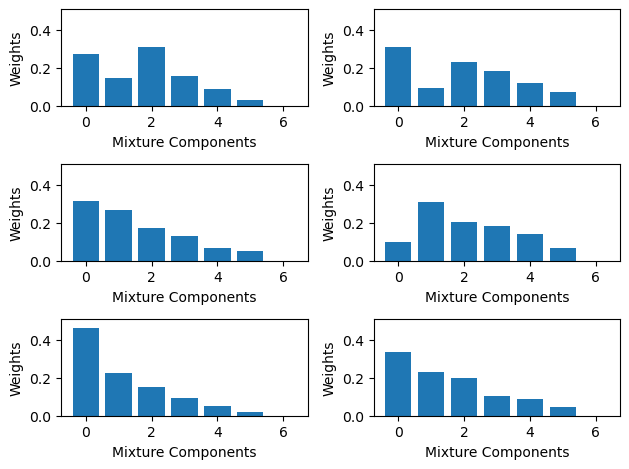


🔁 Round 66 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 309497.19
📌 Optimizing model...
  [Model] Step 0, loss = 307760.87
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


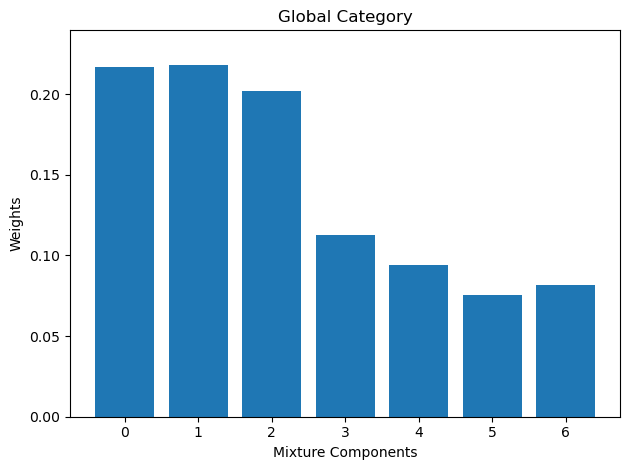

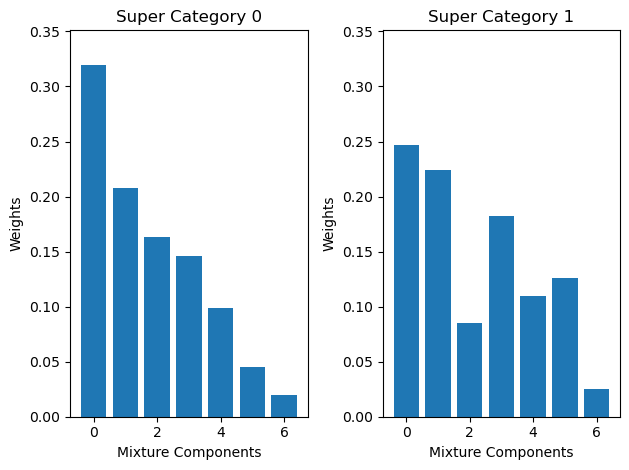

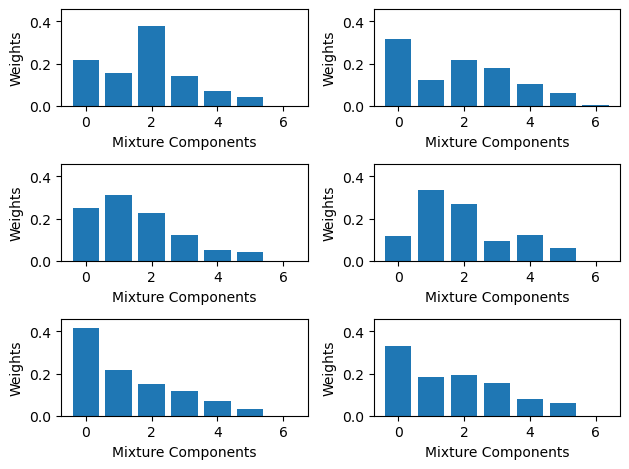


🔁 Round 67 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 307543.56
📌 Optimizing model...
  [Model] Step 0, loss = 307467.11
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


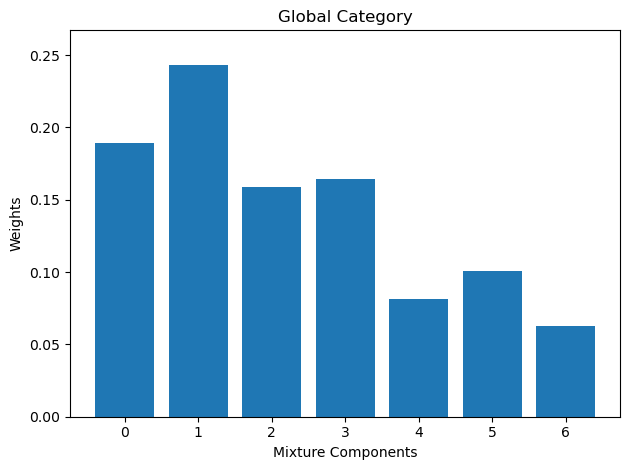

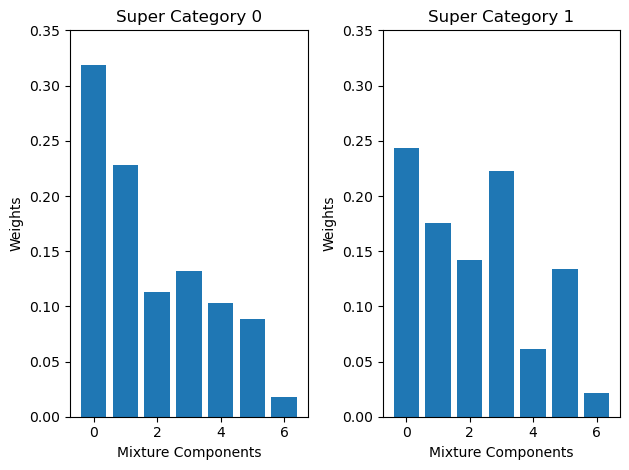

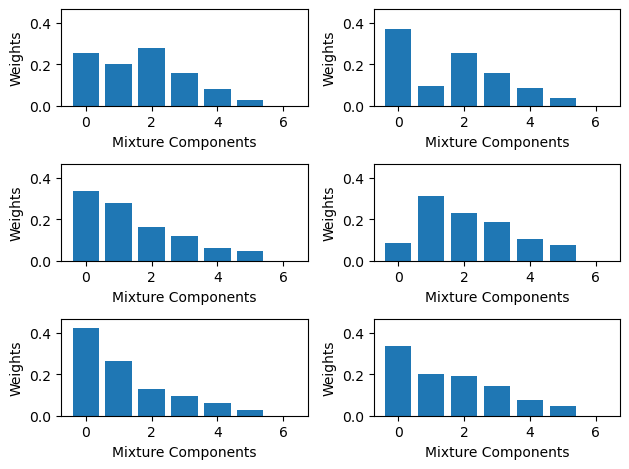


🔁 Round 68 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 309390.35
📌 Optimizing model...
  [Model] Step 0, loss = 308152.46
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


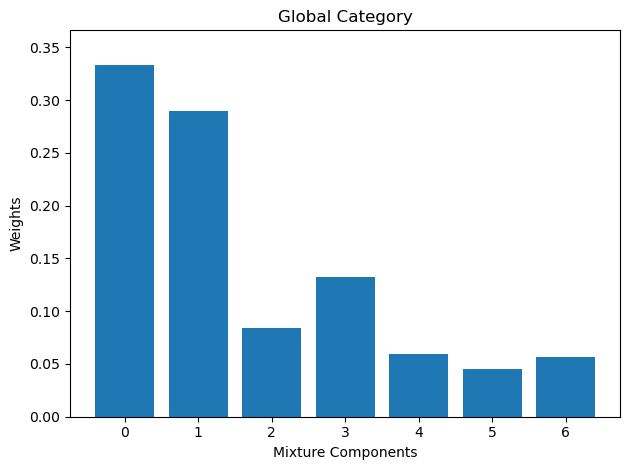

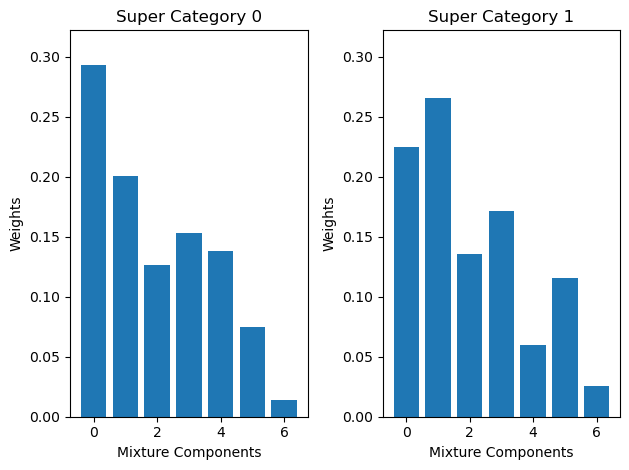

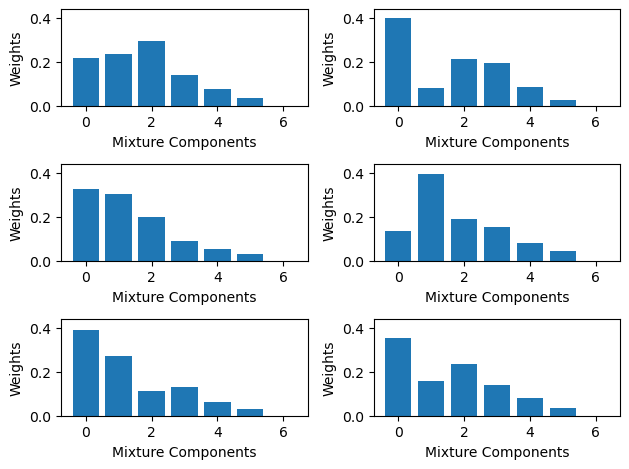


🔁 Round 69 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 307251.30
📌 Optimizing model...
  [Model] Step 0, loss = 307845.29
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


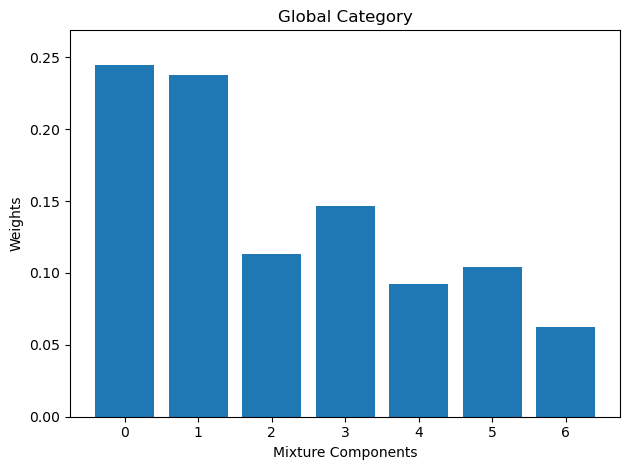

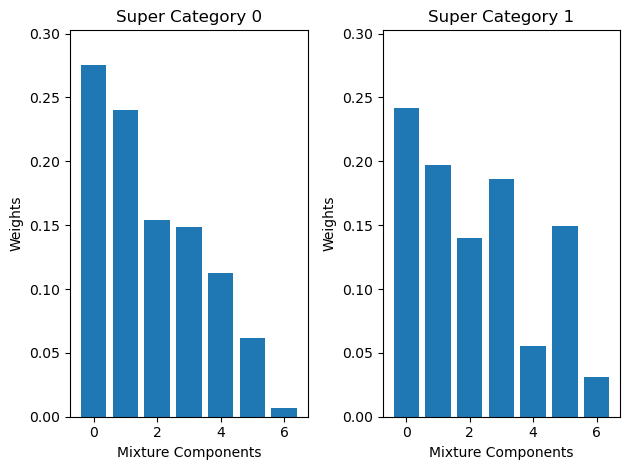

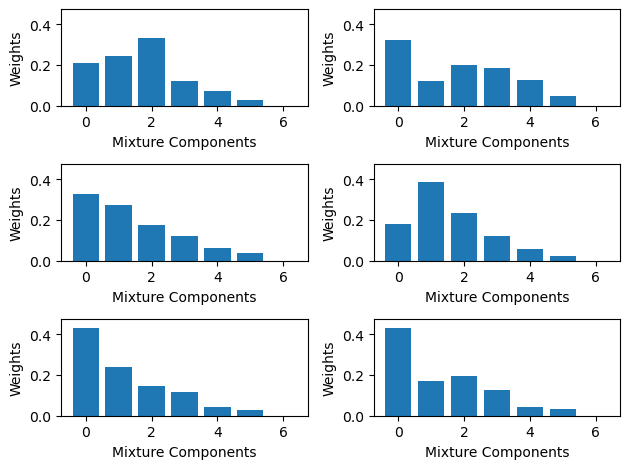


🔁 Round 70 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 309632.38
📌 Optimizing model...
  [Model] Step 0, loss = 308184.26
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


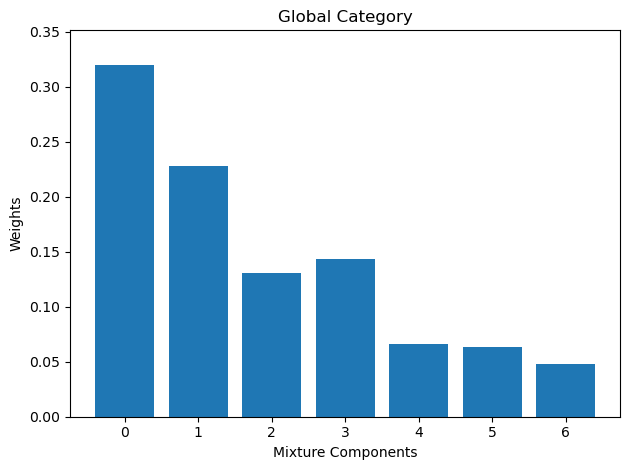

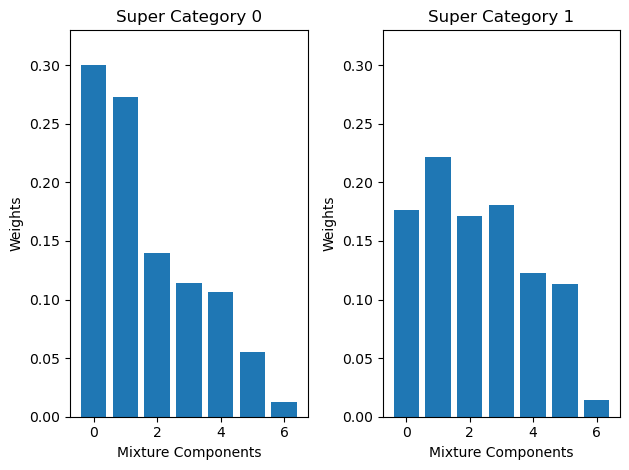

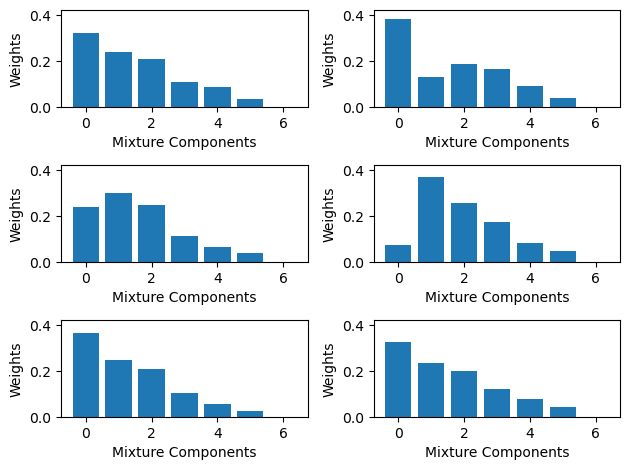


🔁 Round 71 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 310043.97
📌 Optimizing model...
  [Model] Step 0, loss = 310252.04
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


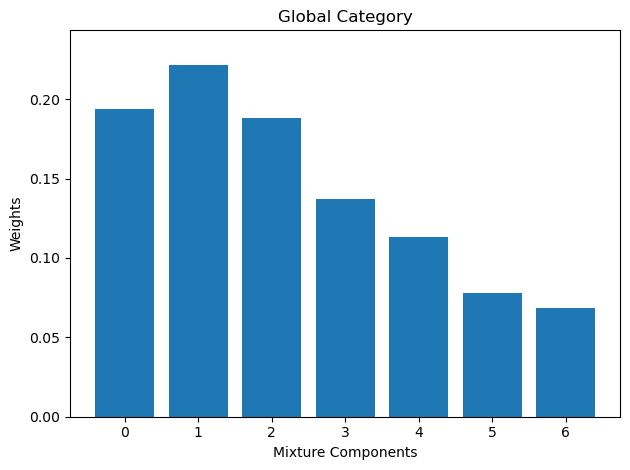

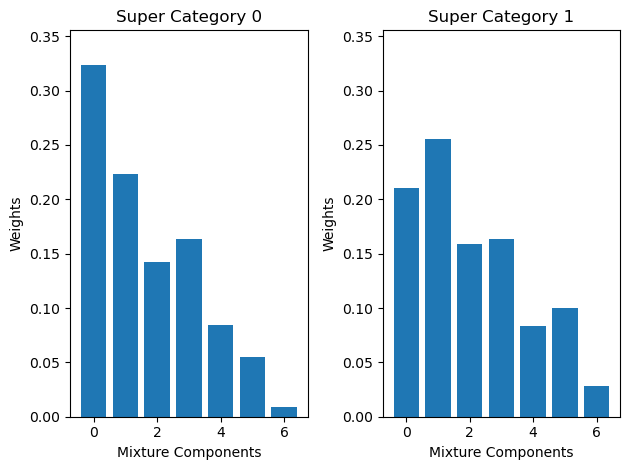

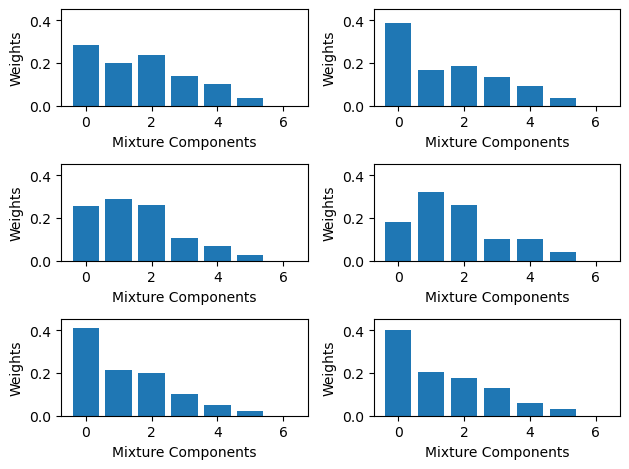


🔁 Round 72 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 307116.46
📌 Optimizing model...
  [Model] Step 0, loss = 311208.97
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


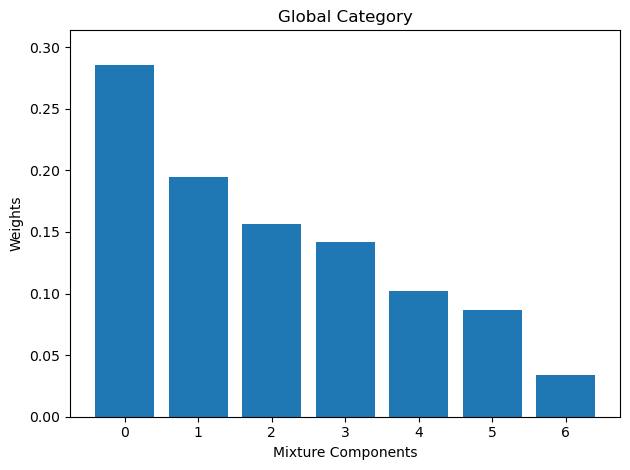

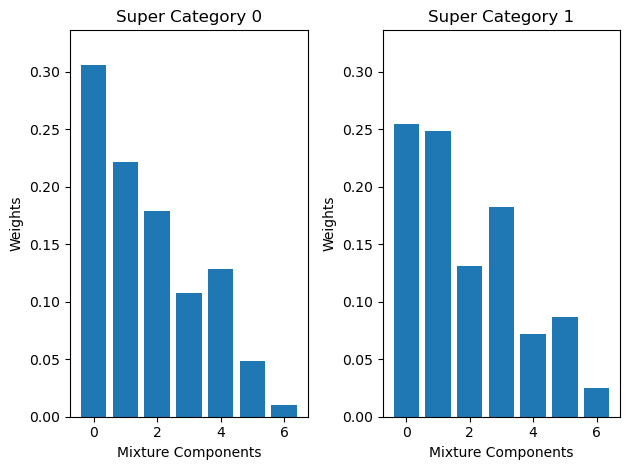

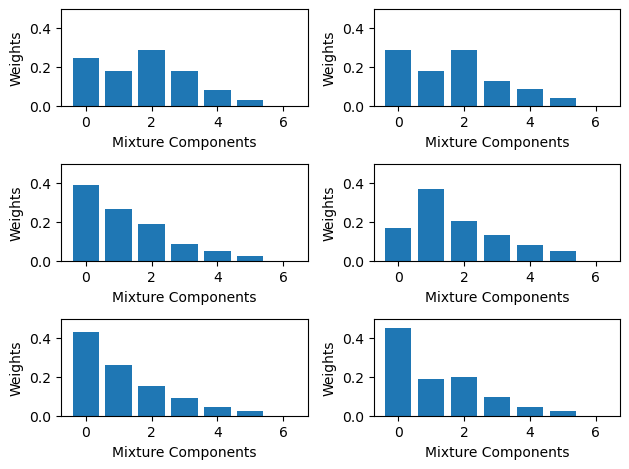


🔁 Round 73 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 306723.17
📌 Optimizing model...
  [Model] Step 0, loss = 307958.76
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


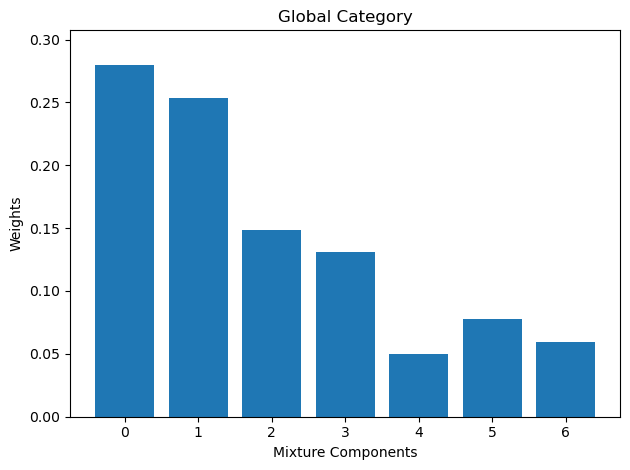

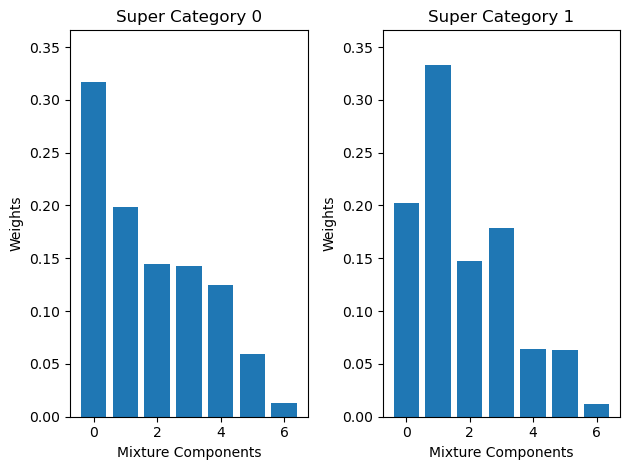

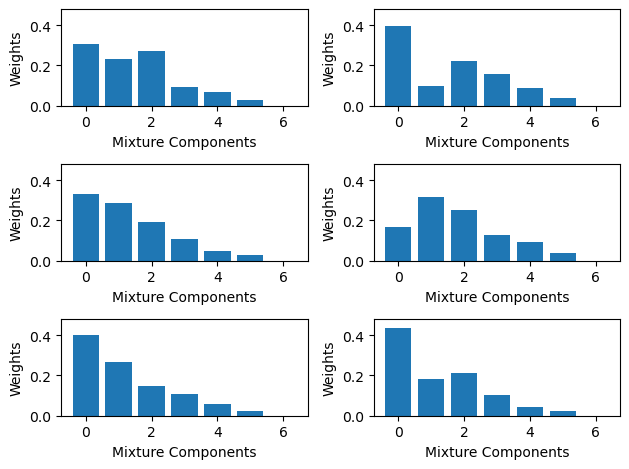


🔁 Round 74 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 306324.78
📌 Optimizing model...
  [Model] Step 0, loss = 308048.10
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


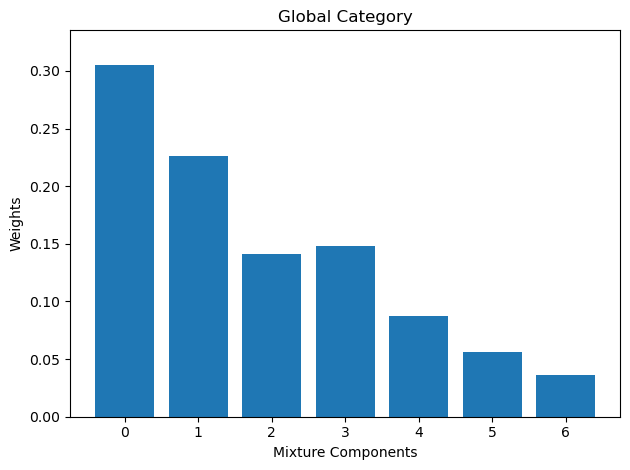

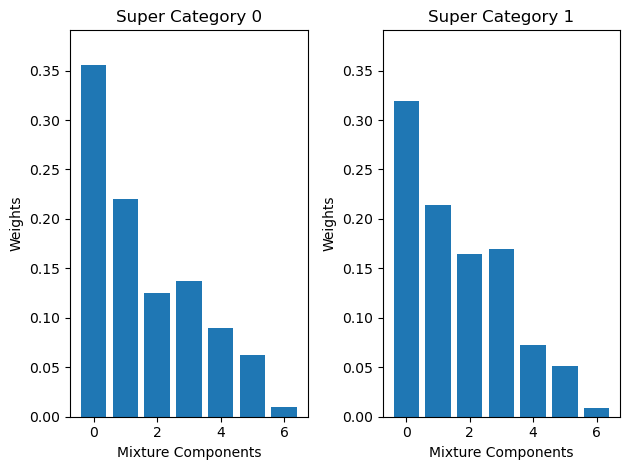

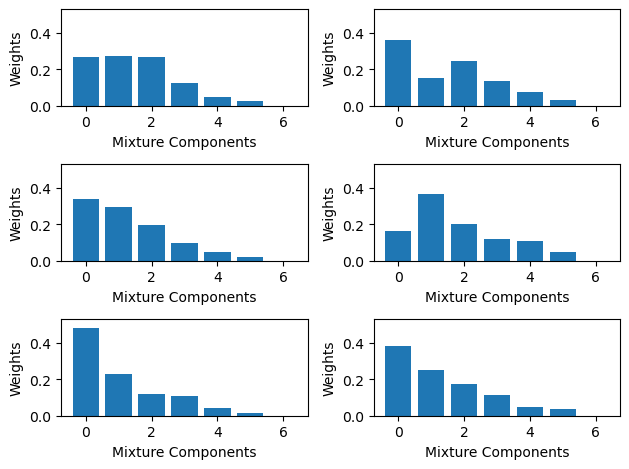


🔁 Round 75 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 306170.00
📌 Optimizing model...
  [Model] Step 0, loss = 306410.43
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


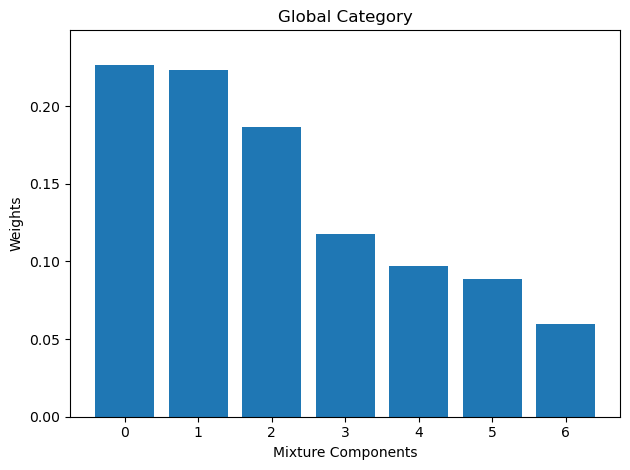

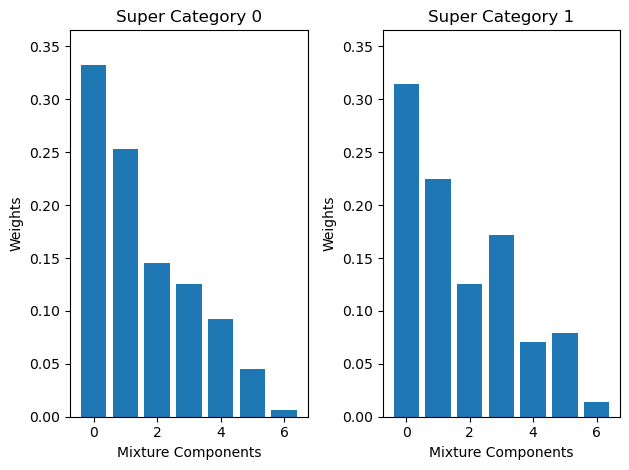

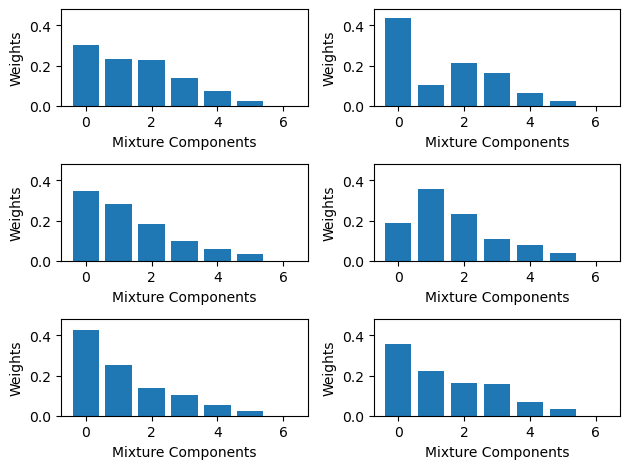


🔁 Round 76 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 307990.91
📌 Optimizing model...
  [Model] Step 0, loss = 307631.17
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


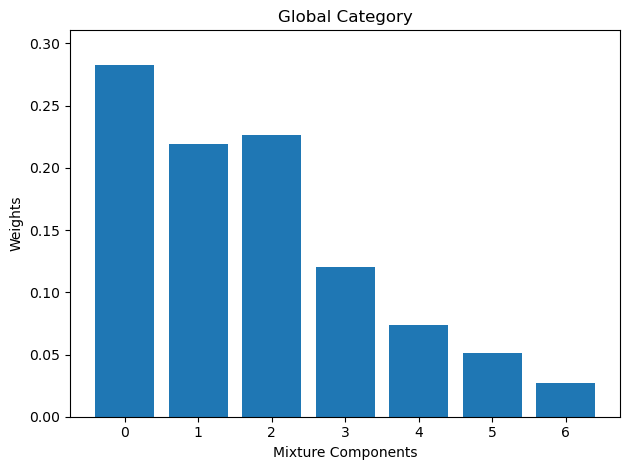

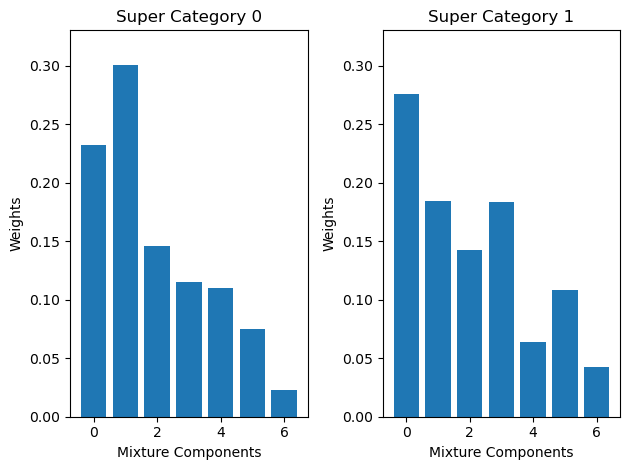

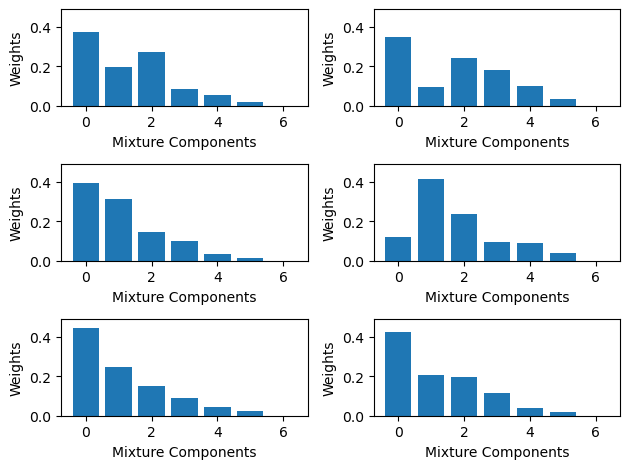


🔁 Round 77 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 307023.42
📌 Optimizing model...
  [Model] Step 0, loss = 308538.07
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


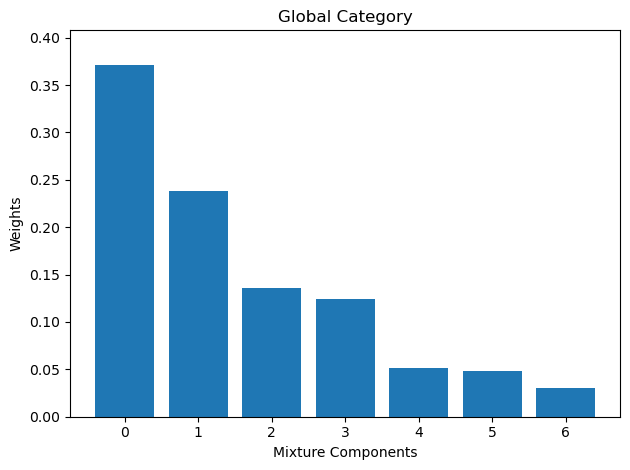

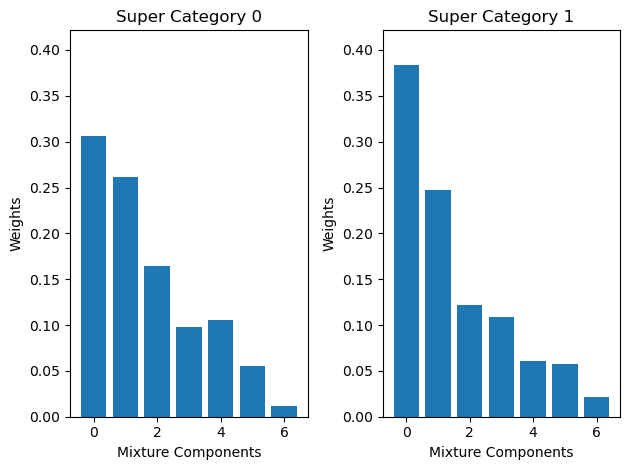

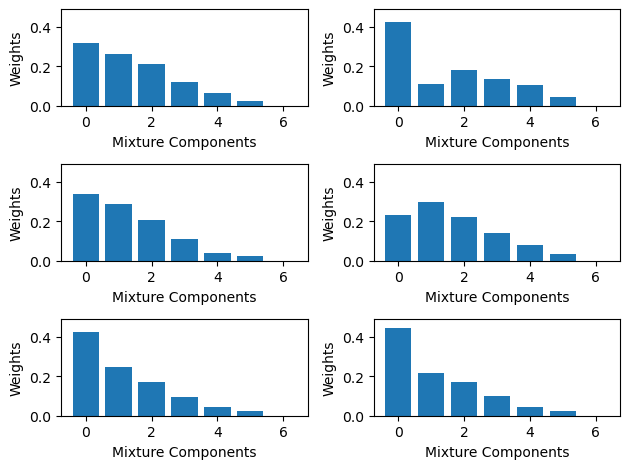


🔁 Round 78 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 305776.63
📌 Optimizing model...
  [Model] Step 0, loss = 308190.17
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


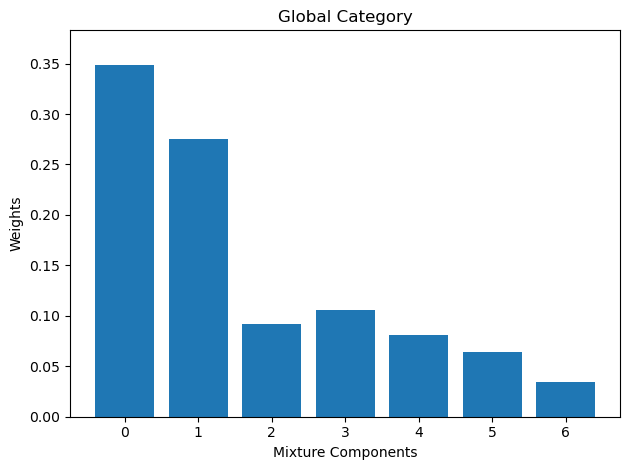

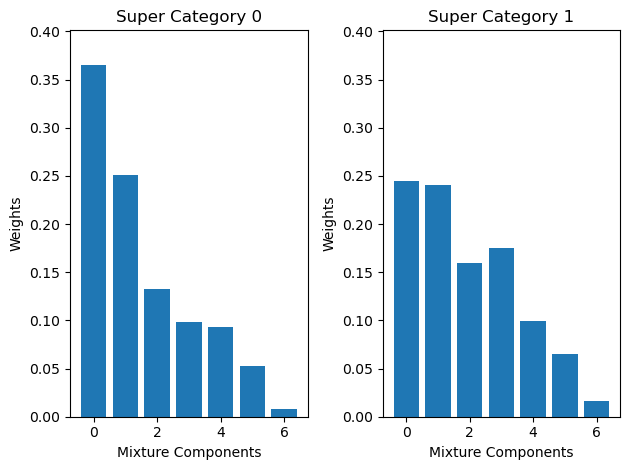

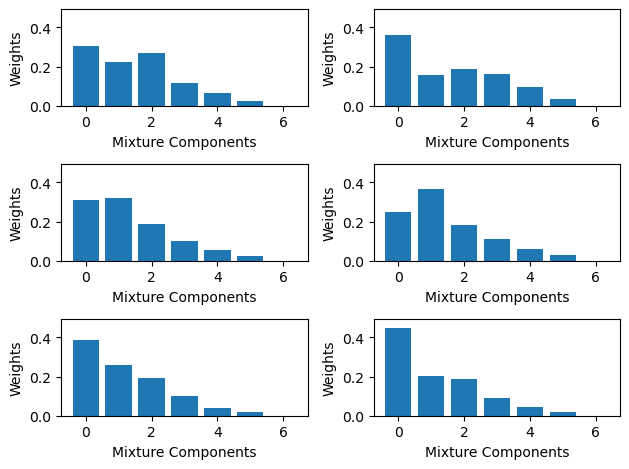


🔁 Round 79 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 307098.22
📌 Optimizing model...
  [Model] Step 0, loss = 306930.86
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


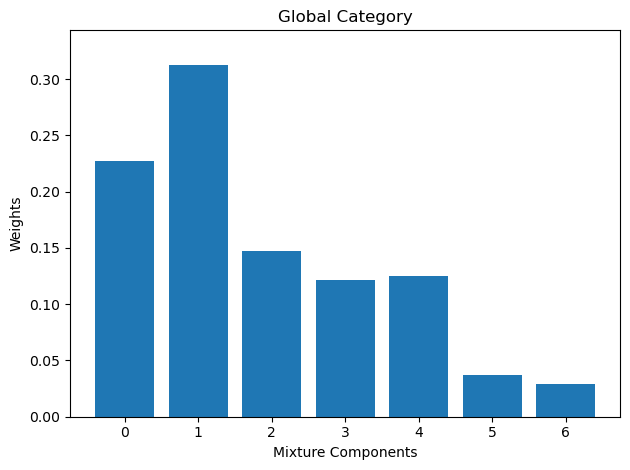

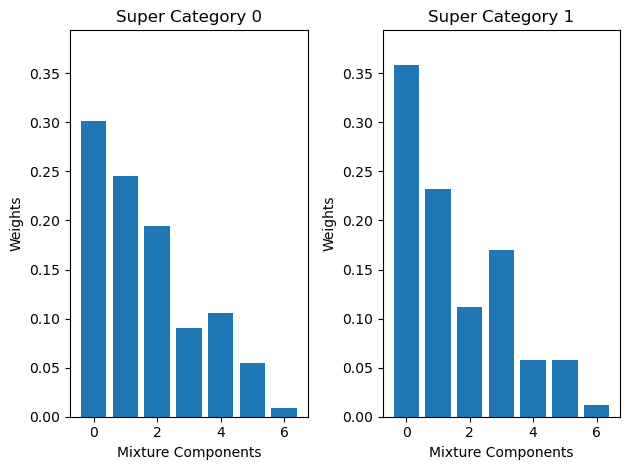

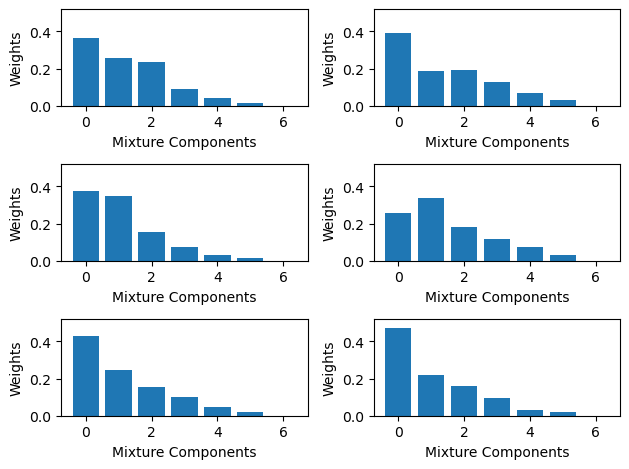


🔁 Round 80 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 307095.85
📌 Optimizing model...
  [Model] Step 0, loss = 306662.16
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


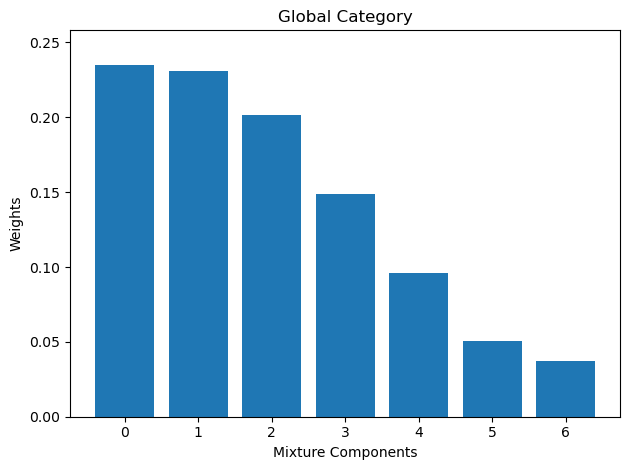

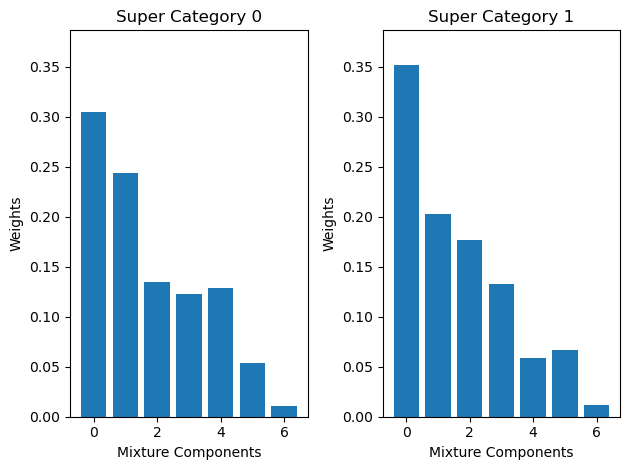

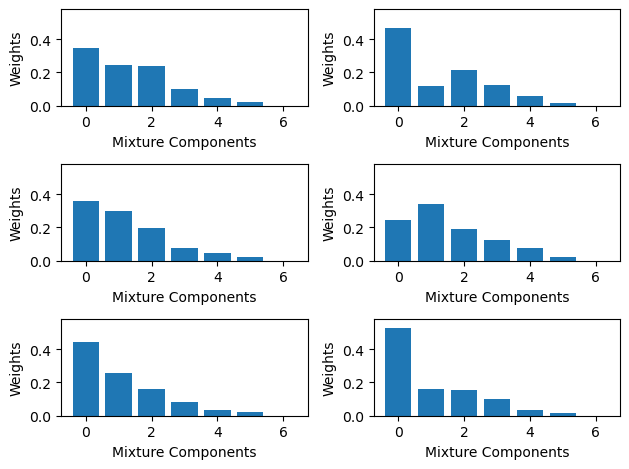


🔁 Round 81 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 306554.58
📌 Optimizing model...
  [Model] Step 0, loss = 306138.06
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


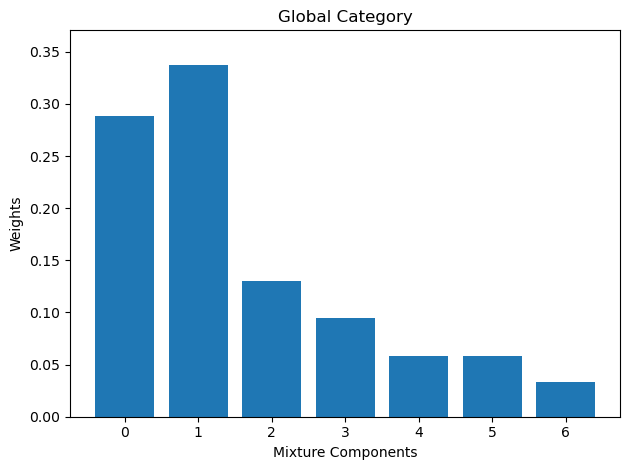

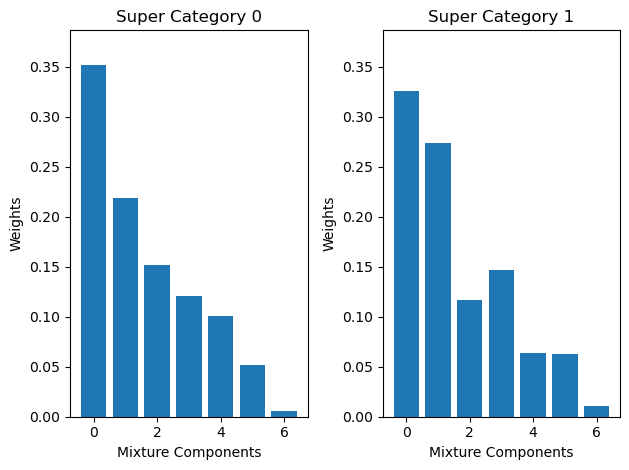

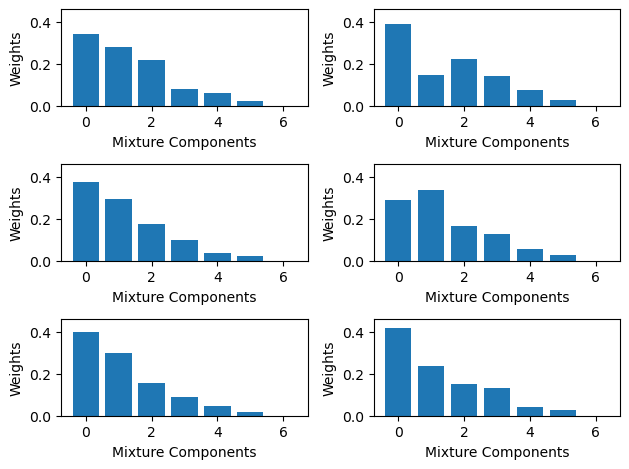


🔁 Round 82 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 305469.32
📌 Optimizing model...
  [Model] Step 0, loss = 305913.00
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


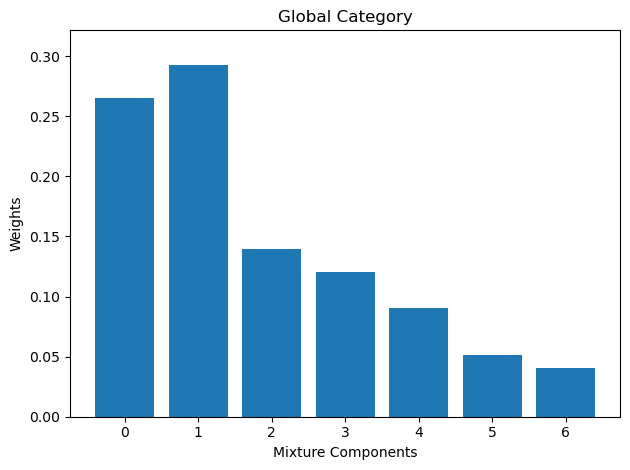

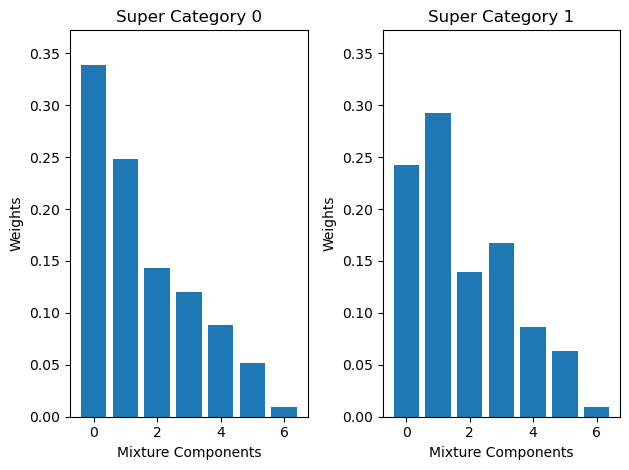

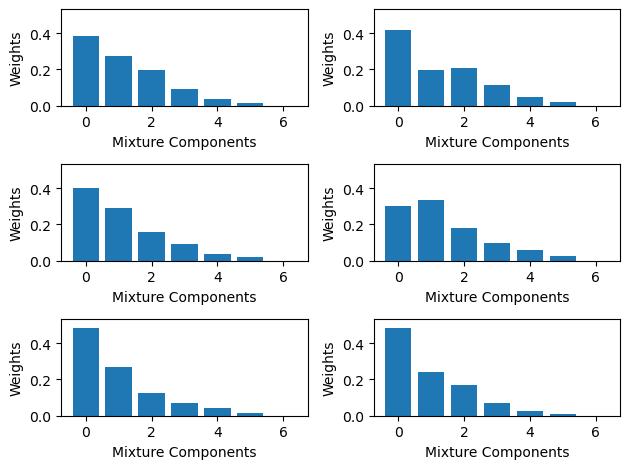


🔁 Round 83 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 307528.93
📌 Optimizing model...
  [Model] Step 0, loss = 307586.49
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


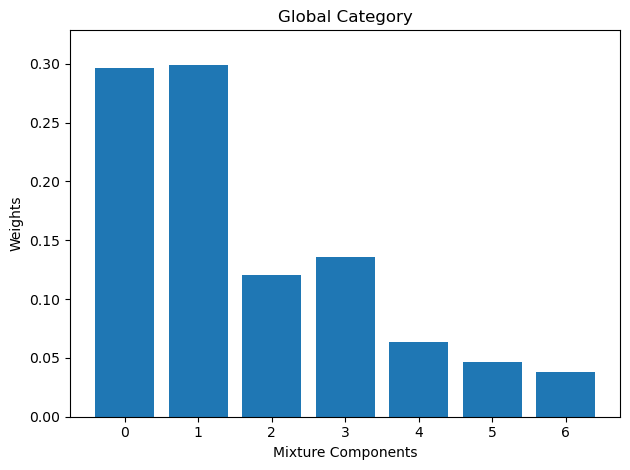

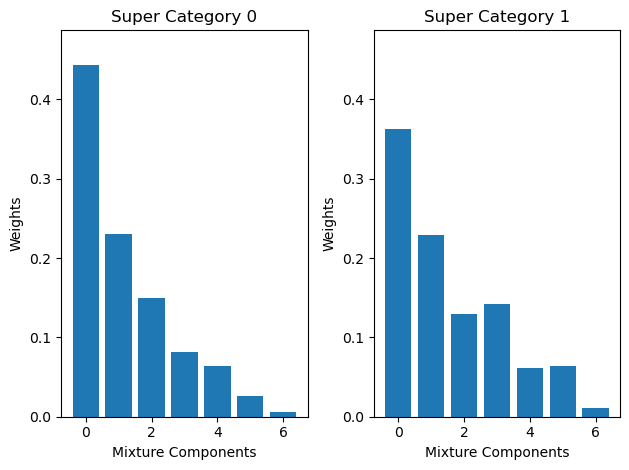

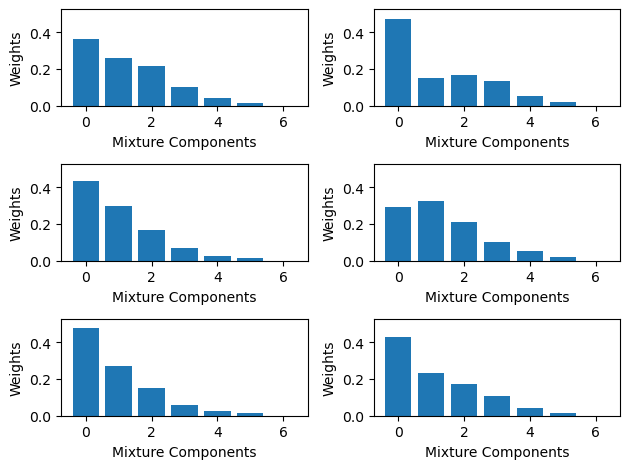


🔁 Round 84 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 306518.99
📌 Optimizing model...
  [Model] Step 0, loss = 305371.60
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


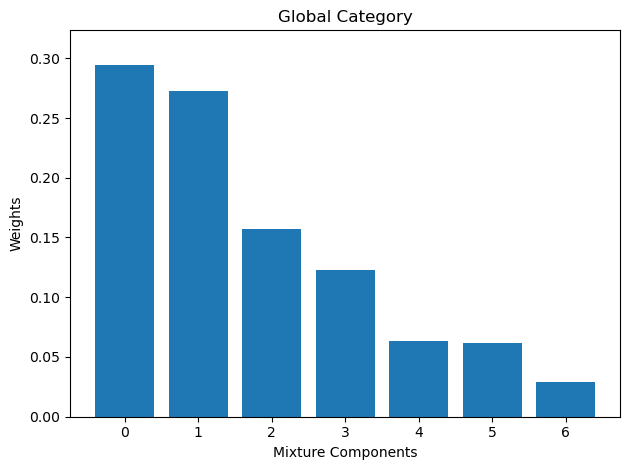

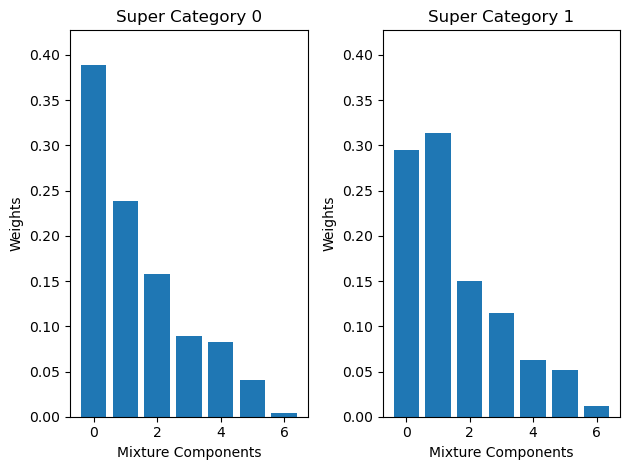

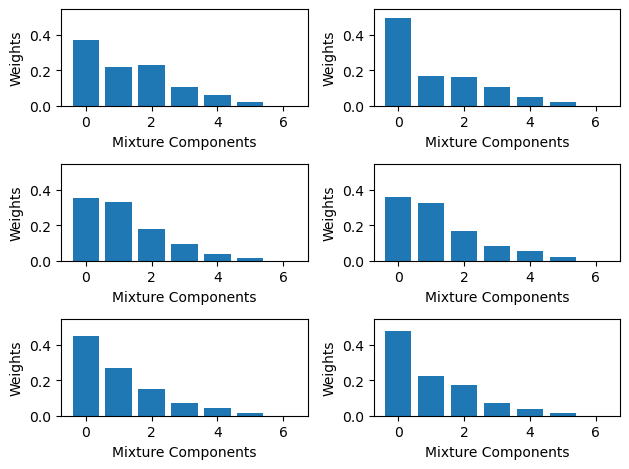


🔁 Round 85 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 306677.79
📌 Optimizing model...
  [Model] Step 0, loss = 308885.84
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


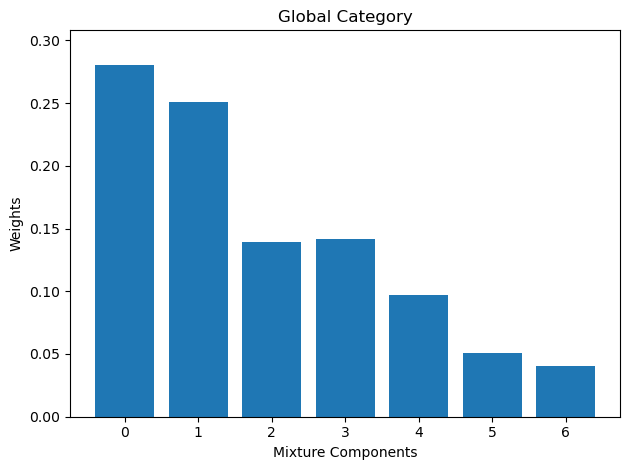

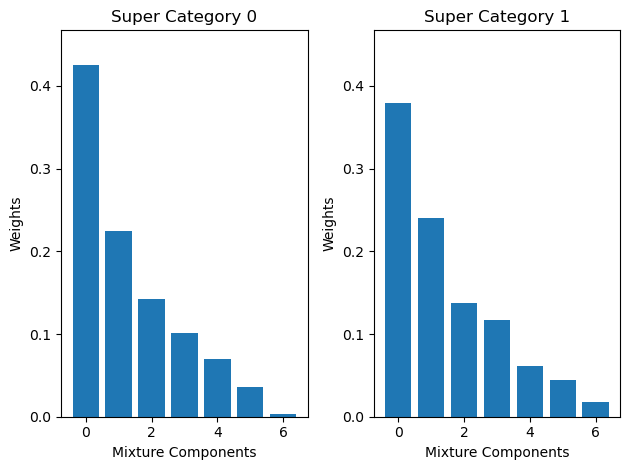

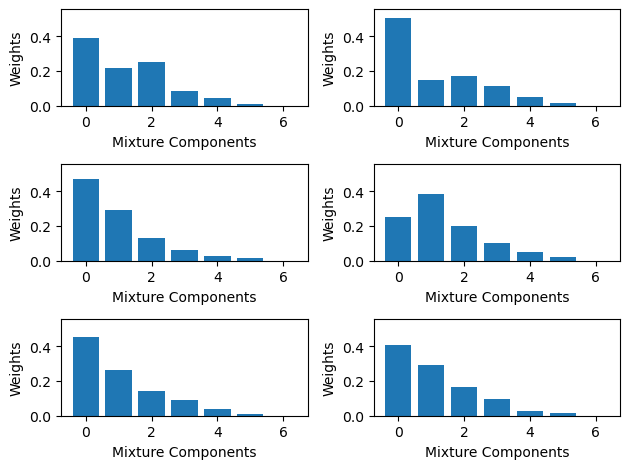


🔁 Round 86 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 307984.05
📌 Optimizing model...
  [Model] Step 0, loss = 308608.20
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


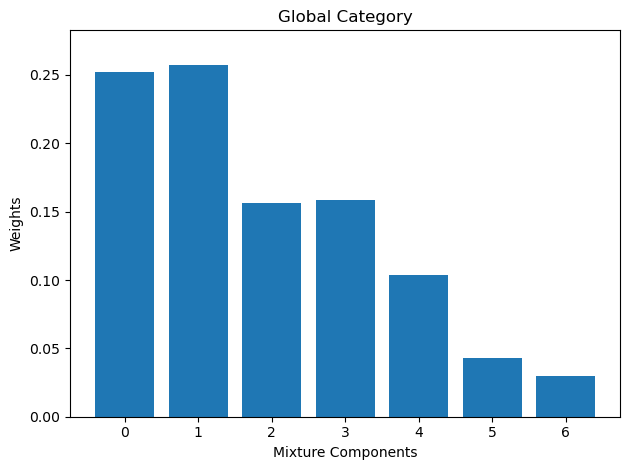

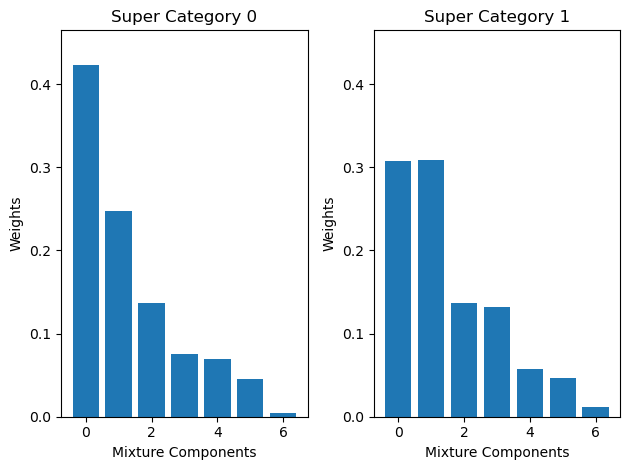

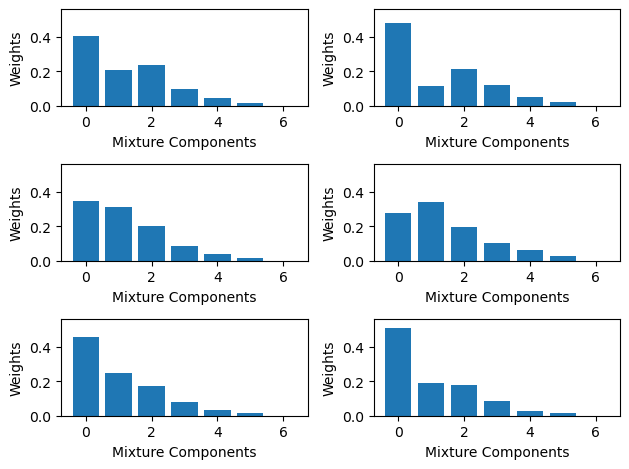


🔁 Round 87 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 304965.29
📌 Optimizing model...
  [Model] Step 0, loss = 306300.73
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


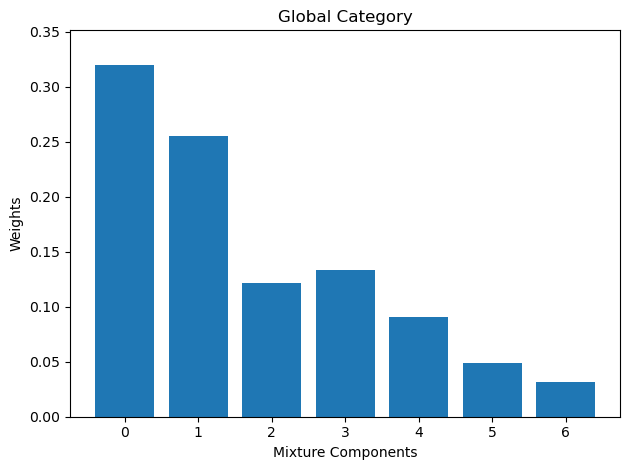

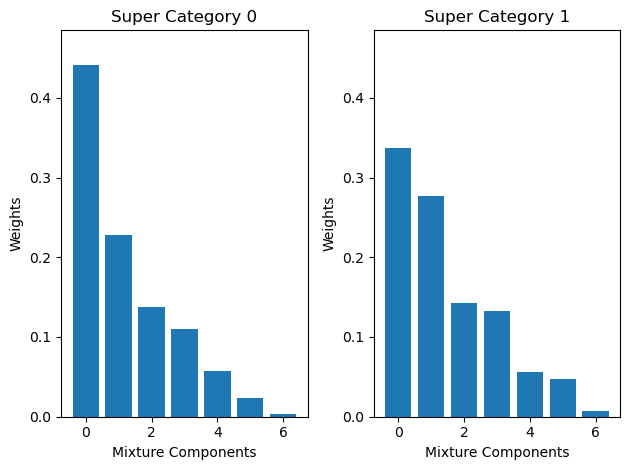

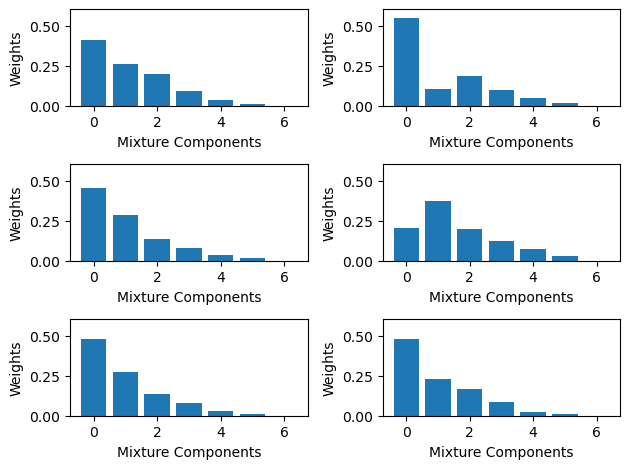


🔁 Round 88 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 305366.77
📌 Optimizing model...
  [Model] Step 0, loss = 306209.55
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


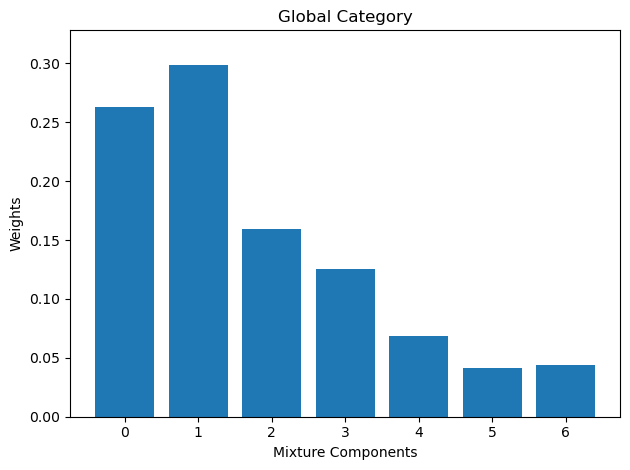

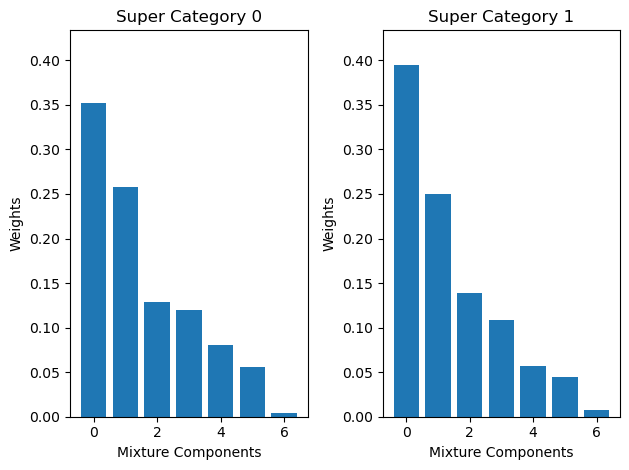

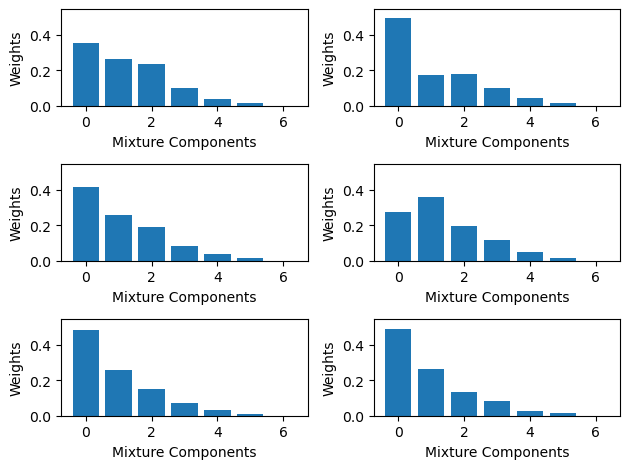


🔁 Round 89 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 308115.13
📌 Optimizing model...
  [Model] Step 0, loss = 303743.76
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


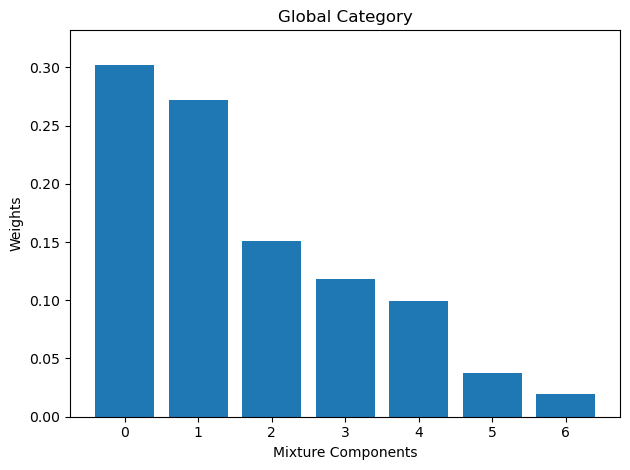

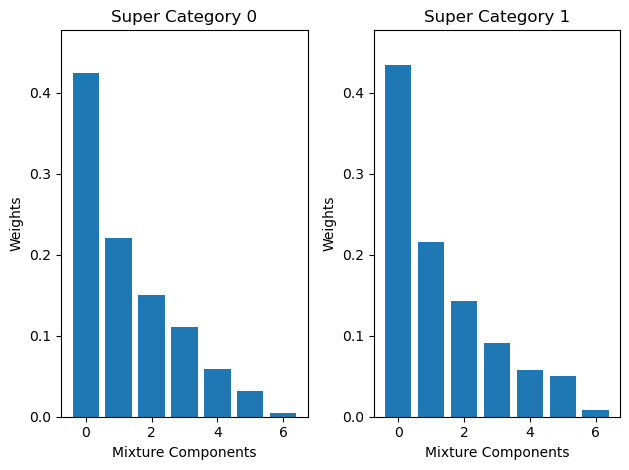

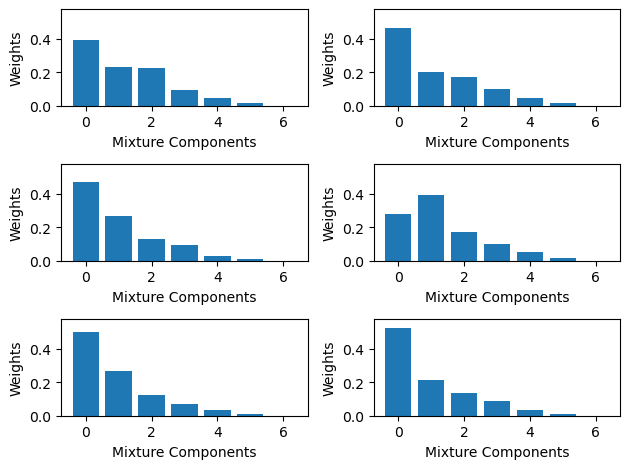


🔁 Round 90 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 306224.11
📌 Optimizing model...
  [Model] Step 0, loss = 307787.32
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


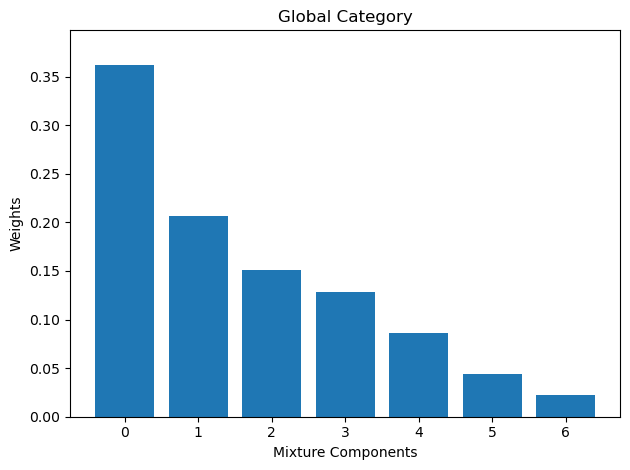

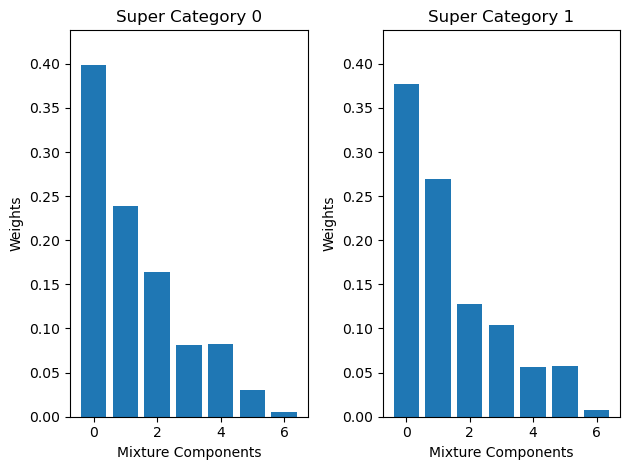

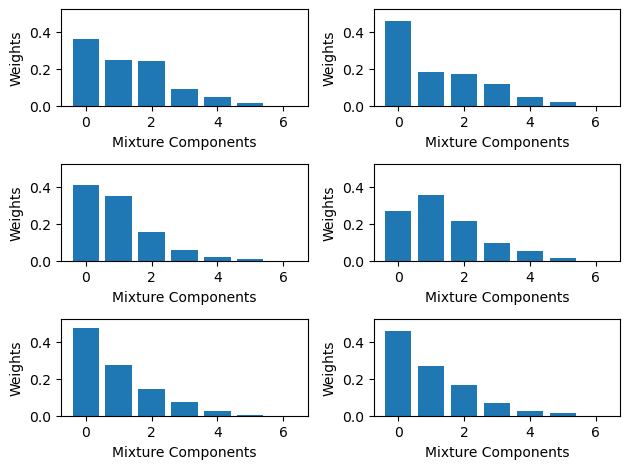


🔁 Round 91 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 306102.88
📌 Optimizing model...
  [Model] Step 0, loss = 303885.85
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


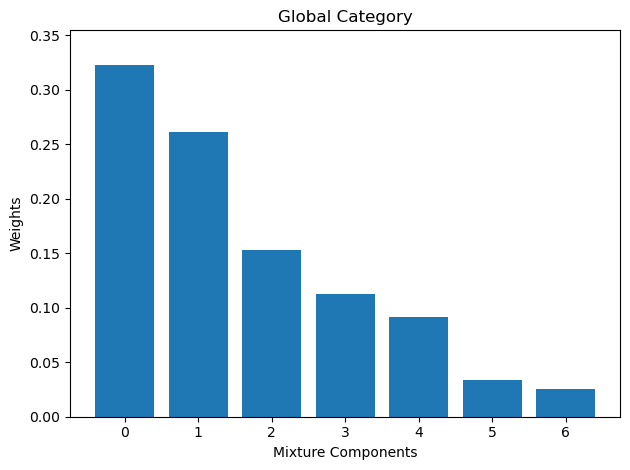

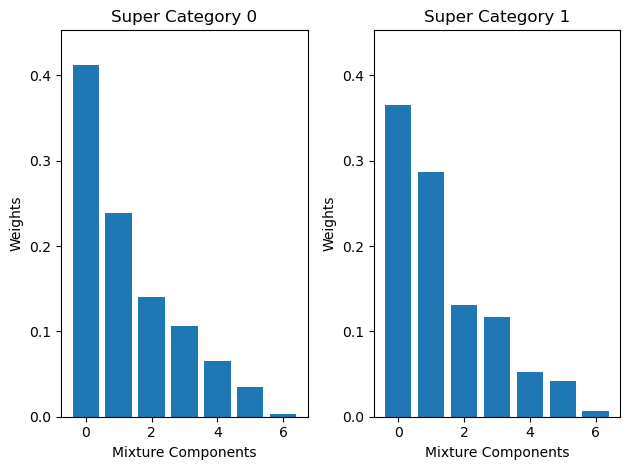

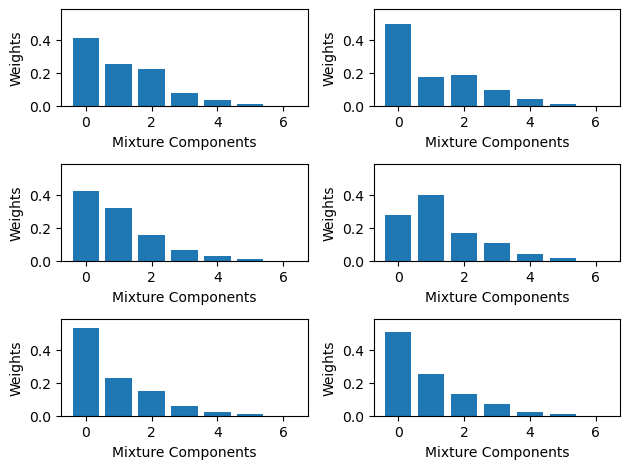


🔁 Round 92 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 305412.09
📌 Optimizing model...
  [Model] Step 0, loss = 306032.06
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


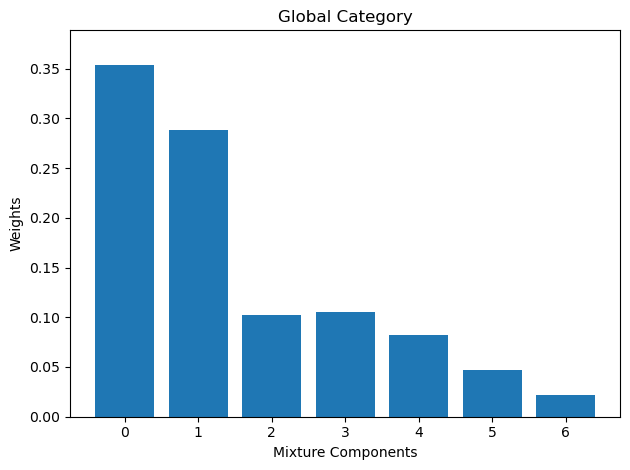

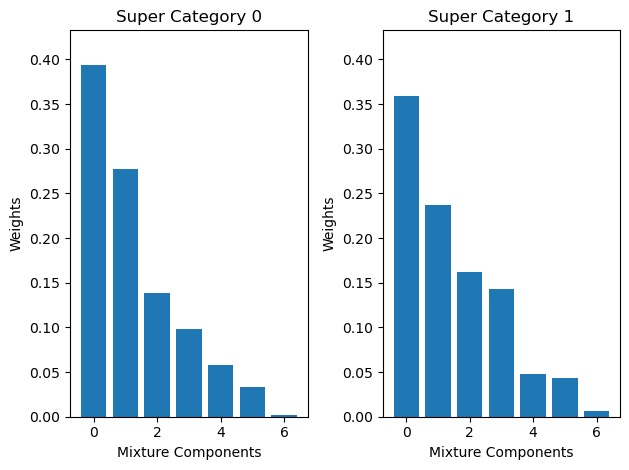

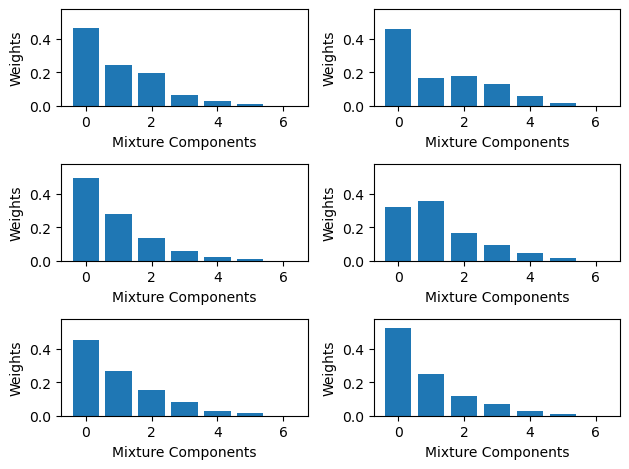


🔁 Round 93 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 305715.71
📌 Optimizing model...
  [Model] Step 0, loss = 306278.22
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


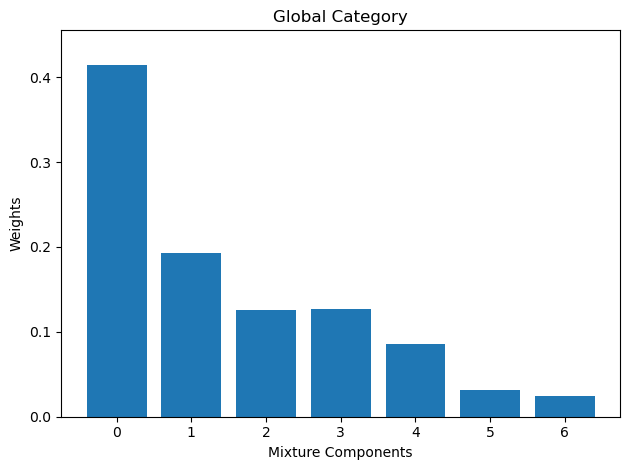

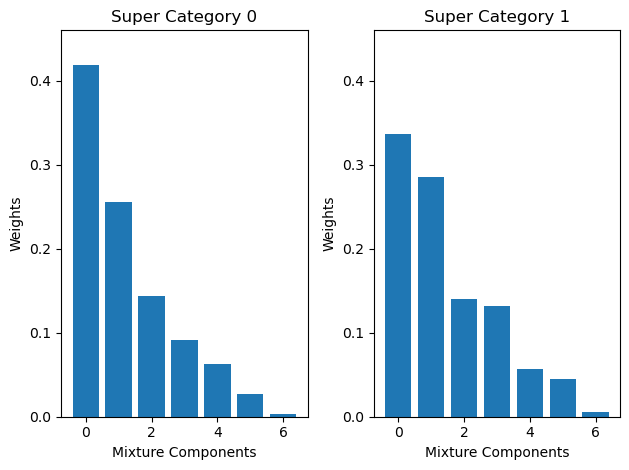

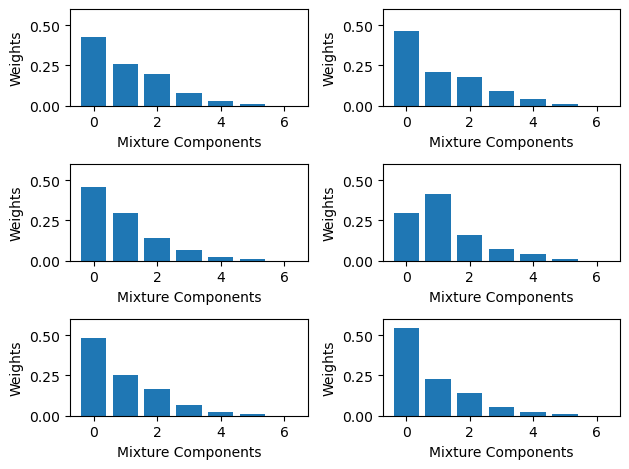


🔁 Round 94 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 305601.03
📌 Optimizing model...
  [Model] Step 0, loss = 307158.52
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


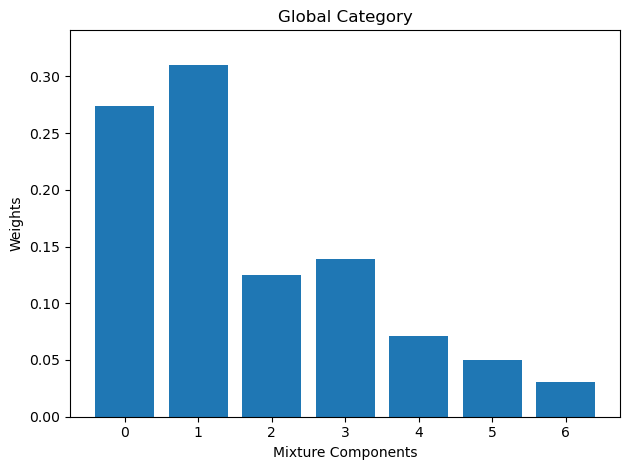

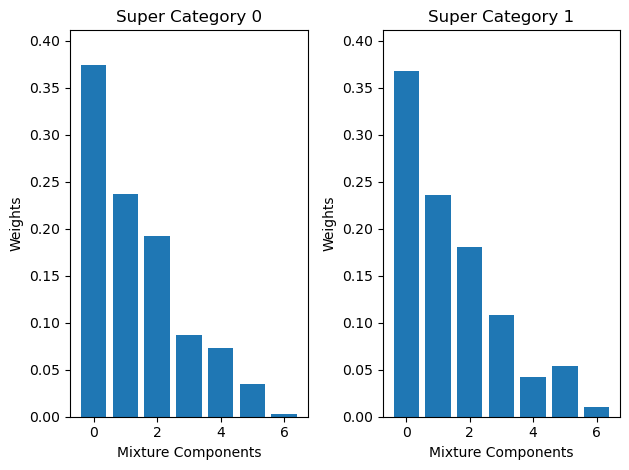

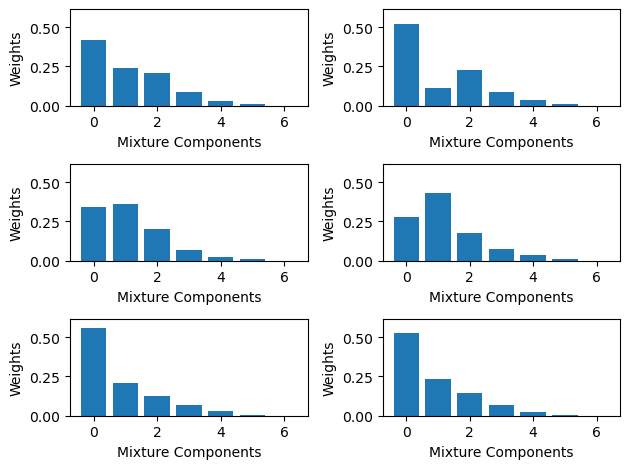


🔁 Round 95 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 305813.01
📌 Optimizing model...
  [Model] Step 0, loss = 305768.46
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


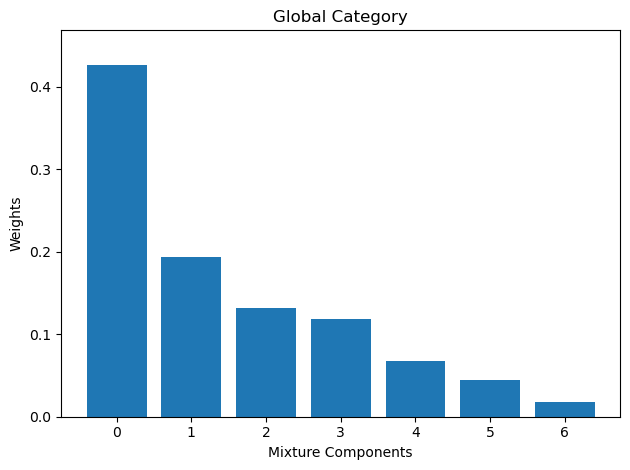

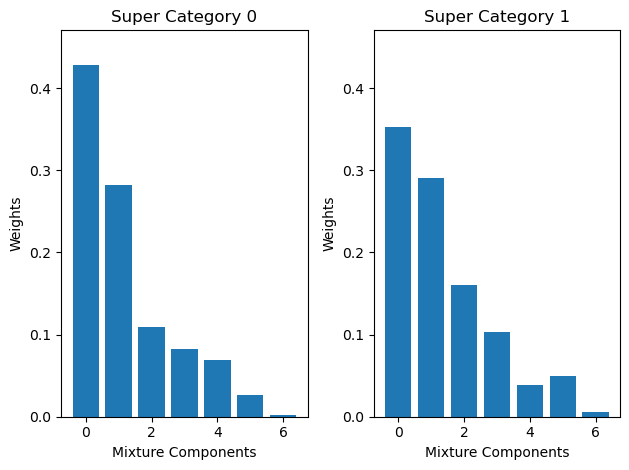

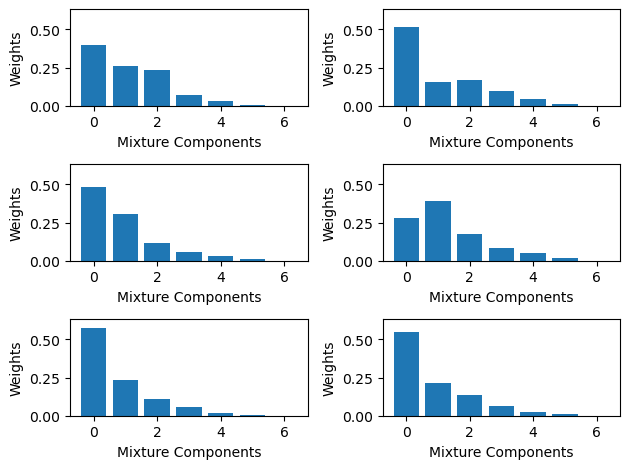


🔁 Round 96 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 305982.46
📌 Optimizing model...
  [Model] Step 0, loss = 304570.94
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


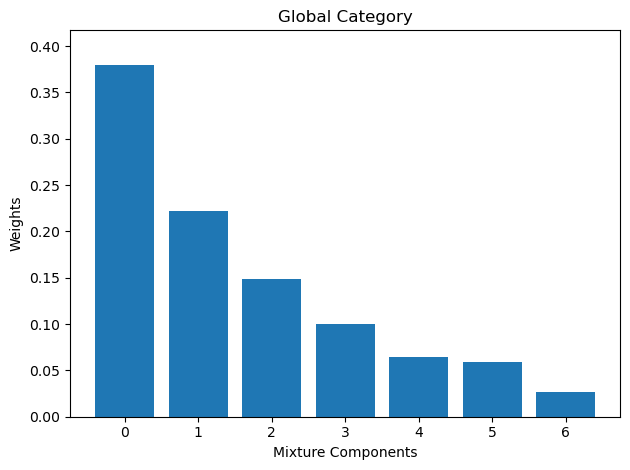

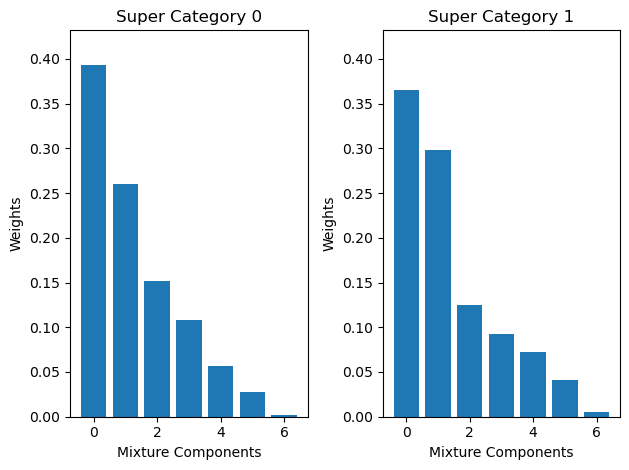

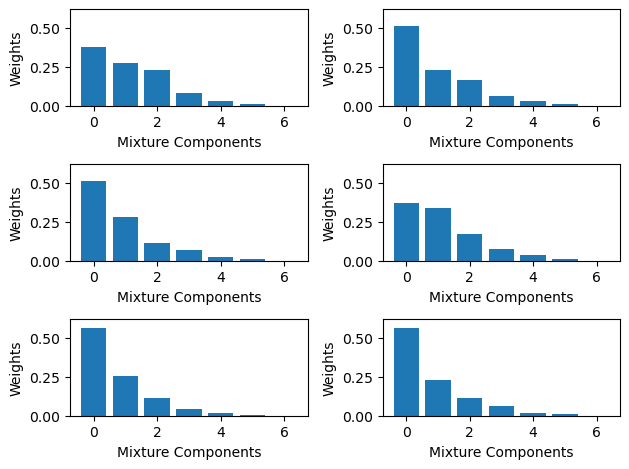


🔁 Round 97 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 305607.24
📌 Optimizing model...
  [Model] Step 0, loss = 306118.79
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


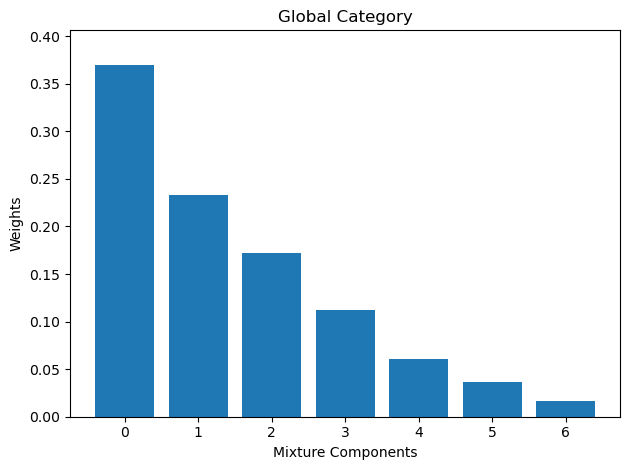

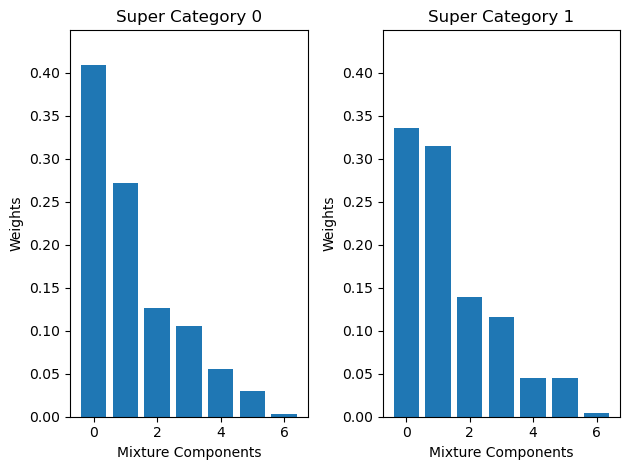

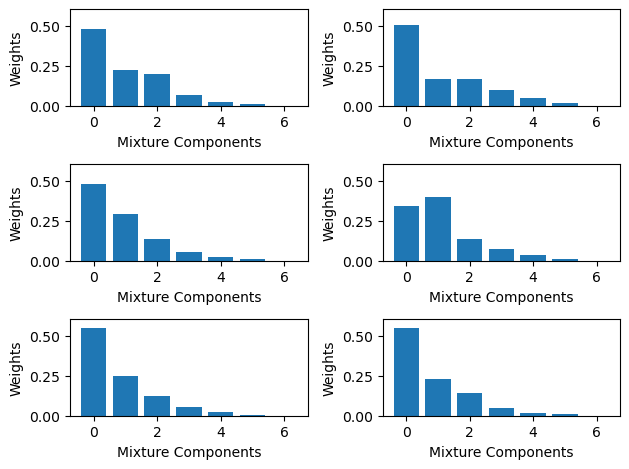


🔁 Round 98 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 305430.83
📌 Optimizing model...
  [Model] Step 0, loss = 304239.52
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


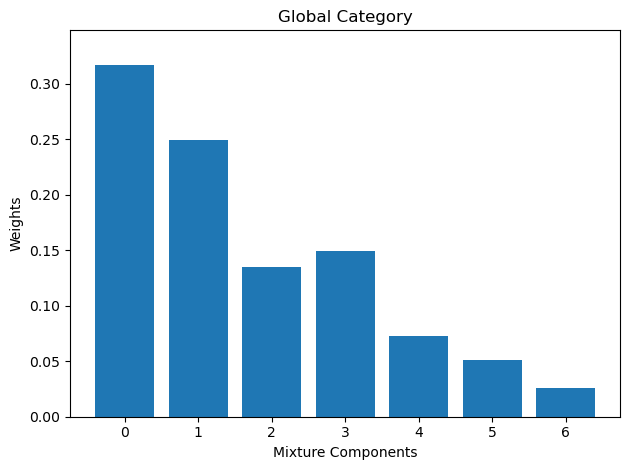

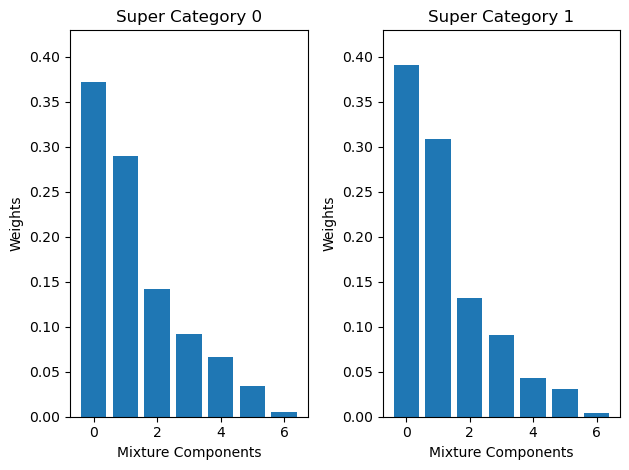

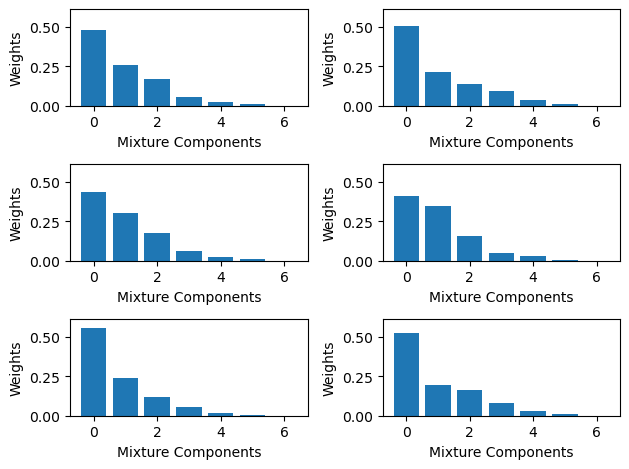


🔁 Round 99 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 305698.28
📌 Optimizing model...
  [Model] Step 0, loss = 305718.16
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


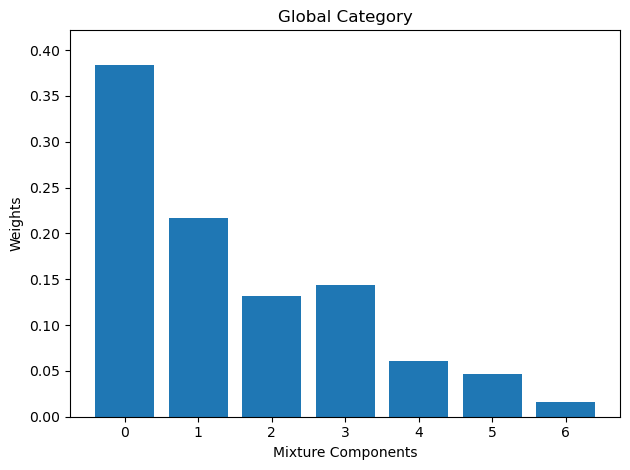

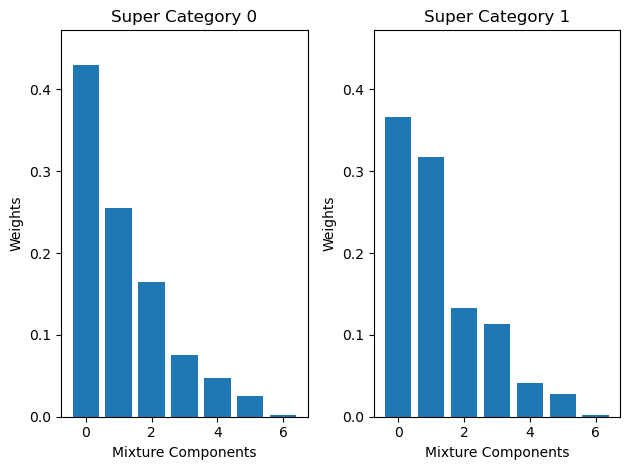

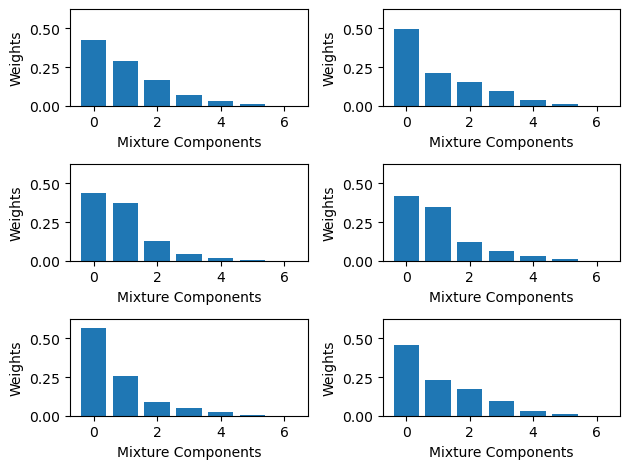


🔁 Round 100 / 100
📌 Optimizing guide...
  [Guide] Step 0, loss = 305787.93
📌 Optimizing model...
  [Model] Step 0, loss = 305703.77
torch.Size([7])
torch.Size([2, 7])
torch.Size([3, 2, 7])


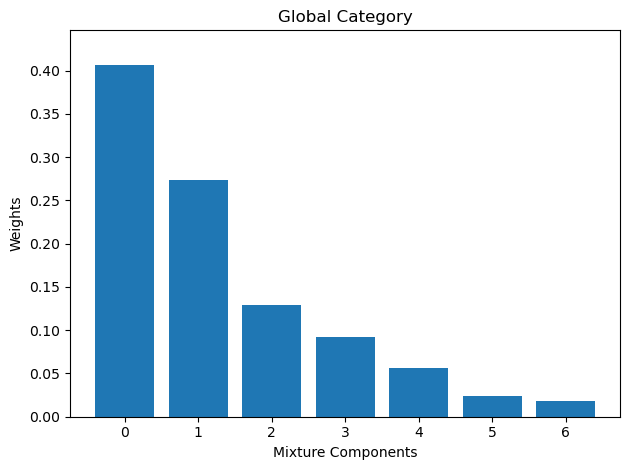

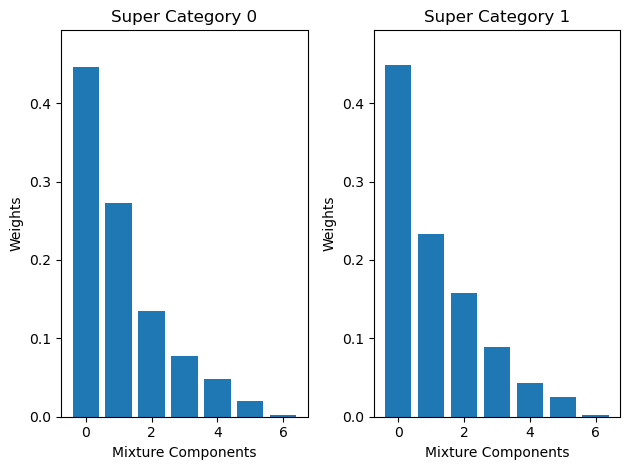

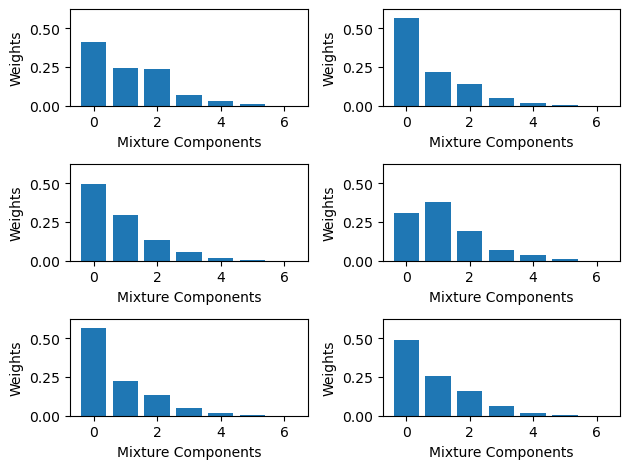

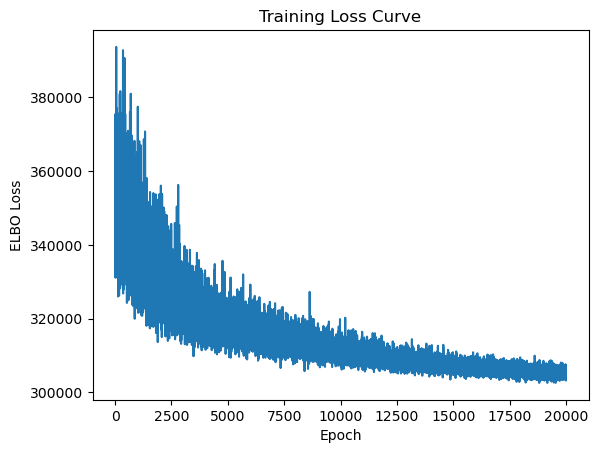

In [40]:

dataset = (ground_truth["x"].to(torch.float32), ground_truth["y"].view(-1))

device = torch.device("cpu")
# Training settings
num_epochs = 1000
log_every = 100
lr = 1e-3

# Set up optimizer and ELBO
optim = pyro.optim.Adam({"lr": lr})

elbo = TraceEnum_ELBO(max_plate_nesting=1)
elbo_2 = Trace_ELBO(max_plate_nesting=1)
svi = SVI(model_with_ground_truth, guide_2, optim, loss=elbo_2)


predictive = Predictive(model, guide=guide_2, num_samples=100)

# === Alternating training loop ===
num_rounds = 100
posterior_steps = 100
model_steps = 100
losses = []

for seed in range(0, 400, 100):
    pyro.clear_param_store()
    pyro.set_rng_seed(seed)

    # for epoch in range(num_epochs):
    #     pyro.clear_param_store()
    #     loss = svi.step(dataset, struct_upbd, vocab_size, device)
        
    #     losses.append(loss)
        
    #     if epoch % log_every == 0:
    #         print(f"Epoch {epoch:04d}  Loss: {loss:.4f}")
    #         optim.set_state({"lr": lr/(epoch+1)})
    for round_idx in range(num_rounds):
        print(f"\n🔁 Round {round_idx + 1} / {num_rounds}")
    
        # Phase 1: Guide (Posterior inference)
        set_requires_grad_by_prefix("model_", False)
        set_requires_grad_by_prefix("guide_", True)
        print("📌 Optimizing guide...")
        for step in range(posterior_steps):
            loss = svi.step(dataset, struct_upbd, vocab_size, device)
            losses.append(loss)
            if step % 100 == 0:
                print(f"  [Guide] Step {step}, loss = {loss:.2f}")
    
        # Phase 2: Model (Generative parameter update)
        set_requires_grad_by_prefix("guide_", False)
        set_requires_grad_by_prefix("model_", True)

        
        print("📌 Optimizing model...")
        for step in range(model_steps):
            loss = svi.step(dataset, struct_upbd, vocab_size, device)
            losses.append(loss)
            if step % 100 == 0:
                print(f"  [Model] Step {step}, loss = {loss:.2f}")
        visualize_learned_structure(predictive, dataset, struct_upbd, vocab_size, device)
        
    # Optional: plot loss
    try:
        import matplotlib.pyplot as plt
        plt.plot(losses)
        plt.xlabel("Epoch")
        plt.ylabel("ELBO Loss")
        plt.title("Training Loss Curve")
        plt.show()
    except ImportError:
        pass
    break



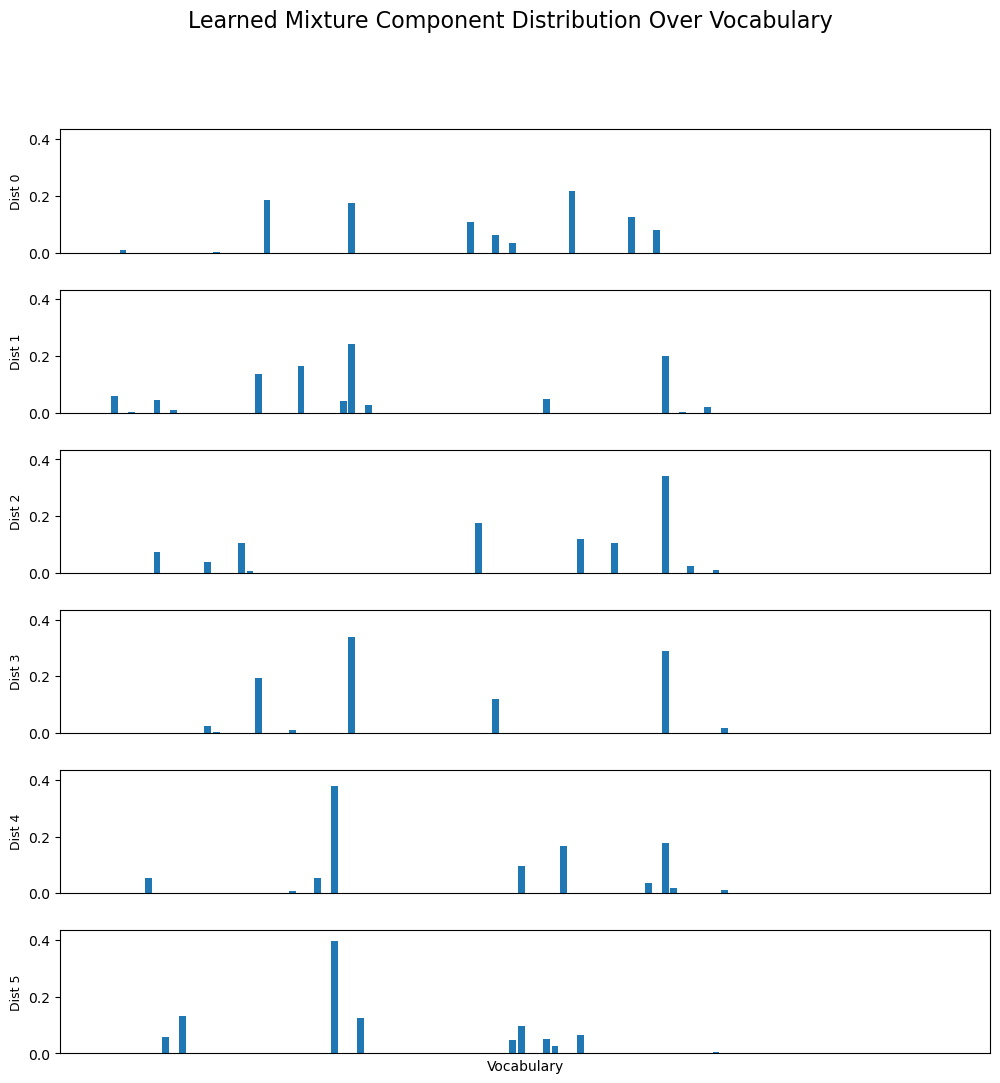

In [33]:
N = struct_upbd["G0"]
dists = pyro.get_param_store().get_param("model_phi_u").detach()

fig, axs = plt.subplots(N, 1, figsize=(12, 2 * N), sharex=True)  # Share x-axis, increase height

for i in range(N):
    ax = axs[i]
    ax.bar(range(dists.size(1)), dists[i].numpy())
    ax.set_ylabel(f'Dist {i}', fontsize=9)
    ax.set_ylim(0, dists.max().item() * 1.1)

    # Hide x-axis labels except for the last one
    if i < N - 1:
        ax.set_xticks([])
    else:
        ax.set_xlabel("Vocabulary", fontsize=10)

# Tight layout with spacing between plots
fig.suptitle(f"Learned Mixture Component Distribution Over Vocabulary", fontsize=16)
plt.subplots_adjust(hspace=0.3)
plt.show()

In [62]:
# sns.heatmap(dists.numpy(), cmap='viridis', annot=True, cbar=True)
# plt.xlabel("Category")
# plt.ylabel("Distribution Index")
# plt.title("Discrete Distribution Parameters Heatmap")
# plt.show()


In [29]:

# true_params = data["word_dists"]
# candidate_params = pyro.get_param_store().get_param("model_phi_u").detach()
# # print(true_params.shape)
# # print(candidate_params.shape)

# # Normalize to make them valid distributions
# true_params /= true_params.sum(dim=1, keepdim=True)
# candidate_params /= candidate_params.sum(dim=1, keepdim=True)
# assert torch.allclose(true_params.sum(dim=1), torch.ones_like(true_params.sum(dim=1)), atol=1e-4)
# assert torch.allclose(candidate_params.sum(dim=1), torch.ones_like(candidate_params.sum(dim=1)), atol=1e-4)


# Compute Jensen-Shannon distance between all pairs
# def jensen_shannon(p, q, eps=1e-8):
#     # Normalize inputs to ensure valid distributions
#     p = p / (p.sum(dim=-1, keepdim=True) + eps)
#     q = q / (q.sum(dim=-1, keepdim=True) + eps)
#     m = 0.5 * (p + q)

#     # Compute KL divergences: kl_div expects log-prob as input
#     kl_pm = F.kl_div((p + eps).log(), m, reduction='none').sum(-1)
#     kl_qm = F.kl_div((q + eps).log(), m, reduction='none').sum(-1)

#     return 0.5 * (kl_pm + kl_qm)
def jensen_shannon(p, q, eps=1e-8):
    p = p / (p.sum(dim=-1, keepdim=True) + eps)
    q = q / (q.sum(dim=-1, keepdim=True) + eps)
    m = 0.5 * (p + q)

    kl_pm = (p * ((p + eps).log() - (m + eps).log())).sum(-1)
    kl_qm = (q * ((q + eps).log() - (m + eps).log())).sum(-1)

    return 0.5 * (kl_pm + kl_qm)
# # Expand for broadcasting: (6, 1, K) and (1, 20, K) → (6, 20, K)
# p_exp = true_params[:, None, :]  # shape [6, 1, K]
# q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# # JS similarity matrix: shape [6, 20]
# js_matrix = jensen_shannon(p_exp, q_exp)

# # Optional: convert to similarity score (1 - distance)
# similarity = 1 - js_matrix

# print(similarity)

In [64]:
# sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
# plt.xlabel("Candidate Index")
# plt.ylabel("Ground Truth Index")
# plt.title("Jensen-Shannon Similarity")
# plt.show()


tensor([-1.5000, -0.9000, -0.3000,  0.3000,  0.9000,  1.5000])
tensor([-0.7040, -0.4783, -0.3306, -0.3295,  0.3068,  1.3174])
tensor([1.0545, 0.3031, 0.5291, 0.0502, 0.7976, 0.0488])


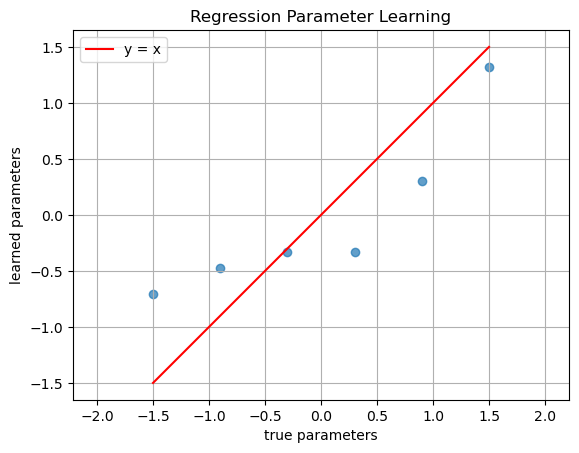

In [30]:
true_params = torch.linspace(-struct_upbd["G0"]/4, struct_upbd["G0"]/4, steps=struct_upbd["G0"]) 
candidate_params = candidate_params = pyro.get_param_store().get_param("model_phi_y_mu").detach()
# Expand for broadcasting: (6, 1, K) and (1, 20, K) → (6, 20, K)
p_exp = true_params
q_exp,  _ = torch.sort(candidate_params)
print(p_exp)
print(q_exp)
print(pyro.get_param_store().get_param("model_phi_y_sigma").detach())
plt.scatter(p_exp, q_exp, alpha=0.7)
plt.plot(true_params, true_params, label='y = x', color='red')
plt.xlabel('true parameters')
plt.ylabel('learned parameters')
plt.title('Regression Parameter Learning')
plt.legend()
plt.grid(True)
plt.axis('equal')  # keep aspect ratio square
plt.show()

In [31]:
from pyro.infer import Predictive

# guide: your trained guide
# model: your model without obs
# num_samples: number of predictive samples

predictive = Predictive(model, guide=guide_2, num_samples=100)

# Omit `data` or provide partial input depending on your model
samples = predictive((None, None),struct_upbd, vocab_size, device)  # or data=..., depending on your model's inputs

AttributeError: 'NoneType' object has no attribute 'to'

In [77]:
predict = samples['y'][-100:].mean(dim=0)
predict_var = samples['y'][-100:].var(dim=0)

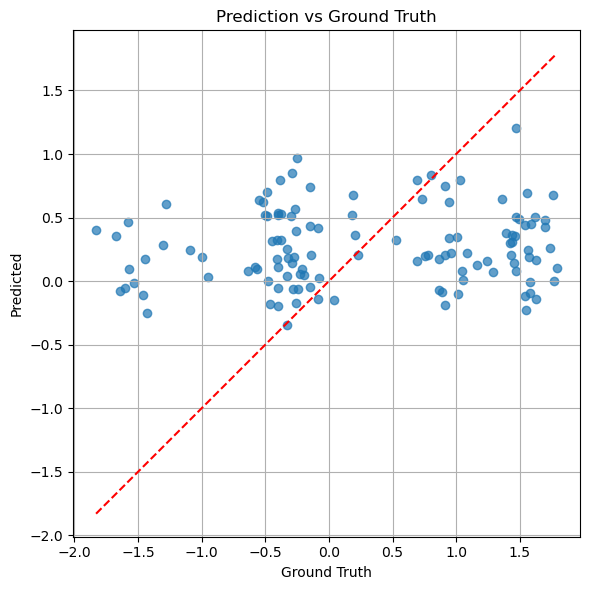

In [78]:
y_true = dataset[1]     # ground truth
y_pred = predict # predicted (with noise)
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.7)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')  # y = x line
plt.xlabel("Ground Truth")
plt.ylabel("Predicted")
plt.title("Prediction vs Ground Truth")
plt.grid(True)
plt.tight_layout()
plt.show()

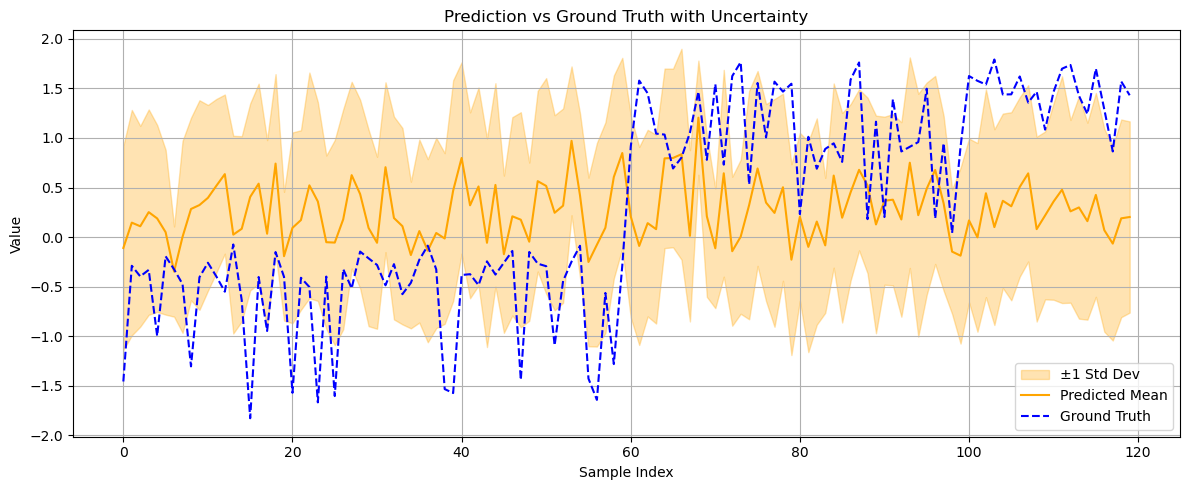

In [79]:
# Example data
N=120
mean_pred = y_pred
var_pred = predict_var

std_pred = var_pred.sqrt()
x = torch.arange(N)

plt.figure(figsize=(12, 5))

# Confidence interval (±1 std)
plt.fill_between(x, mean_pred - std_pred, mean_pred + std_pred, color="orange", alpha=0.3, label="±1 Std Dev")

# Prediction mean
plt.plot(x, mean_pred, color="orange", label="Predicted Mean")

# Ground truth
plt.plot(x, y_true, color="blue", linestyle="--", label="Ground Truth")

plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.title("Prediction vs Ground Truth with Uncertainty")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [70]:
predict_beta = samples['G2']
weights = mix_weights(predict_beta)[..., :-1]
mean_w = weights.mean(dim=0)
var_w = weights.var(dim=0)
print(mean_w.shape)

torch.Size([3, 2, 6])


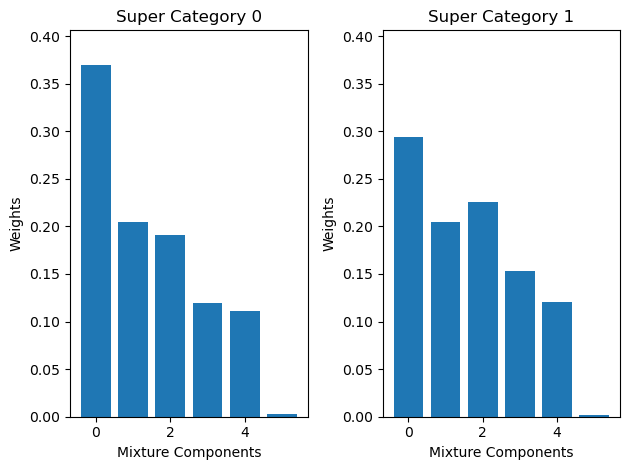

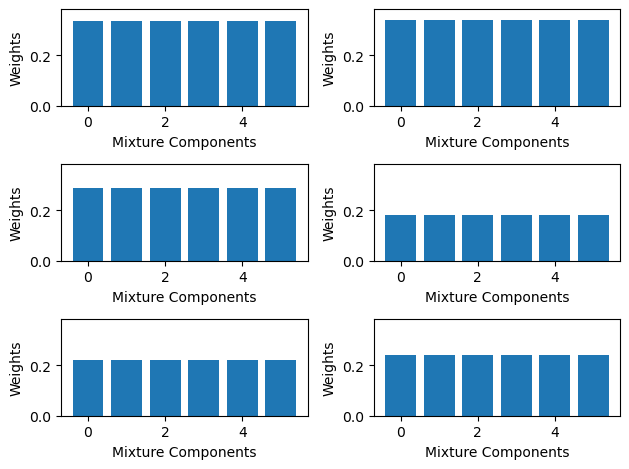

In [71]:
predict_beta = samples['G1']
weights = mix_weights(predict_beta)[..., :-1]
mean_w = weights.mean(dim=0)
super_mix_weights = mean_w.reshape(-1, struct_upbd["G0"])
predict_beta = samples['G2']
weights = mix_weights(predict_beta)[..., :-1]
mean_w = weights.mean(dim=0)
child_mix_weights = mean_w.reshape(-1, struct_upbd["G0"])
data = generate_hierarchical_mixture_data(struct_upbd)
fig, axs = plt.subplots(1, struct_upbd["G1"])
for i in range(struct_upbd["G1"]):
    ax = axs[i]
    ax.bar(range(struct_upbd["G0"]), super_mix_weights[i].numpy())
    ax.set_title(f"Super Category {i}")
    ax.set_xlabel("Mixture Components")
    ax.set_ylabel("Weights")
    ax.set_ylim(0, super_mix_weights.max().item() * 1.1)

# fig.suptitle(f"Super Category Weights of {struct_upbd['G0']} Shared Mixture Components", fontsize=16)
fig.tight_layout()
plt.show()

# Bar plots for each component
fig, axs = plt.subplots(struct_upbd["G2"], struct_upbd["G1"])
for i in range(struct_upbd["G2"]):
    for j in range(struct_upbd["G1"]):
        ax = axs[i, j]
        ax.bar(range(struct_upbd["G0"]), child_mix_weights[j][i].numpy())
        # ax.set_title(f"Super Category {j} Child Category {i}")
        ax.set_xlabel("Mixture Components")
        ax.set_ylabel("Weights")
        ax.set_ylim(0, child_mix_weights.max().item() * 1.1)

# fig.suptitle(f"Child Category Weights of {struct_upbd['G1']} Shared Mixture Components", fontsize=16)
fig.tight_layout()
plt.show()

tensor([[0.7428, 0.7518, 0.7430, 0.7387, 0.7561, 0.6808],
        [0.7971, 0.8117, 0.7999, 0.7876, 0.8084, 0.7465],
        [0.7638, 0.7794, 0.7653, 0.7580, 0.7769, 0.7073],
        [0.4451, 0.5690, 0.4460, 0.5674, 0.4527, 0.5719],
        [0.4877, 0.5778, 0.4834, 0.5788, 0.4969, 0.5867],
        [0.4294, 0.5652, 0.4277, 0.5626, 0.4350, 0.5635]])


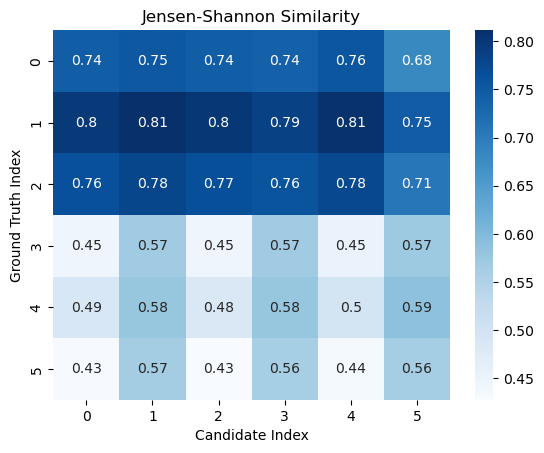

In [72]:
true_params = data["child_mix_weights"].reshape(-1, struct_upbd["G0"])
candidate_params = mean_w.reshape(-1, struct_upbd["G0"])

p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

print(similarity)

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()

tensor([[1.0000, 0.9271, 0.9681, 0.3069, 0.3069, 0.3069],
        [0.9271, 1.0000, 0.9880, 0.3069, 0.3069, 0.3069],
        [0.9681, 0.9880, 1.0000, 0.3069, 0.3069, 0.3069],
        [0.3069, 0.3069, 0.3069, 1.0000, 0.9458, 0.9719],
        [0.3069, 0.3069, 0.3069, 0.9458, 1.0000, 0.8582],
        [0.3069, 0.3069, 0.3069, 0.9719, 0.8582, 1.0000]])


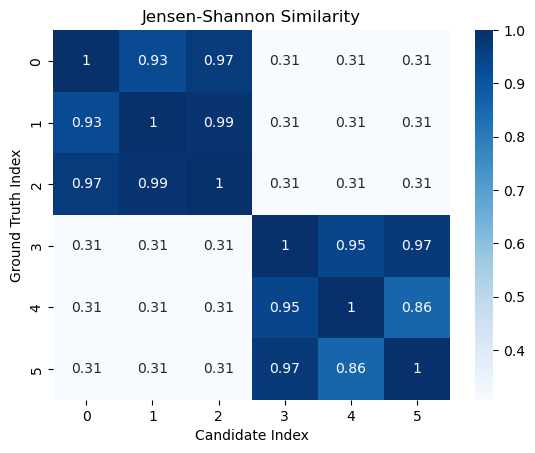

In [73]:
true_params = data["child_mix_weights"].reshape(-1, struct_upbd["G0"])
candidate_params = true_params

p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

print(similarity)

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()

torch.Size([2, 6])
tensor([[0.7627, 0.7724],
        [0.5198, 0.5304]])


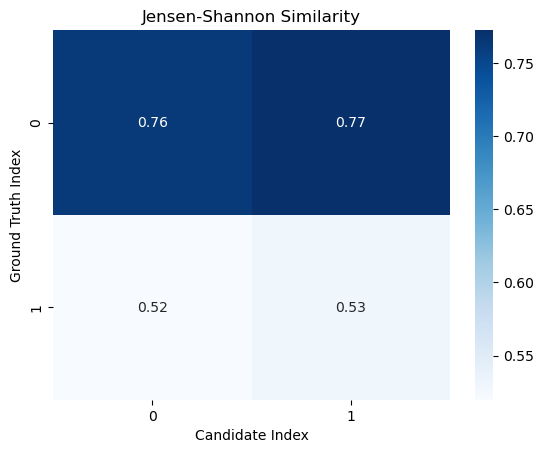

In [74]:
predict_beta = samples['G1']
weights = mix_weights(predict_beta)[..., :-1]
mean_w = weights.mean(dim=0)
var_w = weights.var(dim=0)
print(mean_w.shape)
true_params = data["super_mix_weights"].reshape(-1, struct_upbd["G0"])
candidate_params = mean_w.reshape(-1, struct_upbd["G0"])

p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

print(similarity)

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()

torch.Size([2, 6])
tensor([[1.0000, 0.3069],
        [0.3069, 1.0000]])


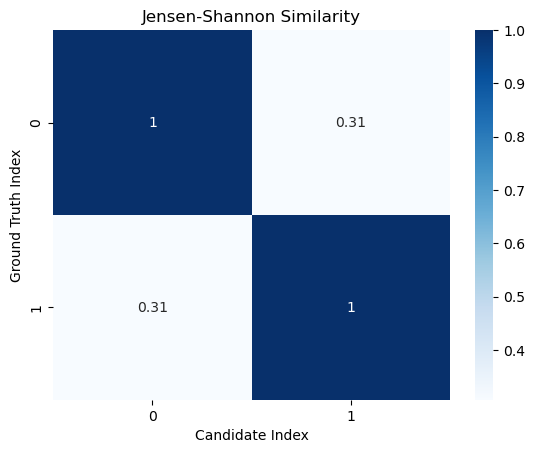

In [75]:
predict_beta = samples['G1']
weights = mix_weights(predict_beta)[..., :-1]
mean_w = weights.mean(dim=0)
var_w = weights.var(dim=0)
print(mean_w.shape)
true_params = data["super_mix_weights"].reshape(-1, struct_upbd["G0"])
candidate_params = true_params

p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

print(similarity)

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()

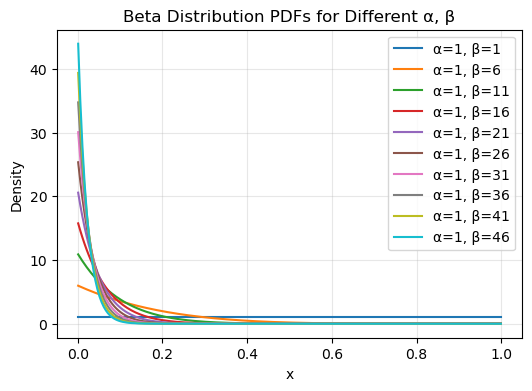

In [100]:
import torch
import matplotlib.pyplot as plt

# Grid for x values (0,1)
x = torch.linspace(0.001, 0.999, 200)  # avoid 0 and 1 to prevent log issues

# List of (alpha, beta) pairs to plot
params = [
    (0.5, 0.5),   # U-shape
    (1.0, 1.0),   # Uniform
    (2.0, 5.0),   # Skewed right
    (5.0, 2.0),   # Skewed left
    (2.0, 2.0)    # Symmetric, peaked
]

plt.figure(figsize=(6, 4))
for b in range(1, 50, 5):
    a = 1
    beta_dist = torch.distributions.Beta(a, b)
    pdf = torch.exp(beta_dist.log_prob(x))  # evaluate density
    plt.plot(x, pdf, label=f'α={a}, β={b}')

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Beta Distribution PDFs for Different α, β")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
